<a href="https://colab.research.google.com/github/sholmen1/Senior_Design/blob/main/try1_20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ramanspy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 20.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.0/47.0 kB 653.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 7.9 MB/s eta 0:00:00
  Created wheel for pysptools: filename=pysptools-0.15.0-py3-none-any.whl size=8133730 sha256=fa891a261f982b91a7668ebcf84f6214de1c95bda7d83319fd4d90e22437e792
  Stored in directory: /root/.cache/pip/wheels/cf/fc/d3/0af346dd85827b7411342d0b44507a59d637a995c7e0f00fa6
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=f49b324c21f066b2d30f44316080123de981d87e75a650d71021029ae1c2dedd
  Stored in directory: /root/.cache/pip/wheels/40/b3/0f/a40dbd1c6861731779f62cc4babcb234387e11d697df70ee97
Successfully built pysptools wget


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ramanspy as rp
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
def read_spa(filepath):
    '''
    Input
    Read a file (string) *.spa
    ----------
    Output
    Return spectra, wavelenght (1/cm), nm(1e7/Wavelength) titles
    '''
    with open(filepath, 'rb') as f:
        f.seek(564)
        Spectrum_Pts = np.fromfile(f, np.int32,1)[0]
        f.seek(30)
        SpectraTitles = np.fromfile(f, np.uint8,255)
        SpectraTitles = ''.join([chr(x) for x in SpectraTitles if x!=0])

        f.seek(576)
        Max_Wavenum=np.fromfile(f, np.single, 1)[0]
        Min_Wavenum=np.fromfile(f, np.single, 1)[0]
        # print(Min_Wavenum, Max_Wavenum, Spectrum_Pts)
        Wavenumbers = np.flip(np.linspace(Min_Wavenum, Max_Wavenum, Spectrum_Pts))

        f.seek(288);

        Flag=0
        while Flag != 3:
            Flag = np.fromfile(f, np.uint16, 1)

        DataPosition=np.fromfile(f,np.uint16, 1)
        f.seek(DataPosition[0])

        Spectra = np.fromfile(f, np.single, Spectrum_Pts)
    return Spectra, Wavenumbers, SpectraTitles


In [ ]:
def mean(spectrum1,spectrum2,spectrum3):
  specOut = np.empty(np.shape(spectrum1))
  for i in range(len(spectrum1)):
    specOut[i] = (spectrum1[i]+spectrum2[i]+spectrum3[i])/3
  return specOut

In [ ]:
# # Created 2015, Zack Gainsforth
# import struct
# from numpy.fft import fft, fftfreq

# def LoadSPAInterferogram(Filename):

#     # Open the SPA file.
#     with open(Filename, 'rb') as f:

#         # Go to offset 294 in the header which tells us the number of sections in the file.
#         f.seek(294)
#         NumSections = struct.unpack('h', f.read(2))[0]
#         print('This spa file has ' + str(NumSections) + ' sections.')

#         # We will process each section in the spa file.
#         for n in range(NumSections):
#             # Go to the section start.  Each section is 16 bytes, and starts after offset 304.
#             f.seek(304+16*n)
#             SectionType = struct.unpack('h', f.read(2))[0]
#             SectionOffset = struct.unpack('i', f.read(3)+b'\x00')[0]
#             SectionLength = struct.unpack('i', f.read(3)+b'\x00')[0]

#             print('Section #%d, Type: %d, Offset: %d, Length %d' % (n, SectionType, SectionOffset, SectionLength))

#             # If this is section type 3, then it contains the result spectrum (interferogram, single beam, etc.) Note where it is in the file.
#             if SectionType==3:
#                 print('Found raw spectrum section.')
#                 Section3Offset = SectionOffset
#                 Section3Length = SectionLength
#                 print(f"Section3Offset: {Section3Offset}, Section3Length: {Section3Length}") # Print the offset and length
#             # If this is section type 102, then it contains a processed spectrum.
#             if SectionType==102:
#                 print('Found processed spectrum section.')
#                 Section102Offset = SectionOffset
#                 Section102Length = SectionLength
#                 print(f"Section102Offset: {Section102Offset}, Section102Length: {Section102Length}") # Print the offset and length

#         # We will default to using section 102 (processed data) if it exists.  Otherwise, we read section 3 (raw data).
#         if 'Section102Length' in locals() and Section102Length > 0:  # Check for existence and non-zero length:
#             print('Using processed spectrum.')
#             SectionOffset = Section102Offset
#             SectionLength = Section102Length
#         else:
#             print('Using raw spectrum.')
#             SectionOffset = Section3Offset
#             SectionLength = Section3Length

#         # Read in the data!
#         f.seek(SectionOffset)
#         DataText = f.read(SectionLength)
#         print(f"DataText: {DataText}")
#         Data = np.fromstring(DataText, dtype='float32')[:-5]

#         return Data

# def PlotInterferogram(Interferogram):

#     plt.figure()
#     plt.plot(Interferogram)
#     plt.title('Interferogram')

#     # Apply the hamming window to smooth out the FT (we don't want ripples.)
#     H = np.hamming(len(Interferogram))
#     I = H*Interferogram
#     plt.figure()
#     plt.plot(I)
#     plt.plot(H)
#     plt.title('Hamminged Interferogram')

#     # Compute the FFT
#     F = fft(I)

#     # Make the magnitude spectrum.
#     Mag = np.abs(F)
#     Mag = Mag[:int(len(Mag)/2)]

#     LaserFreq = 15798.3 # cm-1, this is the sampling distance for the interferogram.
#     #dE = 1/(2*LaserFreq)
#     E = fftfreq(len(Interferogram), 1/(2*LaserFreq))
#     E=E[:int(len(E)/2)]

#     plt.figure()
#     plt.plot(E, Mag)
#     plt.title('Magnitude spectrum')

#     # Make the phase spectrum.
#     Phase = np.unwrap(np.angle(F))
#     Phase = Phase[:int(len(Phase)/2)]
#     plt.figure()
#     plt.plot(E, Phase)
#     plt.title('Phase spectrum')

#     return

# def GetMagAndPhaseFromInterferogram(Interferogram, SamplingLaserFreq=15798.3):
#     # Returns:
#     # Wavenumbers is the energy axis in cm-1
#     # Mag is the magnitude spectrum
#     # Phase is the phase spectrum.

#     # Apply the hamming window to smooth out the FT (we don't want ripples.)
#     H = np.hamming(len(Interferogram))
#     I = H*Interferogram

#     # Compute the FFT
#     F = fft(I)

#     # Make the magnitude spectrum.
#     Mag = np.abs(F)
#     Mag = Mag[:int(len(Mag)/2)]

#     LaserFreq = SamplingLaserFreq #15798.3 # cm-1, this is the sampling distance for the interferogram.
#     #dE = 1/(2*LaserFreq)
#     E = fftfreq(len(Interferogram), 1/(2*LaserFreq))
#     E=E[:int(len(E)/2)]

#     # Make the phase spectrum.
#     Phase = np.unwrap(np.angle(F))
#     Phase = Phase[:int(len(Phase)/2)]

#     return E, Mag, Phase

# if __name__ == '__main__':

#     # FileName = 'Nuth_FeO_smoke_DriftSpot2_Au_0006.spa'
#     # FileName = 'background/bkg_au_harmonic2.spa'
#     # FileName = 'section5/scan2/spec0040.spa'
#     Filename = '/content/drive/My Drive/Silane 04_16_2025/00_YBK1_04_08_2025_CompanySilane_BKG.SPA'
#     Interferogram = LoadSPAInterferogram(Filename)

#     PlotInterferogram(Interferogram)
#     plt.show()
# GetMagAndPhaseFromInterferogram(Interferogram, SamplingLaserFreq=15798.3)



In [ ]:
def dist(array):
  wavenumbers = np.linspace(650,4000,int(len(array)))
  return wavenumbers

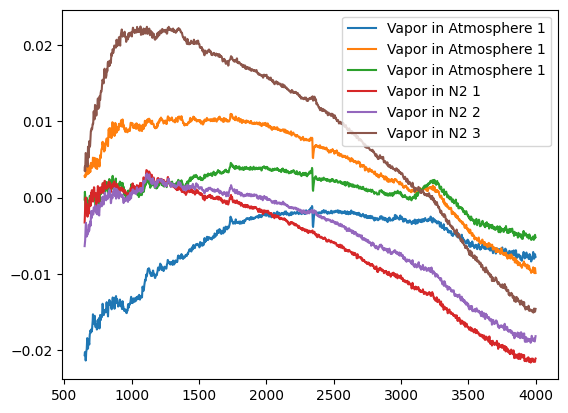

[ 650.          651.92861255  653.8572251  ... 3996.1427749  3998.07138745
 4000.        ]
1738


In [ ]:
file1 = read_spa('/content/drive/My Drive/Silane 04_16_2025/01_YVA1_04_08_2025_CompanySilane_RAW.SPA')
file2 = read_spa('/content/drive/My Drive/Silane 04_16_2025/02_YVA2_04_08_2025_CompanySilane_RAW.SPA')
file3 = read_spa('/content/drive/My Drive/Silane 04_16_2025/03_YVA3_04_08_2025_CompanySilane_RAW.SPA')
file4 = read_spa('/content/drive/My Drive/Silane 04_16_2025/04_YVN1_04_08_2025_CompanySilane_RAW.SPA')
file5 = read_spa('/content/drive/My Drive/Silane 04_16_2025/05_YVN2_04_08_2025_CompanySilane_RAW.SPA')
file6 = read_spa('/content/drive/My Drive/Silane 04_16_2025/06_YVN3_04_08_2025_CompanySilane_RAW.SPA')

plot1 = plt.plot(file1[1],file1[0],label = "Vapor in Atmosphere 1")
plot2 = plt.plot(file2[1],file2[0],label = "Vapor in Atmosphere 1")
plot3 = plt.plot(file3[1],file3[0],label = "Vapor in Atmosphere 1")
plot4 = plt.plot(file4[1],file4[0],label = "Vapor in N2 1")
plot5 = plt.plot(file5[1],file5[0],label = "Vapor in N2 2")
plot6 = plt.plot(file6[1],file6[0],label = "Vapor in N2 3")

#plot1 = plt.plot(waves,file1[0],label = "YVA1")
#plot2 = plt.plot(waves,file2[0],label = "YVA2")
#plot3 = plt.plot(waves,file3[0],label = "YVA3")
#plot4 = plt.plot(waves,file4[0],label = "YVA4")
#plot5 = plt.plot(waves,file5[0],label = "YVA5")
#plot6 = plt.plot(waves,file6[0],label = "YVA6")

# YVA = mean(file1[0],file2[0],file3[0])
# YVAPlot = plt.plot(file1[1],YVA,label = "YVA")
# YVN = mean(file4[0],file5[0],file6[0])
# YVNPlot = plt.plot(file1[1],YVN,label = "YVN")

plt.legend()
plt.show()

waves = dist(file1[1])
print(waves)
print(len(waves))

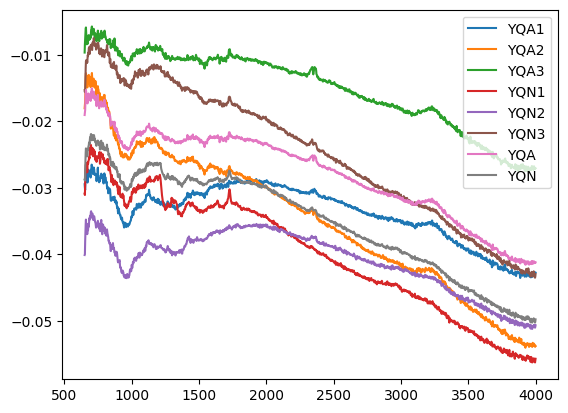

In [ ]:
file1 = read_spa('/content/drive/My Drive/Silane 04_16_2025/07_YQA1_04_08_2025_CompanySilane_RAW.SPA')
file2 = read_spa('/content/drive/My Drive/Silane 04_16_2025/08_YQA2_04_08_2025_CompanySilane_RAW.SPA')
file3 = read_spa('/content/drive/My Drive/Silane 04_16_2025/09_YQA3_04_08_2025_CompanySilane_RAW.SPA')
file4 = read_spa('/content/drive/My Drive/Silane 04_16_2025/10_YQN1_04_08_2025_CompanySilane_RAW.SPA')
file5 = read_spa('/content/drive/My Drive/Silane 04_16_2025/11_YQN2_04_08_2025_CompanySilane_RAW.SPA')
file6 = read_spa('/content/drive/My Drive/Silane 04_16_2025/12_YQN3_04_08_2025_CompanySilane_RAW.SPA')

plot1 = plt.plot(file1[1],file1[0],label = "YQA1")
plot2 = plt.plot(file2[1],file2[0],label = "YQA2")
plot3 = plt.plot(file3[1],file3[0],label = "YQA3")
plot4 = plt.plot(file4[1],file4[0],label = "YQN1")
plot5 = plt.plot(file5[1],file5[0],label = "YQN2")
plot6 = plt.plot(file6[1],file6[0],label = "YQN3")

YQA = mean(file1[0],file2[0],file3[0])
YQAPlot = plt.plot(file1[1],YQA,label = "YQA")
YQN = mean(file4[0],file5[0],file6[0])
YQNPlot = plt.plot(file1[1],YQN,label = "YQN")

plt.legend()
plt.show()

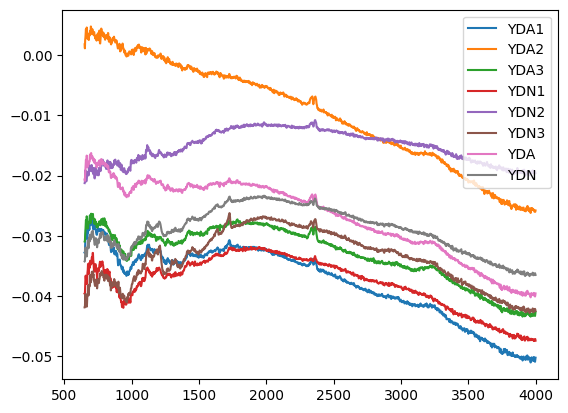

In [ ]:
file1 = read_spa('/content/drive/My Drive/Silane 04_16_2025/13_YDA1_04_08_2025_CompanySilane_RAW.SPA')
file2 = read_spa('/content/drive/My Drive/Silane 04_16_2025/14_YDA2_04_08_2025_CompanySilane_RAW.SPA')
file3 = read_spa('/content/drive/My Drive/Silane 04_16_2025/15_YDA3_04_08_2025_CompanySilane_RAW.SPA')
file4 = read_spa('/content/drive/My Drive/Silane 04_16_2025/16_YDN1_04_08_2025_CompanySilane_RAW.SPA')
file5 = read_spa('/content/drive/My Drive/Silane 04_16_2025/17_YDN2_04_08_2025_CompanySilane_RAW.SPA')
file6 = read_spa('/content/drive/My Drive/Silane 04_16_2025/18_YDN3_04_08_2025_CompanySilane_RAW.SPA')

plot1 = plt.plot(file1[1],file1[0],label = "YDA1")
plot2 = plt.plot(file2[1],file2[0],label = "YDA2")
plot3 = plt.plot(file3[1],file3[0],label = "YDA3")
plot4 = plt.plot(file4[1],file4[0],label = "YDN1")
plot5 = plt.plot(file5[1],file5[0],label = "YDN2")
plot6 = plt.plot(file6[1],file6[0],label = "YDN3")

YDA = mean(file1[0],file2[0],file3[0])
YDAPlot = plt.plot(file1[1],YDA,label = "YDA")
YDN = mean(file4[0],file5[0],file6[0])
YDNPlot = plt.plot(file1[1],YDN,label = "YDN")

plt.legend()
plt.show()

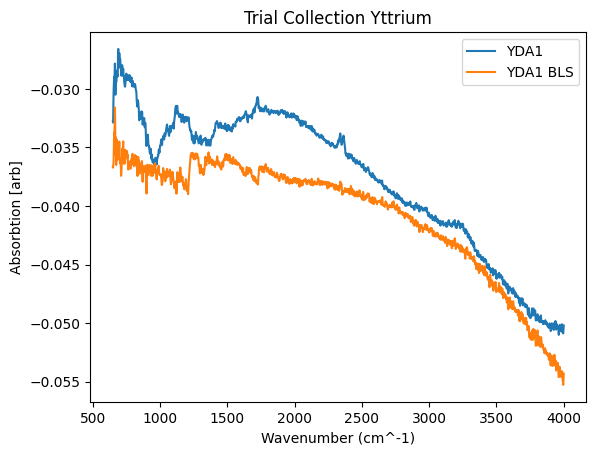

In [ ]:
file1 = read_spa('/content/drive/My Drive/Silane 04_16_2025/01_YVA1_04_08_2025_CompanySilane_RAW.SPA')
file2 = read_spa('/content/drive/My Drive/Silane 04_16_2025/07_YQA1_04_08_2025_CompanySilane_RAW.SPA')
file3 = read_spa('/content/drive/My Drive/Silane 04_16_2025/13_YDA1_04_08_2025_CompanySilane_RAW.SPA')
file4 = read_spa('/content/drive/My Drive/Silane 04_16_2025/01_YVA1_04_08_2025_CompanySilane_BLS.SPA')
file5 = read_spa('/content/drive/My Drive/Silane 04_16_2025/07_YQA1_04_08_2025_CompanySilane_BLS.SPA')
file6 = read_spa('/content/drive/My Drive/Silane 04_16_2025/13_YDA1_04_08_2025_CompanySilane_BLS.SPA')

# plot1 = plt.plot(file1[1],file1[0],label = "YVA1")
# plot2 = plt.plot(file2[1],file2[0],label = "YQA1")
plot3 = plt.plot(file3[1],file3[0],label = "YDA1")
# plot4 = plt.plot(file4[1],file1[0]-file4[0],label = "YVA1 BLS")
# plot5 = plt.plot(file5[1],file2[0]-file5[0],label = "YQA1 BLS")
plot6 = plt.plot(file6[1],file3[0]-file6[0],label = "YDA1 BLS")

# YDA = mean(file1[0],file2[0],file3[0])
# YDAPlot = plt.plot(file1[1],YDA,label = "YDA")
# YDN = mean(file4[0],file5[0],file6[0])
# YDNPlot = plt.plot(file1[1],YDN,label = "YDN")
plt.title("Trial Collection Yttrium")
plt.xlabel("Wavenumber (cm^-1)")
plt.ylabel("Absorbtion [arb]")
plt.legend()
plt.show()

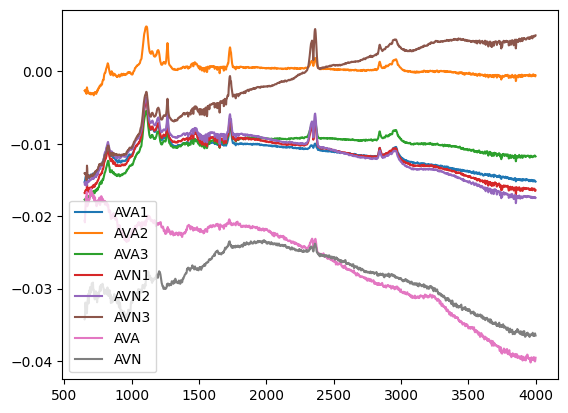

In [ ]:
file1 = read_spa('/content/drive/My Drive/Silane 04_16_2025/19_AVA1_04_08_2025_CompanySilane_RAW.SPA')
file2 = read_spa('/content/drive/My Drive/Silane 04_16_2025/20_AVA2_04_08_2025_CompanySilane_RAW.SPA')
file3 = read_spa('/content/drive/My Drive/Silane 04_16_2025/21_AVA3_04_08_2025_CompanySilane_RAW.SPA')
file4 = read_spa('/content/drive/My Drive/Silane 04_16_2025/22_AVN1_04_08_2025_CompanySilane_RAW.SPA')
file5 = read_spa('/content/drive/My Drive/Silane 04_16_2025/23_AVN2_04_08_2025_CompanySilane_RAW.SPA')
file6 = read_spa('/content/drive/My Drive/Silane 04_16_2025/24_AVN3_04_08_2025_CompanySilane_RAW.SPA')

plot1 = plt.plot(file1[1],file1[0],label = "AVA1")
plot2 = plt.plot(file2[1],file2[0],label = "AVA2")
plot3 = plt.plot(file3[1],file3[0],label = "AVA3")
plot4 = plt.plot(file4[1],file4[0],label = "AVN1")
plot5 = plt.plot(file5[1],file5[0],label = "AVN2")
plot6 = plt.plot(file6[1],file6[0],label = "AVN3")

AVA = mean(file1[0],file2[0],file3[0])
AVAPlot = plt.plot(file1[1],YDA,label = "AVA")
AVN = mean(file4[0],file5[0],file6[0])
AVNPlot = plt.plot(file1[1],YDN,label = "AVN")

plt.legend()
plt.show()

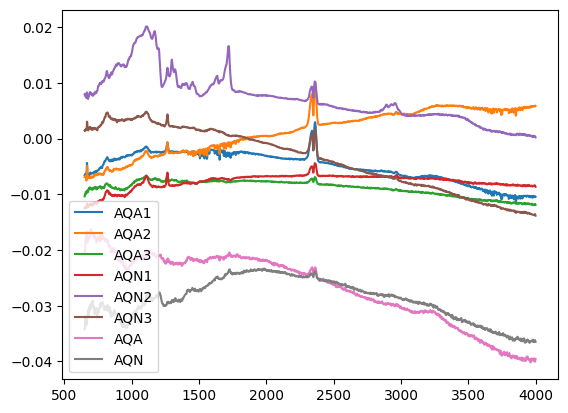

In [ ]:
file1 = read_spa('/content/drive/My Drive/Silane 04_16_2025/25_AQA1_04_08_2025_CompanySilane_RAW.SPA')
file2 = read_spa('/content/drive/My Drive/Silane 04_16_2025/26_AQA2_04_08_2025_CompanySilane_RAW.SPA')
file3 = read_spa('/content/drive/My Drive/Silane 04_16_2025/27_AQA3_04_08_2025_CompanySilane_RAW.SPA')
file4 = read_spa('/content/drive/My Drive/Silane 04_16_2025/28_AQN1_04_08_2025_CompanySilane_RAW.SPA')
file5 = read_spa('/content/drive/My Drive/Silane 04_16_2025/29_AQN2_04_08_2025_CompanySilane_RAW.SPA')
file6 = read_spa('/content/drive/My Drive/Silane 04_16_2025/30_AQN3_04_08_2025_CompanySilane_RAW.SPA')

plot1 = plt.plot(file1[1],file1[0],label = "AQA1")
plot2 = plt.plot(file2[1],file2[0],label = "AQA2")
plot3 = plt.plot(file3[1],file3[0],label = "AQA3")
plot4 = plt.plot(file4[1],file4[0],label = "AQN1")
plot5 = plt.plot(file5[1],file5[0],label = "AQN2")
plot6 = plt.plot(file6[1],file6[0],label = "AQN3")

AQA = mean(file1[0],file2[0],file3[0])
AQAPlot = plt.plot(file1[1],YDA,label = "AQA")
AQN = mean(file4[0],file5[0],file6[0])
AQNPlot = plt.plot(file1[1],YDN,label = "AQN")

plt.legend()
plt.show()

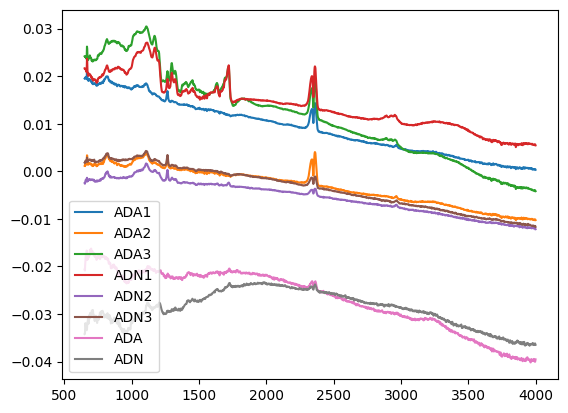

In [ ]:
file1 = read_spa('/content/drive/My Drive/Silane 04_16_2025/31_ADA1_04_08_2025_CompanySilane_RAW.SPA')
file2 = read_spa('/content/drive/My Drive/Silane 04_16_2025/32_ADA2_04_08_2025_CompanySilane_RAW.SPA')
file3 = read_spa('/content/drive/My Drive/Silane 04_16_2025/33_ADA3_04_08_2025_CompanySilane_RAW.SPA')
file4 = read_spa('/content/drive/My Drive/Silane 04_16_2025/34_ADN1_04_08_2025_CompanySilane_RAW.SPA')
file5 = read_spa('/content/drive/My Drive/Silane 04_16_2025/35_ADN2_04_08_2025_CompanySilane_RAW.SPA')
file6 = read_spa('/content/drive/My Drive/Silane 04_16_2025/36_ADN3_04_08_2025_CompanySilane_RAW.SPA')


plot1 = plt.plot(file1[1],file1[0],label = "ADA1")
plot2 = plt.plot(file2[1],file2[0],label = "ADA2")
plot3 = plt.plot(file3[1],file3[0],label = "ADA3")
plot4 = plt.plot(file4[1],file4[0],label = "ADN1")
plot5 = plt.plot(file5[1],file5[0],label = "ADN2")
plot6 = plt.plot(file6[1],file6[0],label = "ADN3")

ADA = mean(file1[0],file2[0],file3[0])
ADAPlot = plt.plot(file1[1],YDA,label = "ADA")
ADN = mean(file4[0],file5[0],file6[0])
ADNPlot = plt.plot(file1[1],YDN,label = "ADN")

plt.legend()
plt.show()

649.90356
3999.7031


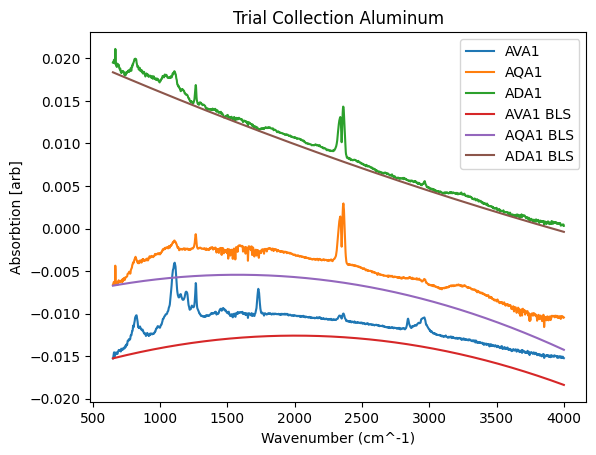

In [ ]:
file1 = read_spa('/content/drive/My Drive/Silane 04_16_2025/19_AVA1_04_08_2025_CompanySilane_RAW.SPA')
file2 = read_spa('/content/drive/My Drive/Silane 04_16_2025/25_AQA1_04_08_2025_CompanySilane_RAW.SPA')
file3 = read_spa('/content/drive/My Drive/Silane 04_16_2025/31_ADA1_04_08_2025_CompanySilane_RAW.SPA')
file4 = read_spa('/content/drive/My Drive/Silane 04_16_2025/19_AVA1_04_08_2025_CompanySilane_BLS.SPA')
file5 = read_spa('/content/drive/My Drive/Silane 04_16_2025/25_AQA1_04_08_2025_CompanySilane_BLS.SPA')
file6 = read_spa('/content/drive/My Drive/Silane 04_16_2025/31_ADA1_04_08_2025_CompanySilane_BLS.SPA')

plot1 = plt.plot(file1[1],file1[0],label = "AVA1")
plot2 = plt.plot(file2[1],file2[0],label = "AQA1")
plot3 = plt.plot(file3[1],file3[0],label = "ADA1")
plot4 = plt.plot(file4[1],file1[0]-file4[0],label = "AVA1 BLS")
plot5 = plt.plot(file5[1],file2[0]-file5[0],label = "AQA1 BLS")
plot6 = plt.plot(file6[1],file3[0]-file6[0],label = "ADA1 BLS")

# YDA = mean(file1[0],file2[0],file3[0])
# YDAPlot = plt.plot(file1[1],YDA,label = "YDA")
# YDN = mean(file4[0],file5[0],file6[0])
# YDNPlot = plt.plot(file1[1],YDN,label = "YDN")
plt.title("Trial Collection Aluminum")
plt.xlabel("Wavenumber (cm^-1)")
plt.ylabel("Absorbtion [arb]")
print(file1[1].min())
print(file1[1].max())
plt.legend()
plt.show()

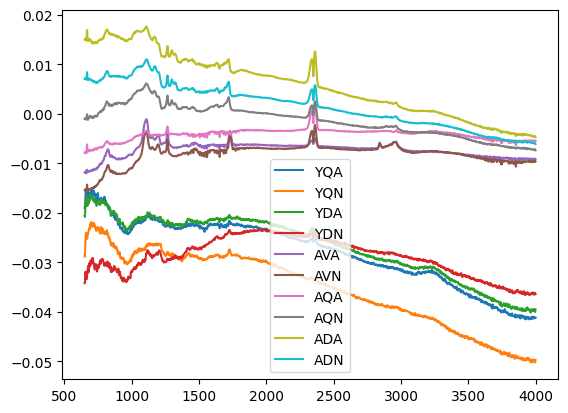

In [ ]:
# YVAPlot = plt.plot(file1[1],YVA,label = "YVA")
# YVNPlot = plt.plot(file1[1],YVN,label = "YVN")
YQAPlot = plt.plot(file1[1],YQA,label = "YQA")
YQNPlot = plt.plot(file1[1],YQN,label = "YQN")
YDAPlot = plt.plot(file1[1],YDA,label = "YDA")
YDNPlot = plt.plot(file1[1],YDN,label = "YDN")
AVAPlot = plt.plot(file1[1],AVA,label = "AVA")
AVNPlot = plt.plot(file1[1],AVN,label = "AVN")
AQAPlot = plt.plot(file1[1],AQA,label = "AQA")
AQNPlot = plt.plot(file1[1],AQN,label = "AQN")
ADAPlot = plt.plot(file1[1],ADA,label = "ADA")
ADNPlot = plt.plot(file1[1],ADN,label = "ADN")

plt.legend()
plt.show()

In [ ]:
file1 = pd.read_csv('/content/drive/My Drive/Silane 04_16_2025/CSV Files/01_YVA1_04_08_2025_CompanySilane_RAW.CSV', header=None)
file2 = pd.read_csv('/content/drive/My Drive/Silane 04_16_2025/CSV Files/07_YQA1_04_08_2025_CompanySilane_RAW.CSV', header=None)
file3 = pd.read_csv('/content/drive/My Drive/Silane 04_16_2025/CSV Files/13_YDA1_04_08_2025_CompanySilane_RAW.CSV', header=None)
file4 = pd.read_csv('/content/drive/My Drive/Silane 04_16_2025/CSV Files/19_AVA1_04_08_2025_CompanySilane_RAW.CSV', header=None)
file5 = pd.read_csv('/content/drive/My Drive/Silane 04_16_2025/CSV Files/25_AQA1_04_08_2025_CompanySilane_RAW.CSV', header=None)
file6 = pd.read_csv('/content/drive/My Drive/Silane 04_16_2025/CSV Files/31_ADA1_04_08_2025_CompanySilane_RAW.CSV', header=None)
file7 = pd.read_csv('/content/drive/My Drive/Silane 04_16_2025/CSV Files/31_ADA1_04_08_2025_CompanySilane_BLS.CSV', header=None)

dataspec1 = rp.Spectrum(file1[1], file1[0])
dataspec2 = rp.Spectrum(file2[1], file2[0])
dataspec3 = rp.Spectrum(file3[1], file3[0])
dataspec4 = rp.Spectrum(file4[1], file4[0])
dataspec5 = rp.Spectrum(file5[1], file5[0])
dataspec6 = rp.Spectrum(file6[1], file6[0])
dataspec7 = rp.Spectrum(file7[1], file7[0])

data_AISLS = rp.preprocessing.baseline.IASLS(lam=10000000000.0, p=0.001, diff_order=6, max_iter=1000, tol=0.001, weights=None)
data_ASLS = rp.preprocessing.baseline.ASLS(lam=1000000000.0, p=0.01, diff_order=6, max_iter=1000, tol=0.001, weights=None)
data_IASLS = rp.preprocessing.baseline.IASLS(lam=1000000.0, p=0.01, diff_order=2, max_iter=5, tol=0.001, weights=None)
data_AIRPLS = rp.preprocessing.baseline.AIRPLS(lam=1000000.0, diff_order=2, max_iter=5, tol=0.001, weights=None)
data_ARPLS = rp.preprocessing.baseline.ARPLS(lam=1000000.0, diff_order=2, max_iter=5, tol=0.001, weights=None)
data_DRPLS = rp.preprocessing.baseline.DRPLS( lam=100000.0, eta=0.5, max_iter=50, tol=0.001, weights=None, diff_order=2)
data_IARPLS = rp.preprocessing.baseline.IARPLS(lam=100000.0, diff_order=2, max_iter=50, tol=0.001, weights=None)
data_ASPLS = rp.preprocessing.baseline.ASPLS( lam=100000.0, diff_order=2, max_iter=100, tol=0.001, weights=None, alpha=None)
data_Poly = rp.preprocessing.baseline.Poly(poly_order=2)
data_ModPoly = rp.preprocessing.baseline.ModPoly(poly_order=4, tol=0.001, max_iter=400, weights=None, use_original=False, mask_initial_peaks=False)
data_Goldindec = rp.preprocessing.baseline.Goldindec( poly_order=2, tol=0.001, max_iter=250, weights=None, cost_function='asymmetric_indec', peak_ratio=0.5, alpha_factor=0.99, tol_2=0.001, tol_3=1e-06, max_iter_2=100)
data_IRSQR = rp.preprocessing.baseline.IRSQR(lam=100, quantile=0.05, num_knots=100, spline_degree=3, diff_order=3, max_iter=100, tol=1e-06, weights=None, eps=None)
data_FABC = rp.preprocessing.baseline.FABC(lam=1000000.0, scale=None, num_std=3.0, diff_order=2, min_length=2, weights=None, weights_as_mask=False, x_data=None)

# preprocessing_pipeline = rp.preprocessing.Pipeline([
#     rp.preprocessing.misc.Cropper(region=(650, 4000)),
#     rp.preprocessing.despike.WhitakerHayes(),
#     rp.preprocessing.denoise.SavGol(window_length=7, polyorder=3),
#     rp.preprocessing.baseline.ASLS(),
#     rp.preprocessing.normalise.MinMax(pixelwise=False),
# ])



In [ ]:
# import matplotlib.pyplot as plt

# # Choose a single raw sample to test (you can change this to dataspec2, etc.)
# sample = dataspec6

# # Define all baseline methods with names for labeling
# baseline_methods = {
#     "IASLS": rp.preprocessing.baseline.IASLS(lam=1e6, p=0.01, diff_order=2, max_iter=5, tol=0.001),
#     "ASLS": rp.preprocessing.baseline.ASLS(lam=1e6, p=0.01, diff_order=2, max_iter=5, tol=0.001),
#     "AIRPLS": rp.preprocessing.baseline.AIRPLS(lam=1e6, diff_order=2, max_iter=5, tol=0.001),
#     "ARPLS": rp.preprocessing.baseline.ARPLS(lam=1e6, diff_order=2, max_iter=5, tol=0.001),
#     "DRPLS": rp.preprocessing.baseline.DRPLS(lam=1e5, eta=0.5, max_iter=50, tol=0.001, diff_order=2),
#     "IARPLS": rp.preprocessing.baseline.IARPLS(lam=1e5, diff_order=2, max_iter=50, tol=0.001),
#     "ASPLS": rp.preprocessing.baseline.ASPLS(lam=1e5, diff_order=2, max_iter=100, tol=0.001),
#     "Poly": rp.preprocessing.baseline.Poly(poly_order=2),
#     "ModPoly": rp.preprocessing.baseline.ModPoly(poly_order=4, tol=0.001, max_iter=400),
#     "Goldindec": rp.preprocessing.baseline.Goldindec(poly_order=2, tol=0.001, max_iter=250),
#     "IRSQR": rp.preprocessing.baseline.IRSQR(lam=100, quantile=0.05, num_knots=100, spline_degree=3),
#     "FABC": rp.preprocessing.baseline.FABC(lam=1e6, scale=None, num_std=3.0, diff_order=2)
# }

# # Plot
# fig, axes = plt.subplots(4, 3, figsize=(18, 16))
# axes = axes.flatten()

# for i, (name, method) in enumerate(baseline_methods.items()):
#     pipeline = rp.preprocessing.Pipeline([
#         rp.preprocessing.misc.Cropper(region=(650, 4000)),
#         rp.preprocessing.despike.WhitakerHayes(),
#         rp.preprocessing.denoise.SavGol(window_length=7, polyorder=3),
#         method,
#         rp.preprocessing.normalise.MinMax(pixelwise=False),
#     ])

#     processed = pipeline.apply(sample)

#     rp.plot.spectra([processed], ax=axes[i], label=[name], plot_type="single")
#     axes[i].set_title(name)
#     axes[i].set_xlim(650, 1500)

# plt.tight_layout()
# plt.show()


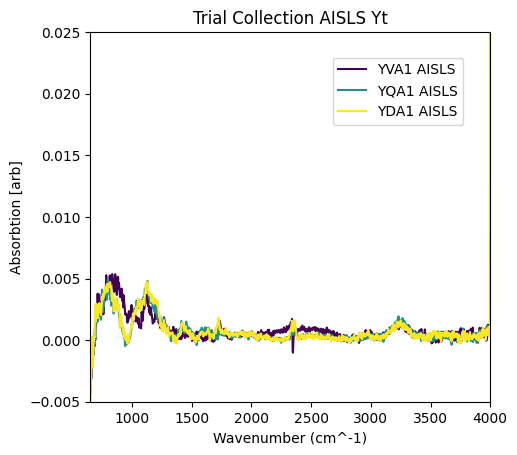

In [ ]:
from ramanspy.preprocessing.misc import Cropper # Import the Cropper class

plt.xlim(650, 4000)
plt.ylim(-.005, .025)


data_flat_file1= data_ASLS(file1[1], file1[0])
data_flat_file2= data_ASLS(file2[1], file2[0])
data_flat_file3= data_ASLS(file3[1], file3[0])
data_flat_file4= data_ASLS(file4[1], file4[0])
data_flat_file5= data_ASLS(file5[1], file5[0])
data_flat_file6= data_IASLS(file6[1], file6[0])
#filelist = [data_flat_file1, data_flat_file2, data_flat_file3, data_flat_file4, data_flat_file5, data_flat_file6]
# data_flat_file1= preprocessing_pipeline.apply(dataspec1)
# data_flat_file2= preprocessing_pipeline.apply(dataspec2)
# data_flat_file3= preprocessing_pipeline.apply(dataspec3)
# data_flat_file4= preprocessing_pipeline.apply(dataspec4)
# data_flat_file5= preprocessing_pipeline.apply(dataspec5)
# data_flat_file6= preprocessing_pipeline.apply(dataspec6)

#AISLS
data = [rp.Spectrum(data_flat_file1[0],data_flat_file1[1]),rp.Spectrum(data_flat_file2[0],data_flat_file2[1]),rp.Spectrum(data_flat_file3[0],data_flat_file3[1])]

data2 = [dataspec1, dataspec2, dataspec3]

data_A = [rp.Spectrum(data_flat_file4[0],data_flat_file4[1])
,rp.Spectrum(data_flat_file5[0],data_flat_file5[1]),dataspec7]
# rp.Spectrum(data_flat_file6[0],data_flat_file6[1])

data_AA = [dataspec4, dataspec5, dataspec6]

plt.axvline(x=650, color='r', linestyle='--', linewidth=.5)

# Now, calculate data2 using the cropped data:
# data2 = [ rp.Spectrum(dataspec1.spectral_data-cropped_data_flat_file1.spectral_data, dataspec1.spectral_axis - cropped_data_flat_file1.spectral_axis),
#           rp.Spectrum(dataspec2.spectral_data-cropped_data_flat_file2.spectral_data, dataspec2.spectral_axis - cropped_data_flat_file2.spectral_axis),
#          rp.Spectrum(dataspec3.spectral_data-cropped_data_flat_file3.spectral_data, dataspec3.spectral_axis - cropped_data_flat_file3.spectral_axis)]
# data3 =  [dataspec4, rp.Spectrum(dataspec4.spectral_data, dataspec4.spectral_axis - cropped_data_flat_file4.spectral_axis),
#          dataspec5, rp.Spectrum(dataspec5.spectral_data, dataspec5.spectral_axis - cropped_data_flat_file5.spectral_axis),
#          dataspec6, rp.Spectrum(dataspec6.spectral_data, dataspec6.spectral_axis - cropped_data_flat_file6.spectral_axis)]
#dataspec1, rp.Spectrum(dataspec1.spectral_data, dataspec1.spectral_axis - cropped_data_flat_file1.spectral_axis),

#"YVA1 Raw",
rp.plot.spectra(data, plot_type='single', label = ["YVA1 AISLS","YQA1 AISLS","YDA1 AISLS"],title="Trial Collection AISLS Yt", xlabel="Wavenumber (cm^-1)", ylabel="Absorbtion [arb]")
plt.legend(loc='upper right', bbox_to_anchor=(0.95, 0.95)) # Adjust legend position

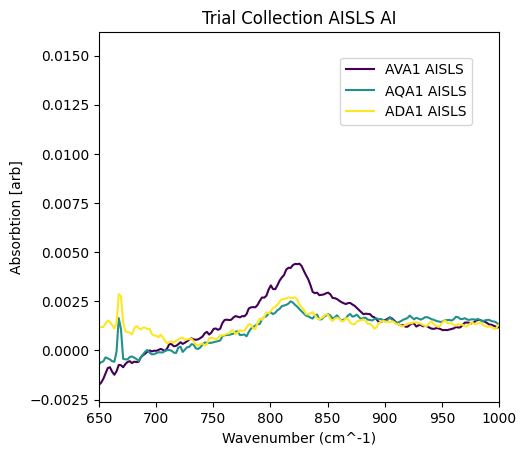

In [ ]:
#"AVA1 Raw",
plt.xlim(650, 1000)
#plt.ylim(0, .025)

plt.axvline(x=650, color='r', linestyle='--', linewidth=.5)

rp.plot.spectra(data_A, plot_type='single', label = ["AVA1 AISLS", "AQA1 AISLS","ADA1 AISLS"],title="Trial Collection AISLS AI", xlabel="Wavenumber (cm^-1)", ylabel="Absorbtion [arb]")
plt.legend(loc='upper right', bbox_to_anchor=(0.95, 0.95)) # Adjust legend position

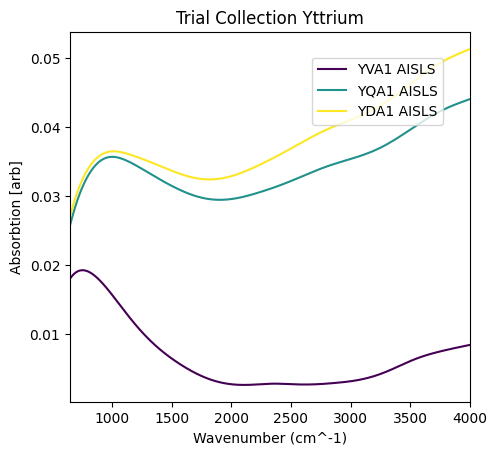

In [ ]:
plt.xlim(650, 4000)
# plt.ylim(-0.051, .025)
dataaa = []
for i in range(len(data)):
  dataaa.append(rp.Spectrum(data[i].spectral_data-data2[i].spectral_data, data[i].spectral_axis))

rp.plot.spectra(dataaa, plot_type='single', label = ["YVA1 AISLS","YQA1 AISLS","YDA1 AISLS"],title="Trial Collection AISLS Yt", xlabel="Wavenumber (cm^-1)", ylabel="Absorbtion [arb]")
plt.title("Trial Collection Yttrium")
plt.legend(loc='upper right', bbox_to_anchor=(0.95, 0.95)) # Adjust legend position
plt.show()

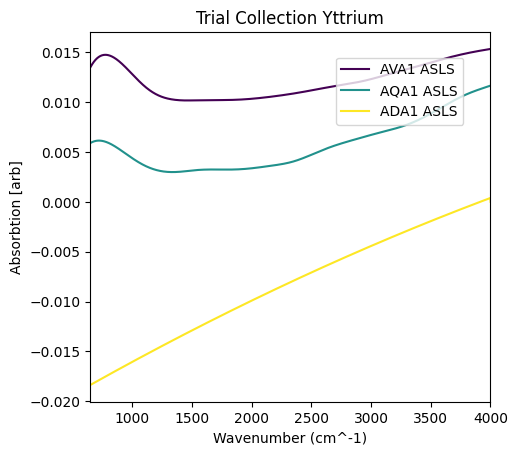

In [ ]:
plt.xlim(650, 4000)
# plt.ylim(-0.051, .025)
dataaan = []
for i in range(len(data_A)):
  dataaan.append(rp.Spectrum(data_A[i].spectral_data-data_AA[i].spectral_data, data_A[i].spectral_axis))

rp.plot.spectra(dataaan, plot_type='single', label = ["AVA1 ASLS","AQA1 ASLS","ADA1 ASLS"],title="Trial Collection AISLS Yt", xlabel="Wavenumber (cm^-1)", ylabel="Absorbtion [arb]")
plt.title("Trial Collection Yttrium")
plt.legend(loc='upper right', bbox_to_anchor=(0.95, 0.95)) # Adjust legend position
plt.show()

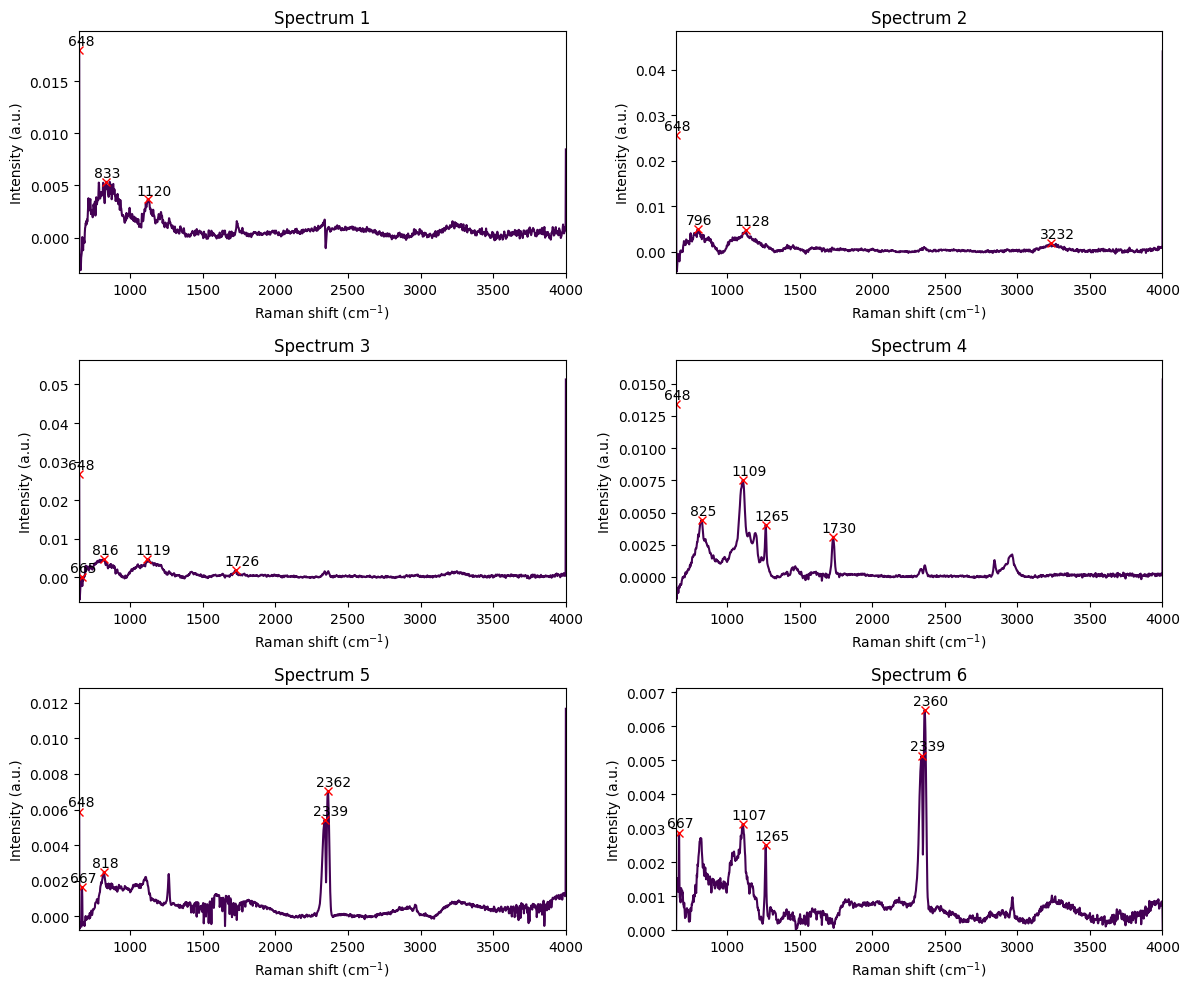

In [ ]:
import matplotlib.pyplot as plt

# plt.ylim(-0.051, .025)
fig, axes = plt.subplots(3, 2, figsize=(12, 10))  # 3 rows, 2 columns
axes = axes.flatten()  # Flatten to easily index

for i, data in enumerate([
    data_flat_file1[0],
    data_flat_file2[0],
    data_flat_file3[0],
    data_flat_file4[0],
    data_flat_file5[0],
    file7[1]
]):
    rp.plot.peaks(
        rp.Spectrum(data, dataspec1.spectral_axis),
        prominence=0.002,
        return_peaks=True,
        ax=axes[i]
    )
    axes[i].set_title(f'Spectrum {i+1}')
    # 👇 Set x and y axis limits for each subplot
    axes[i].set_xlim(645, 4000)
    # axes[i].set_ylim(0, 0.01)

plt.tight_layout()
plt.show()



# rp.plot.peaks(rp.Spectrum(data_flat_file1[0],dataspec1.spectral_axis), prominence=.002,return_peaks=True)
# rp.plot.peaks(rp.Spectrum(data_flat_file2[0],dataspec1.spectral_axis), prominence=.002,return_peaks=True)
# rp.plot.peaks(rp.Spectrum(data_flat_file3[0],dataspec1.spectral_axis), prominence=.002,return_peaks=True)
# rp.plot.peaks(rp.Spectrum(data_flat_file4[0],dataspec1.spectral_axis), prominence=.002,return_peaks=True)
# rp.plot.peaks(rp.Spectrum(data_flat_file5[0],dataspec1.spectral_axis), prominence=.002,return_peaks=True)
# rp.plot.peaks(rp.Spectrum(data_flat_file6[0],dataspec1.spectral_axis), prominence=.002,return_peaks=True)


In [ ]:
# # Assuming data_flat_file1, data_flat_file2, etc. are lists or arrays containing spectral data
# spectrum_data = [
#     rp.Spectrum(data_flat_file1[0], data_flat_file1[1]),
#     rp.Spectrum(data_flat_file2[0], data_flat_file2[1]),
#     rp.Spectrum(data_flat_file3[0], data_flat_file3[1])
# ]

# spectrum_data_A = [
#     rp.Spectrum(data_flat_file4[0], data_flat_file4[1]),
#     rp.Spectrum(data_flat_file5[0], data_flat_file5[1]),
#     rp.Spectrum(data_flat_file6[0], data_flat_file6[1])
# ]

# # Now call rp.plot.peak_dist with the lists of Spectrum objects
# ax = rp.plot.peak_dist(spectrum_data, band=3300, labels=["Y"])
# ax2 = rp.plot.peak_dist(spectrum_data_A, band=690, labels=["AI"])

# # combined_spectra = spectrum_data + spectrum_data_A
# # group_labels = ["Y"] * len(spectrum_data) + ["AI"] * len(spectrum_data_A)

# # ax = rp.plot.peak_dist(combined_spectra, band=660, labels=group_labels)  # Assumes 'group_by' or similar argument

# # ax = rp.plot.peak_dist(spectrum_data, band=660, labels=["Y"])
# # rp.plot.peak_dist(spectrum_data_A, band=660, labels=["AI"], ax=ax)  # Overlay on the same axis
# # plt.show()
#   # or rp.plot.show()

In [ ]:
from ramanspy.preprocessing import Pipeline
from ramanspy.preprocessing.baseline import ASLS
from ramanspy.preprocessing.baseline import IASLS, IRSQR
from ramanspy.preprocessing.normalise import MinMax
from ramanspy.preprocessing.misc import Cropper
from ramanspy.preprocessing.denoise import SavGol
from ramanspy.preprocessing.despike import WhitakerHayes
from ramanspy import Spectrum

# Create Spectrum objects first
spec1 = Spectrum(file1[1], file1[0])
spec2 = Spectrum(file2[1], file2[0])
spec3 = Spectrum(file3[1], file3[0])
spec4 = Spectrum(file4[1], file4[0])
spec5 = Spectrum(file5[1], file5[0])
spec6 = Spectrum(file6[1], file6[0])

pipeline = Pipeline([
    Cropper(region=(650, 4000)),                     # Cut noisy edges (incl. the weird start)
    WhitakerHayes(),                                 # Despike
    SavGol(window_length=7, polyorder=3),            # Smooth
    ASLS(), # Baseline correction)
    IASLS(),
    IRSQR(),
    # MinMax(pixelwise=False)                          # Normalize to [0, 1]
])
#rp.preprocessing.baseline.

In [ ]:
# Now apply the pipeline to each Spectrum
data_flat_file1 = pipeline.apply(spec1)
data_flat_file2 = pipeline.apply(spec2)
data_flat_file3 = pipeline.apply(spec3)
data_flat_file4 = pipeline.apply(spec4)
data_flat_file5 = pipeline.apply(spec5)
data_flat_file6 = pipeline.apply(spec6)


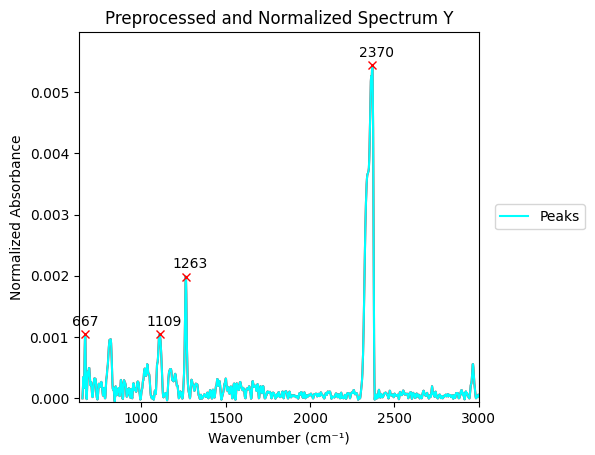

In [ ]:
plt.plot(data_flat_file6.spectral_axis, data_flat_file6.spectral_data, color='red')
rp.plot.peaks(data_flat_file6, prominence=0.001, height=None, threshold=None, distance=30, width=None,
                  wlen=None, rel_height=0.5, plateau_size=None, label='Peaks', return_peaks=True, color='cyan')
plt.xlim(630, 3000)
# plt.ylim(-0.1, 1.05)
plt.title("Preprocessed and Normalized Spectrum Y")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Normalized Absorbance")
plt.show()


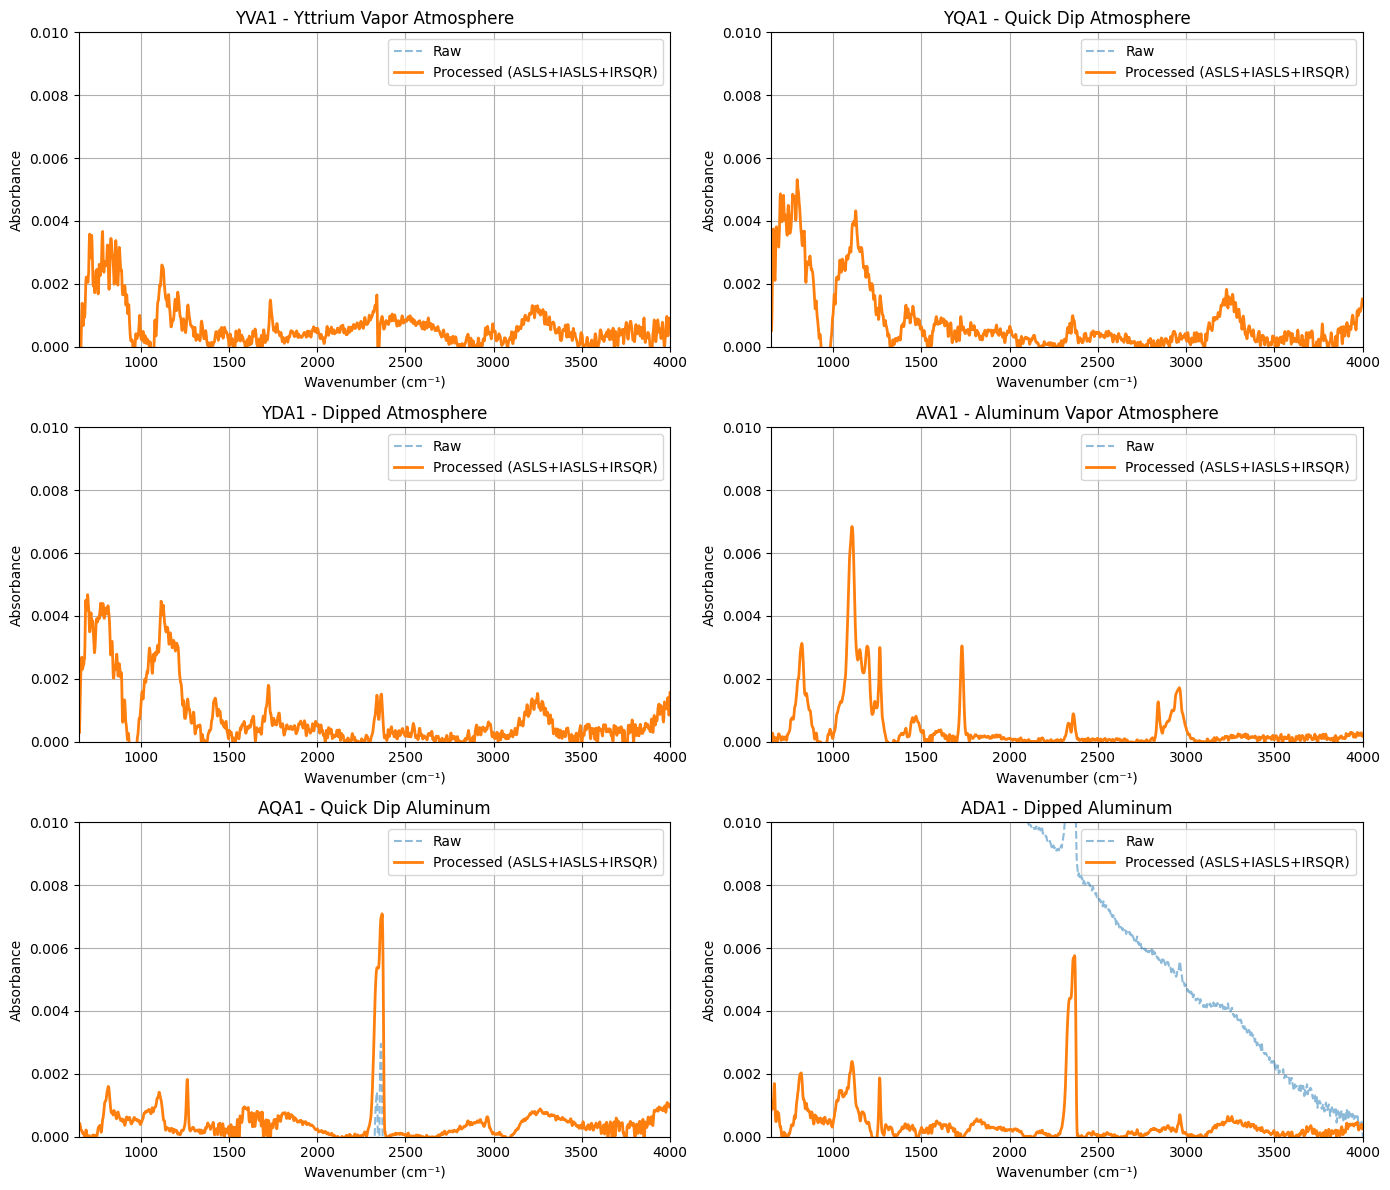

In [ ]:
from ramanspy.preprocessing import Pipeline
from ramanspy.preprocessing.baseline import ASLS, IASLS, IRSQR, ModPoly
from ramanspy.preprocessing.normalise import MinMax
from ramanspy.preprocessing.misc import Cropper
from ramanspy.preprocessing.denoise import SavGol
from ramanspy.preprocessing.despike import WhitakerHayes
from ramanspy import Spectrum
import matplotlib.pyplot as plt
import ramanspy as rp

# Create Spectrum objects
spec1 = Spectrum(file1[1], file1[0]) #YVA1 04/08/2025
spec2 = Spectrum(file2[1], file2[0]) #YQA1 04/08/2025
spec3 = Spectrum(file3[1], file3[0]) #YDA1 04/08/2025
spec4 = Spectrum(file4[1], file4[0]) #AVA1 04/08/2025
spec5 = Spectrum(file5[1], file5[0]) #AQA1 04/08/2025
spec6 = Spectrum(file6[1], file6[0]) #ADA1 04/08/2025

# Define preprocessing pipeline
pipeline = Pipeline([
    Cropper(region=(650, 4000)),            # Cut noisy edges
    WhitakerHayes(),                        # Despike
    SavGol(window_length=7, polyorder=3),   # Smooth
    ASLS(),                                 # Baseline 1
    #IASLS(),                                # Baseline 2
    # IRSQR()                                 # Baseline 3
    #ModPoly(),                               #Baseline4
    # MinMax(pixelwise=False)               # Optional: normalize later if needed
])

# Apply pipeline
processed_specs = [
    pipeline.apply(spec1),
    pipeline.apply(spec2),
    pipeline.apply(spec3),
    pipeline.apply(spec4),
    pipeline.apply(spec5),
    pipeline.apply(spec6)
]

raw_specs = [spec1, spec2, spec3, spec4, spec5, spec6]

labels = [
    "YVA1 - Yttrium Vapor Atmosphere",
    "YQA1 - Quick Dip Atmosphere",
    "YDA1 - Dipped Atmosphere",
    "AVA1 - Aluminum Vapor Atmosphere",
    "AQA1 - Quick Dip Aluminum",
    "ADA1 - Dipped Aluminum"
]

# Create subplots
fig, axes = plt.subplots(3, 2, figsize=(14, 12))  # 3 rows, 2 columns
axes = axes.flatten()

for i in range(6):
    ax = axes[i]
    # Set x and y axis limits for each subplot
    # ax.set_xlim(650, 800)
    # Plot raw
    ax.plot(raw_specs[i].spectral_axis, raw_specs[i].spectral_data,
            linestyle='--', alpha=0.5, label='Raw')

    # Plot processed
    ax.plot(processed_specs[i].spectral_axis, processed_specs[i].spectral_data,
            linewidth=2, label='Processed (ASLS+IASLS+IRSQR)')

    # # Overlay peaks
    #rp.plot.peaks(processed_specs[i], ax=ax, prominence=0.0005, height=None, threshold=None, distance=30, width=None,
    #              wlen=None, rel_height=0.5, plateau_size=None, label='Peaks', return_peaks=True, color='orange')

    ax.set_xlim(650, 4000)
    ax.set_ylim(0, .01)
    ax.set_title(labels[i])
    ax.set_xlabel("Wavenumber (cm⁻¹)")
    ax.set_ylabel("Absorbance")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()



AttributeError: 'numpy.ndarray' object has no attribute 'plot'

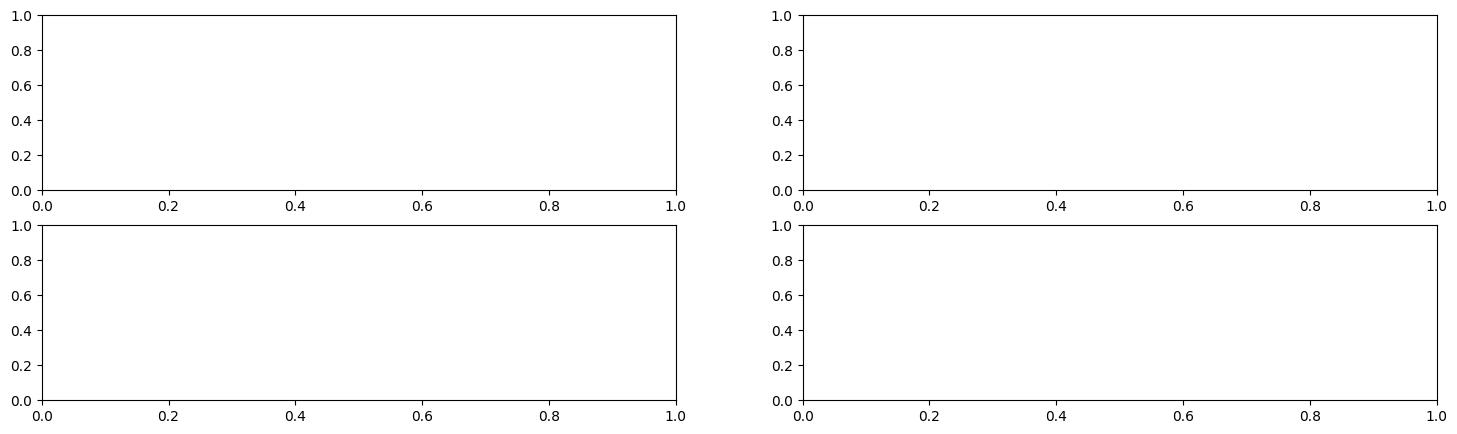

In [ ]:
from ramanspy.preprocessing import Pipeline
from ramanspy.preprocessing.baseline import ASLS, IASLS, IRSQR
from ramanspy.preprocessing.misc import Cropper
from ramanspy.preprocessing.denoise import SavGol
from ramanspy.preprocessing.despike import WhitakerHayes
from ramanspy import Spectrum
import matplotlib.pyplot as plt
import ramanspy as rp

# Create Spectrum objects
specs = [
    Spectrum(file1[1], file1[0]),
    Spectrum(file2[1], file2[0]),
    Spectrum(file3[1], file3[0]),
    Spectrum(file4[1], file4[0]),
    Spectrum(file5[1], file5[0]),
    Spectrum(file6[1], file6[0])
]

labels = [
    "YVA1 - Yttrium Vapor Atmosphere",
    "YQA1 - Quick Dip Atmosphere",
    "YDA1 - Dipped Atmosphere",
    "AVA1 - Aluminum Vapor Atmosphere",
    "AQA1 - Quick Dip Aluminum",
    "ADA1 - Dipped Aluminum"
]

# Define pipeline
pipeline = Pipeline([
    Cropper(region=(650, 4000)),
    WhitakerHayes(),
    SavGol(window_length=7, polyorder=3),
    ASLS(),
    IASLS(),
    IRSQR()
])

# Apply to all
processed_specs = [pipeline.apply(spec) for spec in specs]

# Grouping
yttrium_specs = processed_specs[:3]
yttrium_raw = specs[:3]
yttrium_labels = labels[:3]

aluminum_specs = processed_specs[3:]
aluminum_raw = specs[3:]
aluminum_labels = labels[3:]

# Plotting function
def plot_group(raw_group, proc_group, group_labels, title):
    fig, axes = plt.subplots(2, 2, figsize=(18, 5))

    for i, ax in enumerate(axes):
        # Plot raw
        ax.plot(raw_group[i].spectral_axis, raw_group[i].spectral_data, linestyle='--', alpha=0.4, label='Raw')

        # Plot processed
        ax.plot(proc_group[i].spectral_axis, proc_group[i].spectral_data, linewidth=1.5, label='Processed')

        # Peaks
        # peaks = rp.plot.peaks(proc_group[i], prominence=0.002, return_peaks=True)
        # peak_x = proc_group[i].spectral_axis[peaks]
        # peak_y = proc_group[i].spectral_data[peaks]
        # ax.plot(peak_x, peak_y, 'rx', label='Peaks', markersize=6)

        ax.set_xlim(650, 4000)
        ax.set_title(group_labels[i])
        ax.set_xlabel("Wavenumber (cm⁻¹)")
        ax.set_ylabel("Absorbance")
        ax.grid(True)
        ax.legend()

    plt.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# Plot each group
plot_group(yttrium_raw, yttrium_specs, yttrium_labels, "Yttrium Spectra")


AttributeError: 'numpy.ndarray' object has no attribute 'plot'

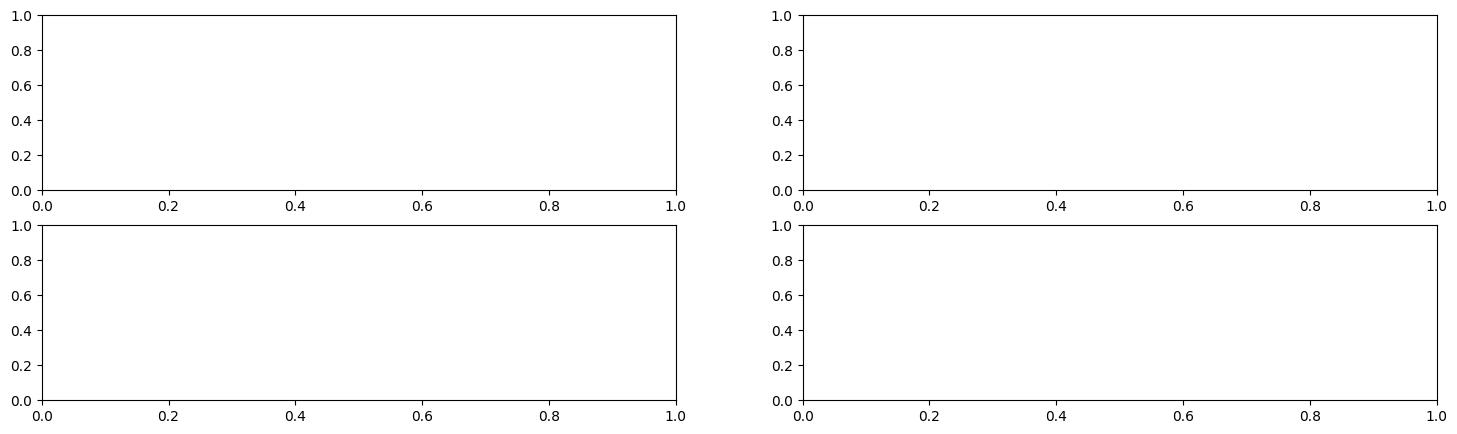

In [ ]:
plot_group(aluminum_raw, aluminum_specs, aluminum_labels, "Aluminum Spectra")

In [ ]:
import math

def plot_group(raw_group, proc_group, group_labels, title):
    n = len(raw_group)
    cols = 2
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 4))
    axes = axes.flatten() if n > 1 else [axes]  # Ensure it's always iterable

    for i in range(rows * cols):
        if i >= n:
            axes[i].axis('off')  # Hide any unused subplot areas
            continue

        ax = axes[i]

        # Plot raw spectrum
        ax.plot(raw_group[i].spectral_axis, raw_group[i].spectral_data, linestyle='--', alpha=0.4, label='Raw')

        # Plot processed spectrum
        ax.plot(proc_group[i].spectral_axis, proc_group[i].spectral_data, linewidth=1.5, label='Processed')

        # Optional: Peak detection (commented for clarity)
        peaks = np.array(rp.plot.peaks(proc_group[i], prominence=0.002, return_peaks=True))
        ax.plot(proc_group[i].spectral_axis[peaks], proc_group[i].spectral_data[peaks], 'rx', label='Peaks', markersize=6)

        ax.set_xlim(650, 4000)
        ax.set_title(group_labels[i])
        ax.set_xlabel("Wavenumber (cm⁻¹)")
        ax.set_ylabel("Absorbance")
        ax.grid(True)
        ax.legend()

    plt.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (3,) + inhomogeneous part.

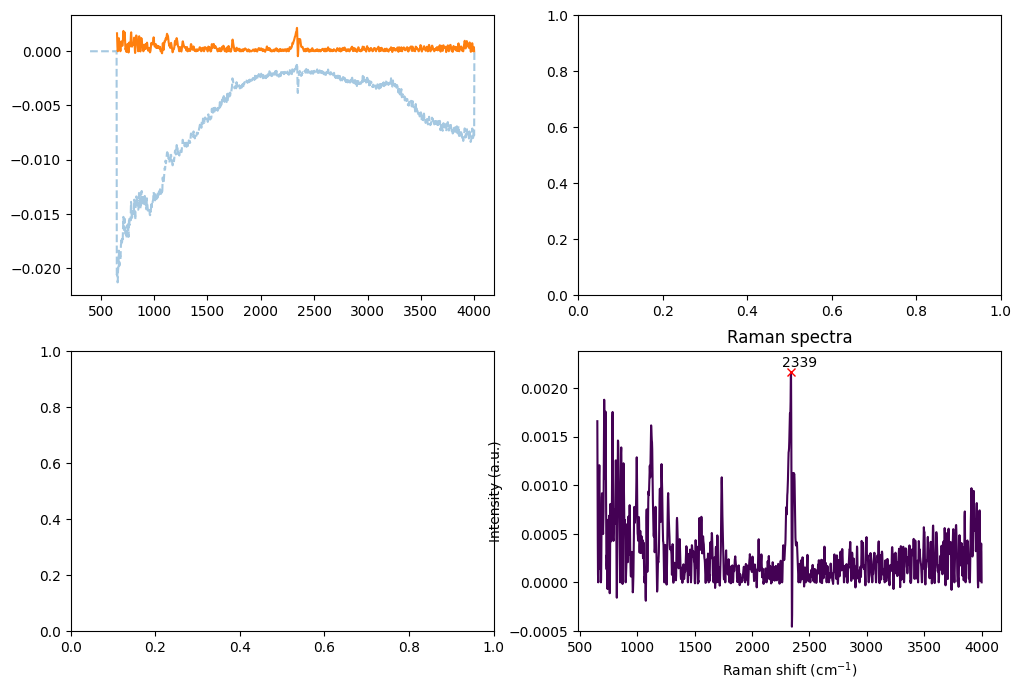

In [ ]:
plot_group(yttrium_raw, yttrium_specs, yttrium_labels, "Yttrium Spectra")
plot_group(aluminum_raw, aluminum_specs, aluminum_labels, "Aluminum Spectra")


In [ ]:
#THIS IS THE CODE CHILD OF 6 DAYS OF TRIAL AND ERROR, IT IS BEAUTIFUL, THIS IS WHAT I WANT IN MY POSTER, Fuck YES!!!!!!!!!!!!!!!!!!!!!!!
# import numpy as np
# import matplotlib.pyplot as plt
# import math
# from scipy.signal import find_peaks
# from ramanspy.preprocessing import Pipeline
# from ramanspy.preprocessing.baseline import ASLS, IASLS, IRSQR
# from ramanspy.preprocessing.misc import Cropper
# from ramanspy.preprocessing.denoise import SavGol
# from ramanspy.preprocessing.despike import WhitakerHayes
# from ramanspy import Spectrum
# import ramanspy as rp

# # Create Spectrum objects
# specs = [
#     Spectrum(file1[1], file1[0]),
#     Spectrum(file2[1], file2[0]),
#     Spectrum(file3[1], file3[0]),
#     Spectrum(file4[1], file4[0]),
#     Spectrum(file5[1], file5[0]),
#     Spectrum(file6[1], file6[0])
# ]

# labels = [
#     "YVA1 - Yttrium Vapor Atmosphere",
#     "YQA1 - Quick Dip Atmosphere",
#     "YDA1 - Dipped Atmosphere",
#     "AVA1 - Aluminum Vapor Atmosphere",
#     "AQA1 - Quick Dip Aluminum",
#     "ADA1 - Dipped Aluminum"
# ]

# # Define pipeline
# pipeline = Pipeline([
#     Cropper(region=(650, 4000)),
#     WhitakerHayes(),
#     SavGol(window_length=7, polyorder=3),
#     ASLS(),
#     IASLS(),
#     IRSQR()
# ])

# # Apply to all
# processed_specs = [pipeline.apply(spec) for spec in specs]

# # Grouping
# yttrium_specs = processed_specs[:3]
# yttrium_raw = specs[:3]
# yttrium_labels = labels[:3]

# aluminum_specs = processed_specs[3:]
# aluminum_raw = specs[3:]
# aluminum_labels = labels[3:]

# def plot_group(raw_group, proc_group, group_labels, title):
#     n = len(raw_group)
#     cols = 2
#     rows = math.ceil(n / cols)

#     fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 4))

#     if isinstance(axes, np.ndarray):
#         axes = axes.flatten()
#     else:
#         axes = [axes]

#     for i in range(rows * cols):
#         if i >= n:
#             axes[i].axis('off')
#             continue

#         ax = axes[i]

#         # Plot raw
#         ax.plot(raw_group[i].spectral_axis, raw_group[i].spectral_data, linestyle='--', alpha=0.4, label='Raw')

#         # Plot processed
#         ax.plot(proc_group[i].spectral_axis, proc_group[i].spectral_data, linewidth=1.5, label='Processed')

#         # Peak detection using scipy
#         y_data = proc_group[i].spectral_data
#         peaks, _ = find_peaks(y_data, prominence=0.002)

#         if len(peaks) > 0:
#             peak_x = proc_group[i].spectral_axis[peaks]
#             peak_y = y_data[peaks]
#             ax.plot(peak_x, peak_y, 'rx', label='Peaks', markersize=6)

#         ax.set_xlim(650, 4000)
#         ax.set_ylim(0, .01)
#         ax.set_title(group_labels[i])
#         ax.set_xlabel("Wavenumber (cm⁻¹)")
#         ax.set_ylabel("Absorbance")
#         ax.grid(True)
#         ax.legend()

#     plt.suptitle(title, fontsize=16)
#     plt.tight_layout(rect=[0, 0, 1, 0.95])
#     plt.show()


# plot_group(yttrium_raw, yttrium_specs, yttrium_labels, "Yttrium Spectra")
# plot_group(aluminum_raw, aluminum_specs, aluminum_labels, "Aluminum Spectra")

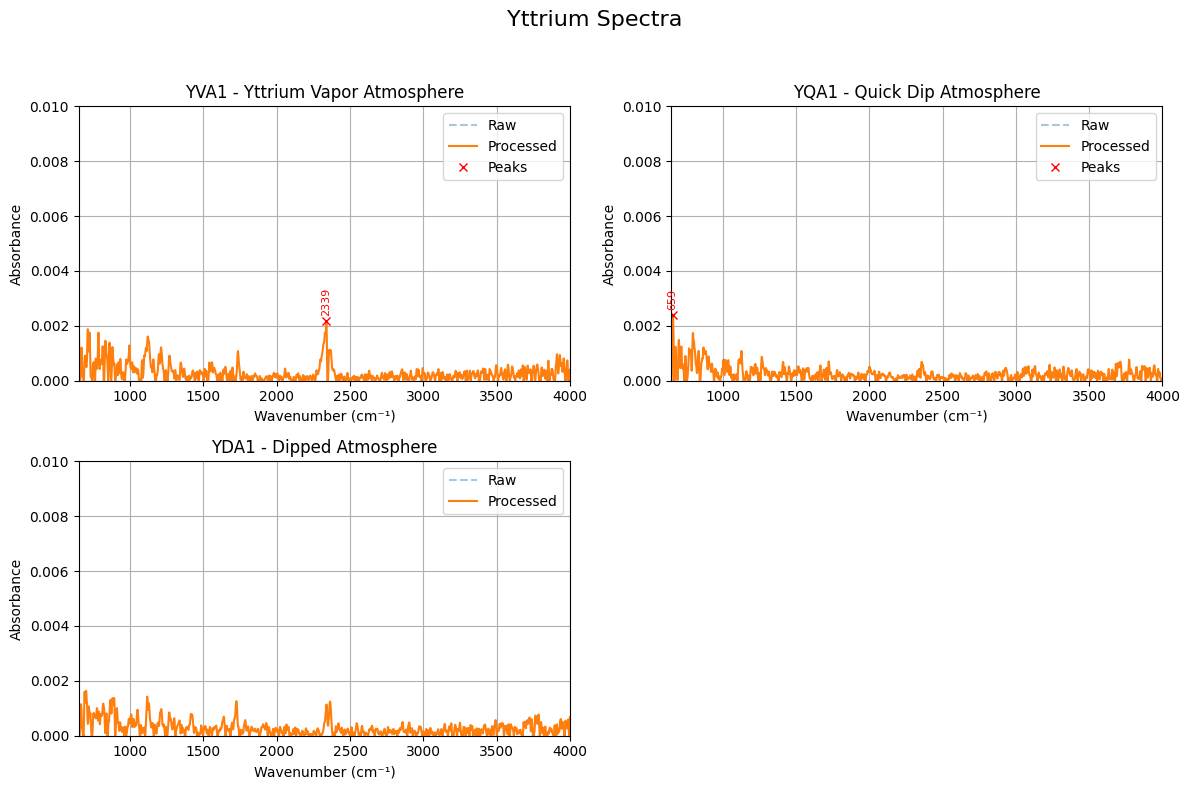

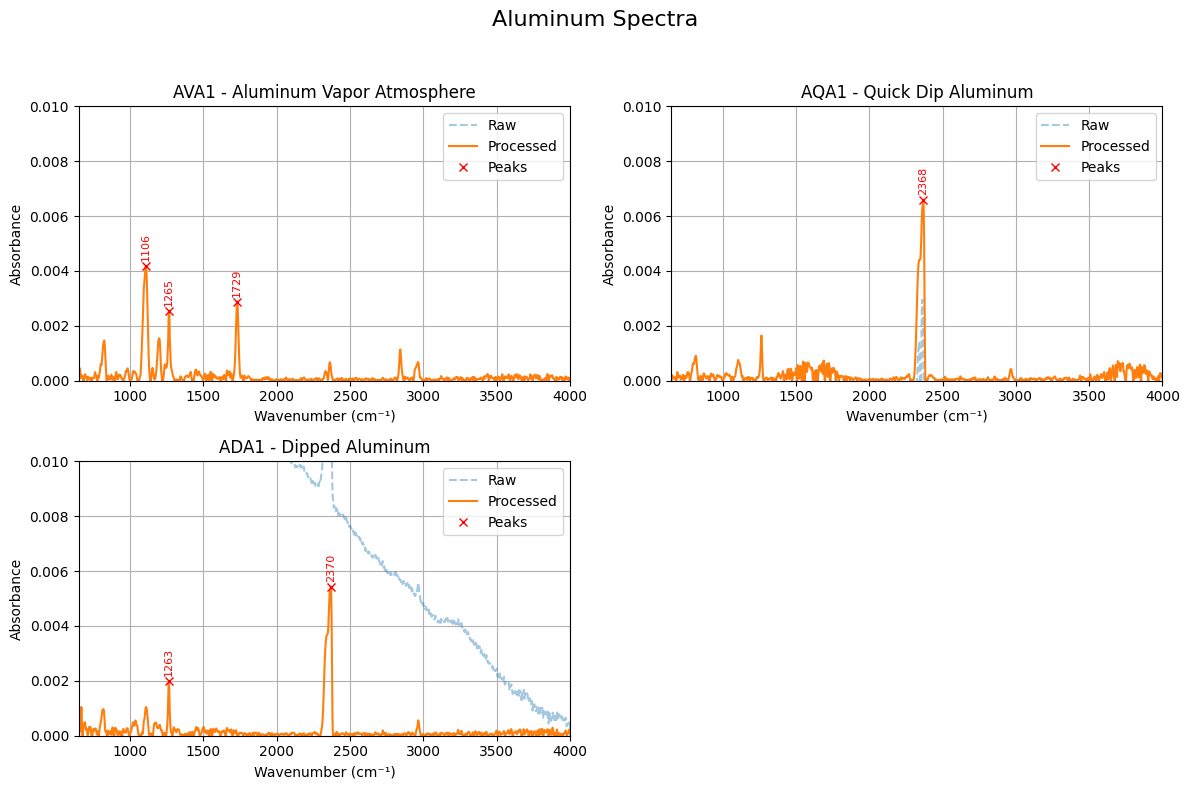

In [ ]:
#THIS IS THE CODE CHILD OF 6 DAYS OF TRIAL AND ERROR, IT IS BEAUTIFUL, THIS IS WHAT I WANT IN MY POSTER, Fuck YES!!!!!!!!!!!!!!!!!!!!!!! Same code with vertical peak info
#THIS IS THE CODE CHILD OF 6 DAYS OF TRIAL AND ERROR, IT IS BEAUTIFUL, THIS IS WHAT I WANT IN MY POSTER, Fuck YES!!!!!!!!!!!!!!!!!!!!!!!
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.signal import find_peaks
from ramanspy.preprocessing import Pipeline
from ramanspy.preprocessing.baseline import ASLS, IASLS, IRSQR
from ramanspy.preprocessing.misc import Cropper
from ramanspy.preprocessing.denoise import SavGol
from ramanspy.preprocessing.despike import WhitakerHayes
from ramanspy import Spectrum
import ramanspy as rp

# Create Spectrum objects
specs = [
    Spectrum(file1[1], file1[0]),
    Spectrum(file2[1], file2[0]),
    Spectrum(file3[1], file3[0]),
    Spectrum(file4[1], file4[0]),
    Spectrum(file5[1], file5[0]),
    Spectrum(file6[1], file6[0])
]

labels = [
    "YVA1 - Yttrium Vapor Atmosphere",
    "YQA1 - Quick Dip Atmosphere",
    "YDA1 - Dipped Atmosphere",
    "AVA1 - Aluminum Vapor Atmosphere",
    "AQA1 - Quick Dip Aluminum",
    "ADA1 - Dipped Aluminum"
]

# Define pipeline
pipeline = Pipeline([
    Cropper(region=(650, 4000)),
    WhitakerHayes(),
    SavGol(window_length=7, polyorder=3),
    ASLS(),
    IASLS(),
    IRSQR()
])

# Apply to all
processed_specs = [pipeline.apply(spec) for spec in specs]

# Grouping
yttrium_specs = processed_specs[:3]
yttrium_raw = specs[:3]
yttrium_labels = labels[:3]

aluminum_specs = processed_specs[3:]
aluminum_raw = specs[3:]
aluminum_labels = labels[3:]
def plot_group(raw_group, proc_group, group_labels, title):
    n = len(raw_group)
    cols = 2
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 4))

    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else:
        axes = [axes]

    for i in range(rows * cols):
        if i >= n:
            axes[i].axis('off')
            continue

        ax = axes[i]

        # Plot raw
        ax.plot(raw_group[i].spectral_axis, raw_group[i].spectral_data, linestyle='--', alpha=0.4, label='Raw')

        # Plot processed
        ax.plot(proc_group[i].spectral_axis, proc_group[i].spectral_data, linewidth=1.5, label='Processed')

        # Peak detection using scipy
        y_data = proc_group[i].spectral_data
        x_data = proc_group[i].spectral_axis
        peaks, _ = find_peaks(y_data, prominence=0.002)

        if len(peaks) > 0:
            peak_x = x_data[peaks]
            peak_y = y_data[peaks]
            ax.plot(peak_x, peak_y, 'rx', label='Peaks', markersize=6)

            # Annotate each peak with wavenumber
            for px, py in zip(peak_x, peak_y):
                ax.annotate(f"{int(px)}", xy=(px, py), xytext=(0, 5), textcoords="offset points",
                            fontsize=8, ha='center', rotation=90, color='red')

        ax.set_xlim(650, 4000)
        ax.set_ylim(0, .01)
        ax.set_title(group_labels[i])
        ax.set_xlabel("Wavenumber (cm⁻¹)")
        ax.set_ylabel("Absorbance")
        ax.grid(True)
        ax.legend()

    plt.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

plot_group(yttrium_raw, yttrium_specs, yttrium_labels, "Yttrium Spectra")
plot_group(aluminum_raw, aluminum_specs, aluminum_labels, "Aluminum Spectra")

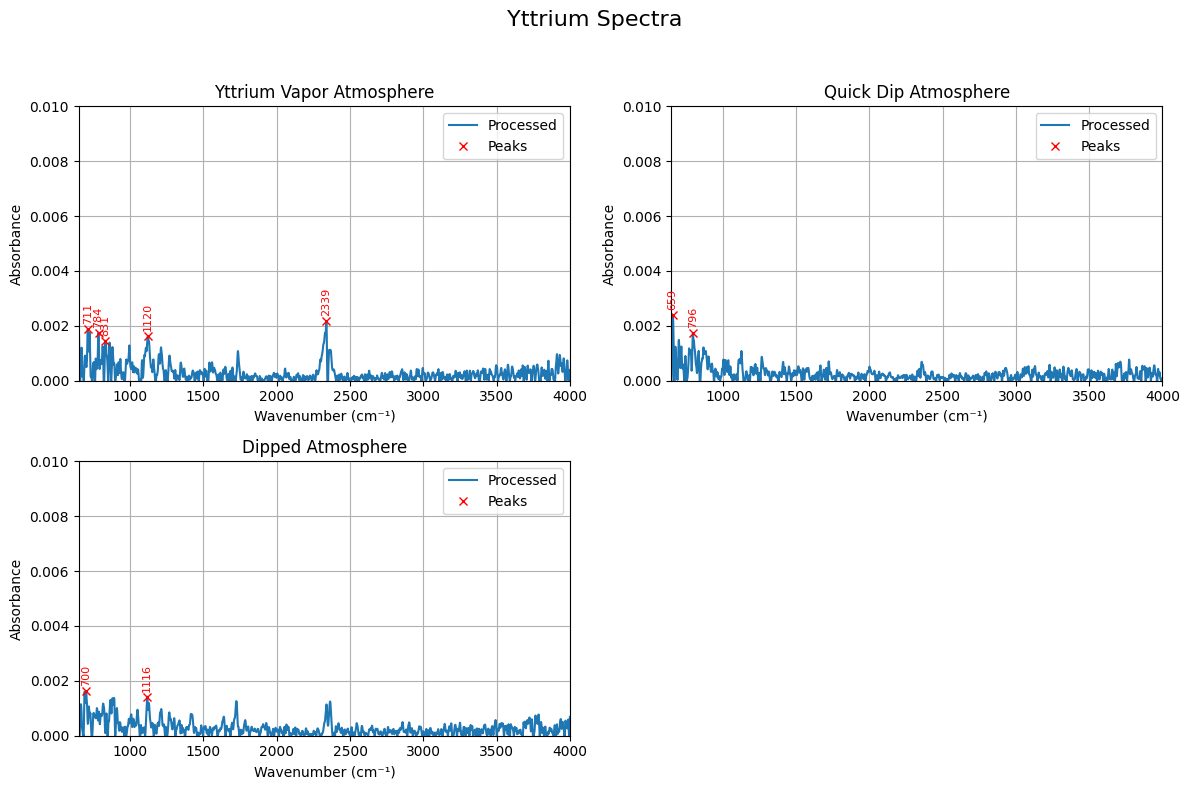

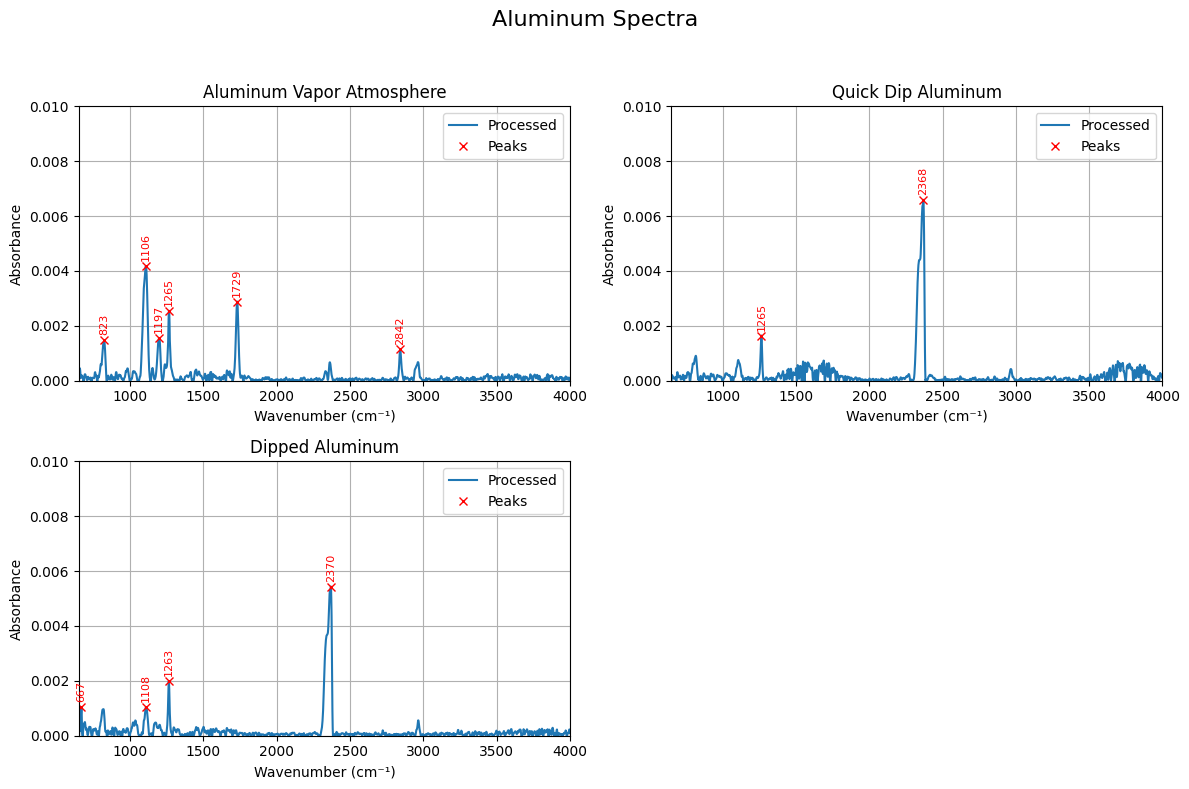

In [ ]:
#THIS IS THE CODE CHILD OF 6 DAYS OF TRIAL AND ERROR, IT IS BEAUTIFUL, THIS IS WHAT I WANT IN MY POSTER, Fuck YES!!!!!!!!!!!!!!!!!!!!!!!
#Vertical peak info
# Adjust prominence for Yttrium and Aluminum SubPlots
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.signal import find_peaks
from ramanspy.preprocessing import Pipeline
from ramanspy.preprocessing.baseline import ASLS, IASLS, IRSQR
from ramanspy.preprocessing.misc import Cropper
from ramanspy.preprocessing.denoise import SavGol
from ramanspy.preprocessing.despike import WhitakerHayes
from ramanspy import Spectrum
import ramanspy as rp

# Create Spectrum objects
specs = [
    Spectrum(file1[1], file1[0]),
    Spectrum(file2[1], file2[0]),
    Spectrum(file3[1], file3[0]),
    Spectrum(file4[1], file4[0]),
    Spectrum(file5[1], file5[0]),
    Spectrum(file6[1], file6[0])
]

labels = [
    "Yttrium Vapor Atmosphere",
    "Quick Dip Atmosphere",
    "Dipped Atmosphere",
    "Aluminum Vapor Atmosphere",
    "Quick Dip Aluminum",
    "Dipped Aluminum"
]

# Define pipeline
pipeline = Pipeline([
    Cropper(region=(650, 4000)),
    WhitakerHayes(),
    SavGol(window_length=7, polyorder=3),
    ASLS(),
    IASLS(),
    IRSQR()
])

# Apply to all
processed_specs = [pipeline.apply(spec) for spec in specs]

# Grouping
yttrium_specs = processed_specs[:3]
yttrium_raw = specs[:3]
yttrium_labels = labels[:3]

aluminum_specs = processed_specs[3:]
aluminum_raw = specs[3:]
aluminum_labels = labels[3:]
def plot_group(raw_group, proc_group, group_labels, title, prominence=0.002):
    n = len(raw_group)
    cols = 2
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 4))

    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else:
        axes = [axes]

    for i in range(rows * cols):
        if i >= n:
            axes[i].axis('off')
            continue

        ax = axes[i]

        # Plot raw
        # ax.plot(raw_group[i].spectral_axis, raw_group[i].spectral_data, linestyle='--', alpha=0.4, label='Raw')

        # Plot processed
        ax.plot(proc_group[i].spectral_axis, proc_group[i].spectral_data, linewidth=1.5, label='Processed')

        # Peak detection using scipy with adjustable prominence
        y_data = proc_group[i].spectral_data
        x_data = proc_group[i].spectral_axis
        peaks, _ = find_peaks(y_data, prominence=prominence)

        if len(peaks) > 0:
            peak_x = x_data[peaks]
            peak_y = y_data[peaks]
            ax.plot(peak_x, peak_y, 'rx', label='Peaks', markersize=6)

            # Annotate each peak with wavenumber
            for px, py in zip(peak_x, peak_y):
                ax.annotate(f"{int(px)}", xy=(px, py), xytext=(0, 5), textcoords="offset points",
                            fontsize=8, ha='center', rotation=90, color='red')

        ax.set_xlim(650, 4000)
        ax.set_ylim(0, .01)
        ax.set_title(group_labels[i])
        ax.set_xlabel("Wavenumber (cm⁻¹)")
        ax.set_ylabel("Absorbance")
        ax.grid(True)
        ax.legend()

    plt.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

plot_group(yttrium_raw, yttrium_specs, yttrium_labels, "Yttrium Spectra", prominence=0.0015)
plot_group(aluminum_raw, aluminum_specs, aluminum_labels, "Aluminum Spectra", prominence=0.001)


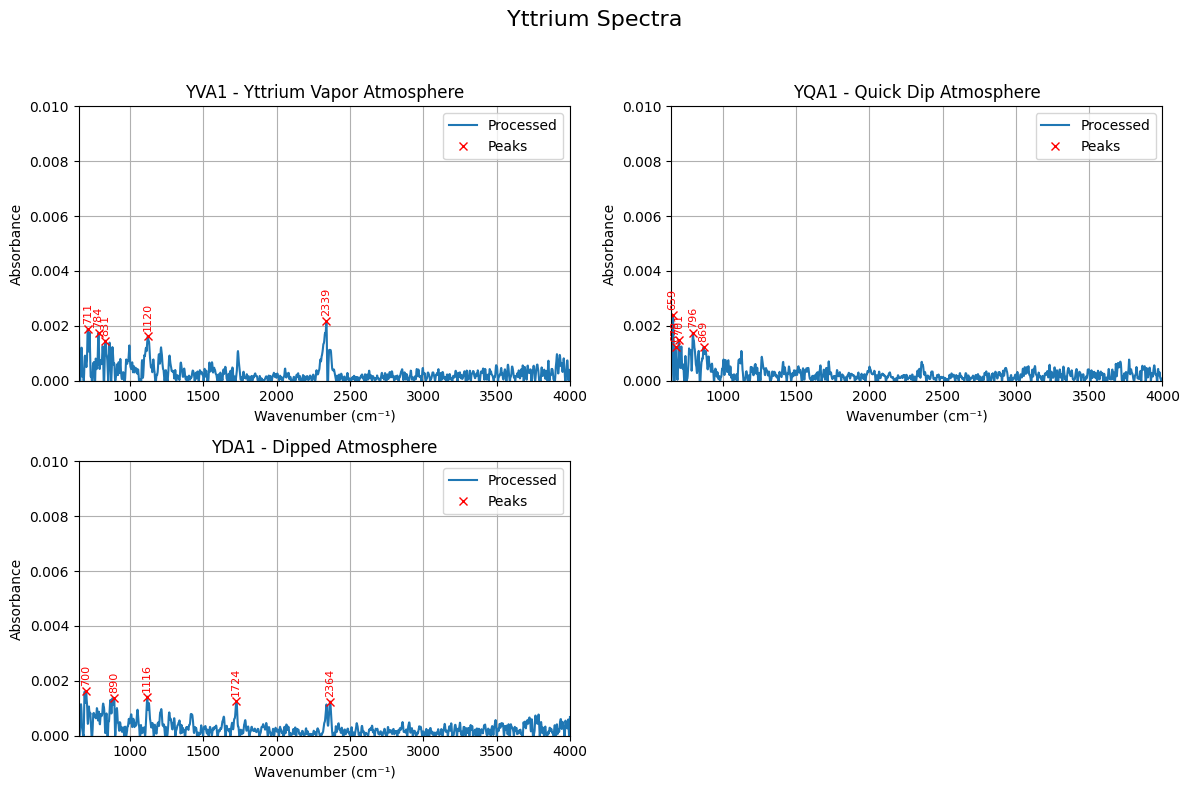

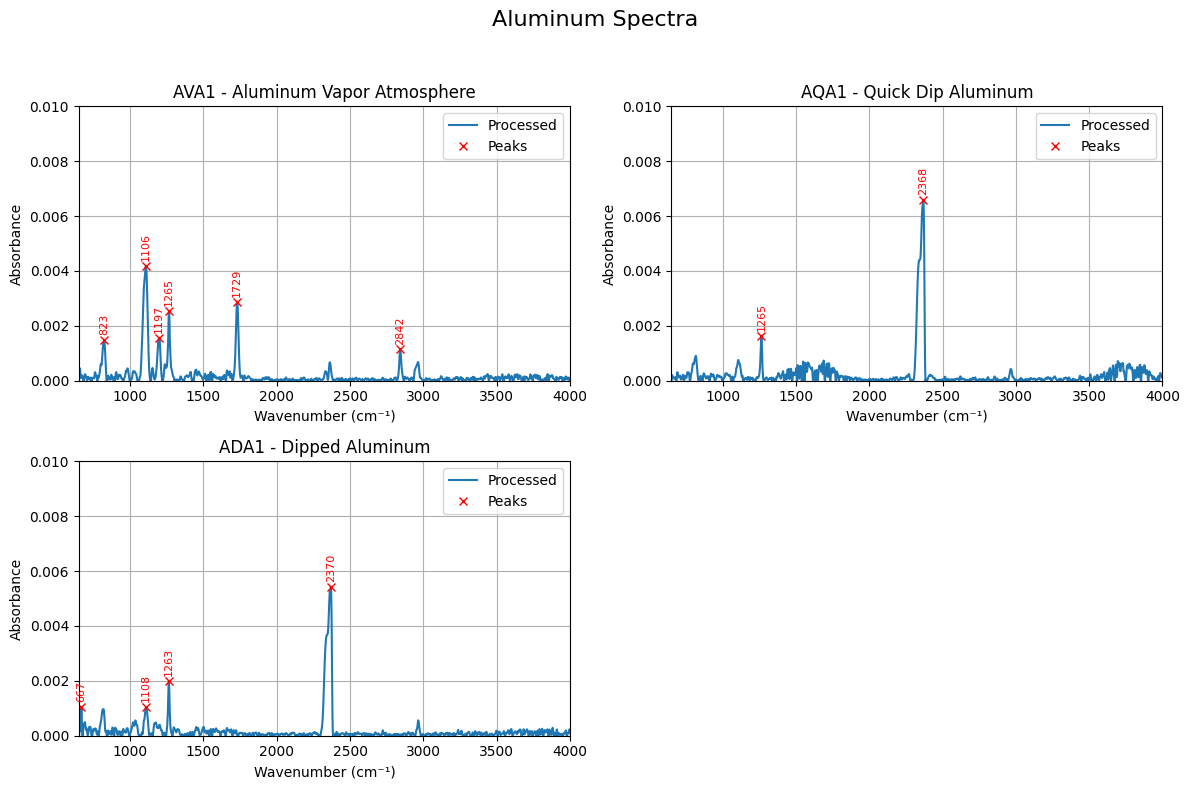

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.signal import find_peaks
from ramanspy.preprocessing import Pipeline
from ramanspy.preprocessing.baseline import ASLS, IASLS, IRSQR
from ramanspy.preprocessing.misc import Cropper
from ramanspy.preprocessing.denoise import SavGol
from ramanspy.preprocessing.despike import WhitakerHayes
from ramanspy import Spectrum
import ramanspy as rp

# Create Spectrum objects
specs = [
    Spectrum(file1[1], file1[0]),
    Spectrum(file2[1], file2[0]),
    Spectrum(file3[1], file3[0]),
    Spectrum(file4[1], file4[0]),
    Spectrum(file5[1], file5[0]),
    Spectrum(file6[1], file6[0])
]

labels = [
    "YVA1 - Yttrium Vapor Atmosphere",
    "YQA1 - Quick Dip Atmosphere",
    "YDA1 - Dipped Atmosphere",
    "AVA1 - Aluminum Vapor Atmosphere",
    "AQA1 - Quick Dip Aluminum",
    "ADA1 - Dipped Aluminum"
]

# Define pipeline
pipeline = Pipeline([
    Cropper(region=(650, 4000)),
    WhitakerHayes(),
    SavGol(window_length=7, polyorder=3),
    ASLS(),
    IASLS(),
    IRSQR()
])

# Apply to all
processed_specs = [pipeline.apply(spec) for spec in specs]

# Grouping
yttrium_specs = processed_specs[:3]
yttrium_raw = specs[:3]
yttrium_labels = labels[:3]

aluminum_specs = processed_specs[3:]
aluminum_raw = specs[3:]
aluminum_labels = labels[3:]

# Plotting function with prominence and max_peaks control
def plot_group(raw_group, proc_group, group_labels, title, prominence=0.002, max_peaks=8):
    n = len(raw_group)
    cols = 2
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 4))

    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else:
        axes = [axes]

    for i in range(rows * cols):
        if i >= n:
            axes[i].axis('off')
            continue

        ax = axes[i]

        # Plot raw
        # ax.plot(raw_group[i].spectral_axis, raw_group[i].spectral_data, linestyle='--', alpha=0.4, label='Raw')

        # Plot processed
        x_data = proc_group[i].spectral_axis
        y_data = proc_group[i].spectral_data
        ax.plot(x_data, y_data, linewidth=1.5, label='Processed')

        # Peak detection
        peaks, _ = find_peaks(y_data, prominence=prominence)

        if len(peaks) > 0:
            # Sort and take top N peaks by intensity
            peak_intensities = y_data[peaks]
            top_indices = np.argsort(peak_intensities)[-max_peaks:]
            top_peaks = peaks[top_indices]

            peak_x = x_data[top_peaks]
            peak_y = y_data[top_peaks]
            ax.plot(peak_x, peak_y, 'rx', label='Peaks', markersize=6)

            # Annotate peak values
            for px, py in zip(peak_x, peak_y):
                ax.annotate(f"{int(px)}", xy=(px, py), xytext=(0, 5), textcoords="offset points",
                            fontsize=8, ha='center', rotation=90, color='red')

        ax.set_xlim(650, 4000)
        ax.set_ylim(0, .01)
        ax.set_title(group_labels[i])
        ax.set_xlabel("Wavenumber (cm⁻¹)")
        ax.set_ylabel("Absorbance")
        ax.grid(True)
        ax.legend()

    plt.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# Run plots with custom prominence values
plot_group(yttrium_raw, yttrium_specs, yttrium_labels, "Yttrium Spectra", prominence=0.001, max_peaks=5)
plot_group(aluminum_raw, aluminum_specs, aluminum_labels, "Aluminum Spectra", prominence=0.001, max_peaks=6)


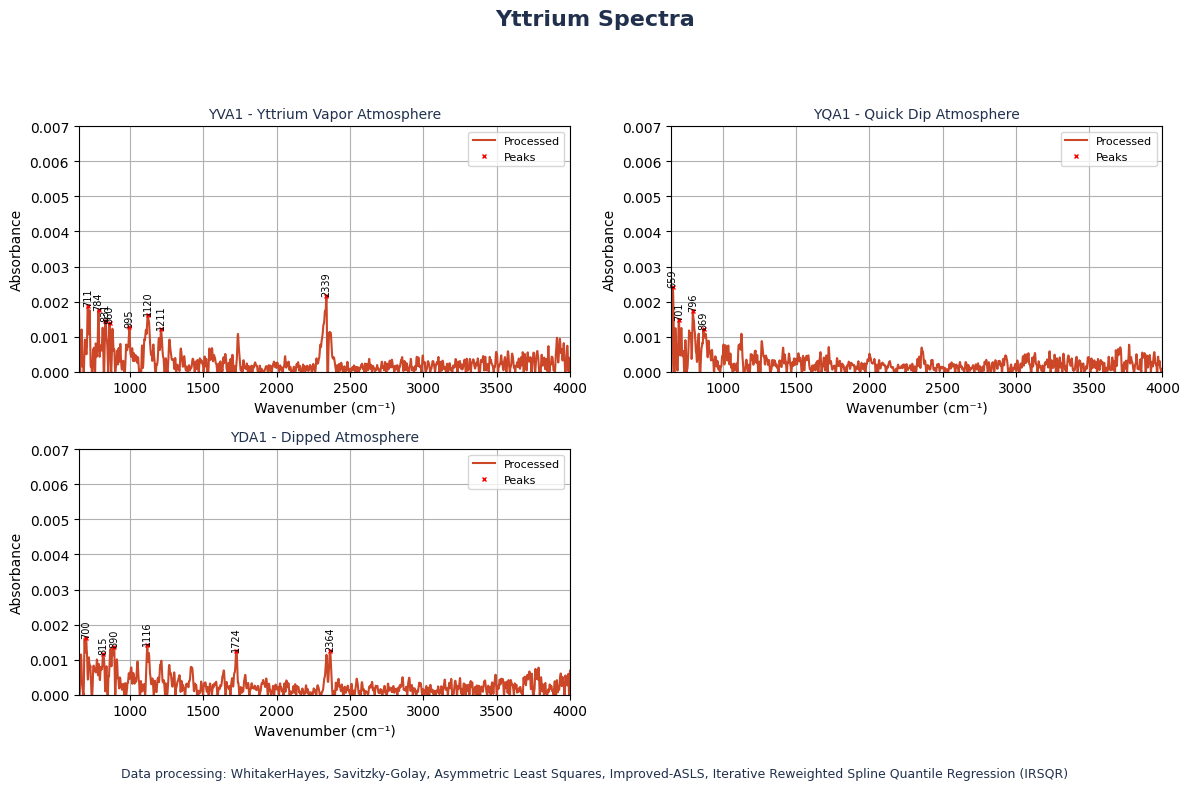

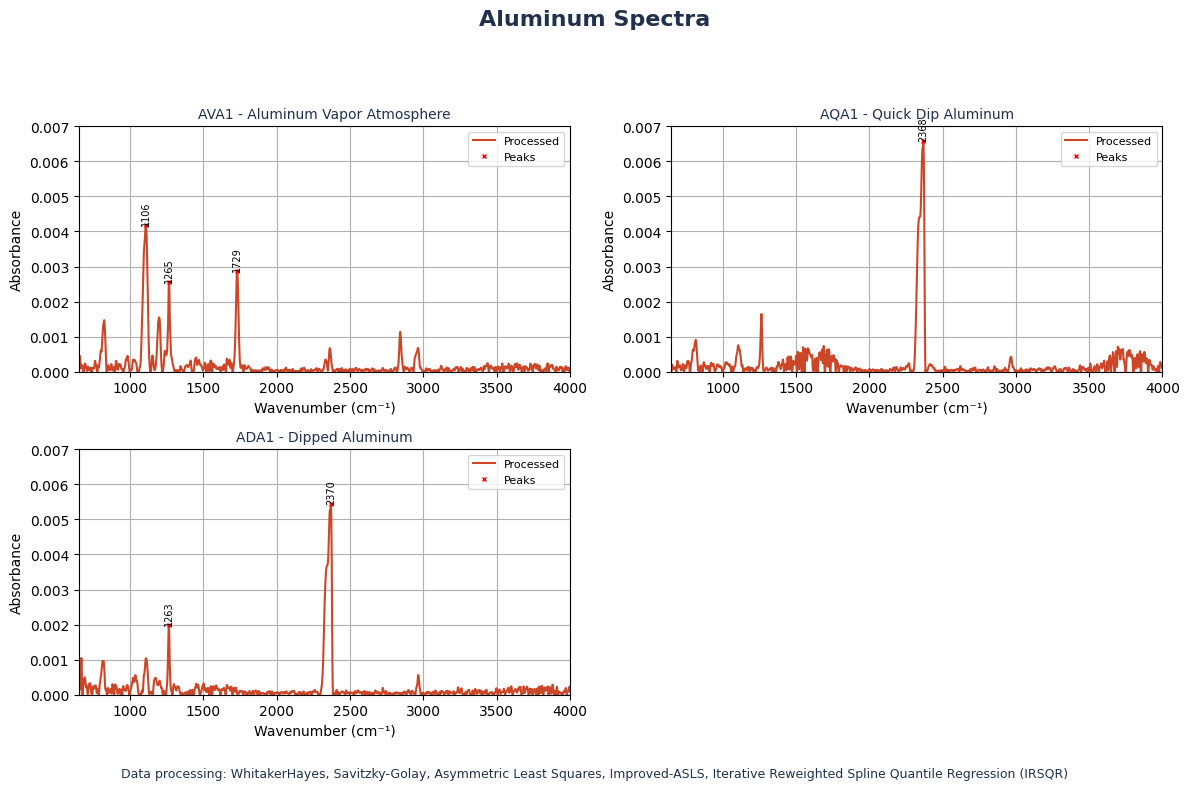

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.signal import find_peaks
from ramanspy.preprocessing import Pipeline
from ramanspy.preprocessing.baseline import ASLS, IASLS, IRSQR
from ramanspy.preprocessing.misc import Cropper
from ramanspy.preprocessing.denoise import SavGol
from ramanspy.preprocessing.despike import WhitakerHayes
from ramanspy import Spectrum
import ramanspy as rp

# Color palette
TITLE_COLOR = "#21314D"
HEADING_COLOR = "#CC4628"
BACKGROUND_COLOR = "#FFFFFF"

# Spectrum creation
specs = [
    Spectrum(file1[1], file1[0]),
    Spectrum(file2[1], file2[0]),
    Spectrum(file3[1], file3[0]),
    Spectrum(file4[1], file4[0]),
    Spectrum(file5[1], file5[0]),
    Spectrum(file6[1], file6[0])
]

labels = [
    "YVA1 - Yttrium Vapor Atmosphere",
    "YQA1 - Quick Dip Atmosphere",
    "YDA1 - Dipped Atmosphere",
    "AVA1 - Aluminum Vapor Atmosphere",
    "AQA1 - Quick Dip Aluminum",
    "ADA1 - Dipped Aluminum"
]

# Processing pipeline
pipeline = Pipeline([
    Cropper(region=(650, 4000)),
    WhitakerHayes(),
    SavGol(window_length=7, polyorder=3),
    ASLS(),
    IASLS(),
    IRSQR()
])

processed_specs = [pipeline.apply(spec) for spec in specs]

# Grouping
yttrium_specs = processed_specs[:3]
yttrium_raw = specs[:3]
yttrium_labels = labels[:3]

aluminum_specs = processed_specs[3:]
aluminum_raw = specs[3:]
aluminum_labels = labels[3:]

# Plotting function
def plot_group(raw_group, proc_group, group_labels, title, prominence_value):
    n = len(raw_group)
    cols = 2
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 4))
    fig.patch.set_facecolor(BACKGROUND_COLOR)

    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else:
        axes = [axes]

    for i in range(rows * cols):
        if i >= n:
            axes[i].axis('off')
            continue

        ax = axes[i]

        # Raw
        # ax.plot(raw_group[i].spectral_axis, raw_group[i].spectral_data, linestyle='--', alpha=0.4, label='Raw', color='gray')

        # Processed
        ax.plot(proc_group[i].spectral_axis, proc_group[i].spectral_data, linewidth=1.5, label='Processed', color=HEADING_COLOR)

        # Peaks
        y_data = proc_group[i].spectral_data
        peaks, _ = find_peaks(y_data, prominence=prominence_value)
        if len(peaks) > 0:
            peak_x = proc_group[i].spectral_axis[peaks]
            peak_y = y_data[peaks]
            ax.plot(peak_x, peak_y, 'rx', label='Peaks', markersize=3)
            for x, y in zip(peak_x, peak_y):
                ax.text(x, y, f'{int(x)}', rotation=90, va='bottom', ha='center', fontsize=7, color='black')

        ax.set_xlim(650, 4000)
        ax.set_ylim(0, 0.007)
        ax.set_title(group_labels[i], color=TITLE_COLOR, fontsize=10)
        ax.set_xlabel("Wavenumber (cm⁻¹)")
        ax.set_ylabel("Absorbance")
        ax.grid(True)
        ax.legend(fontsize=8)

    # Title and processing block
    plt.suptitle(title, fontsize=16, color=TITLE_COLOR, fontweight='bold')
    plt.figtext(0.5, 0.02,
        "Data processing: WhitakerHayes, Savitzky-Golay, Asymmetric Least Squares, Improved-ASLS, Iterative Reweighted Spline Quantile Regression (IRSQR)",
        wrap=True, horizontalalignment='center', fontsize=9, color=TITLE_COLOR)
    plt.tight_layout(rect=[0, 0.05, 1, 0.92])
    plt.show()

# Final plots
plot_group(yttrium_raw, yttrium_specs, yttrium_labels, "Yttrium Spectra", prominence_value=0.00125)
plot_group(aluminum_raw, aluminum_specs, aluminum_labels, "Aluminum Spectra", prominence_value=0.002)


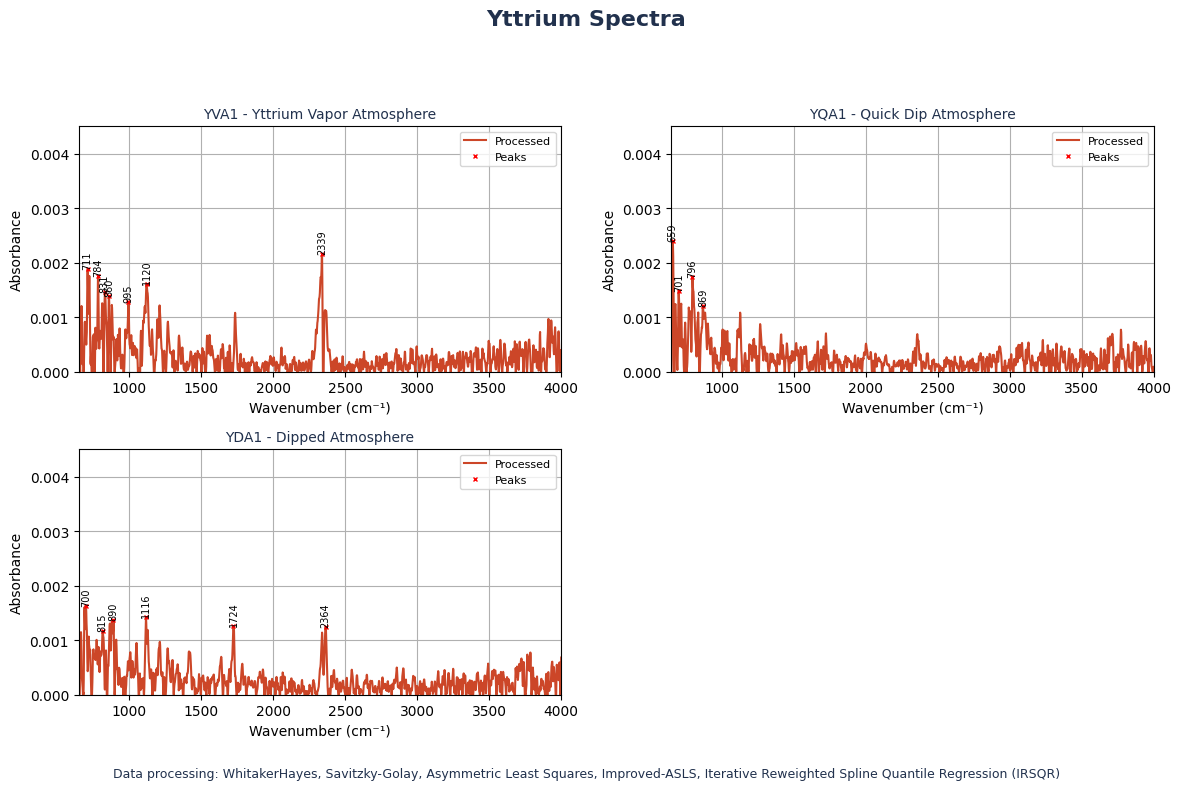

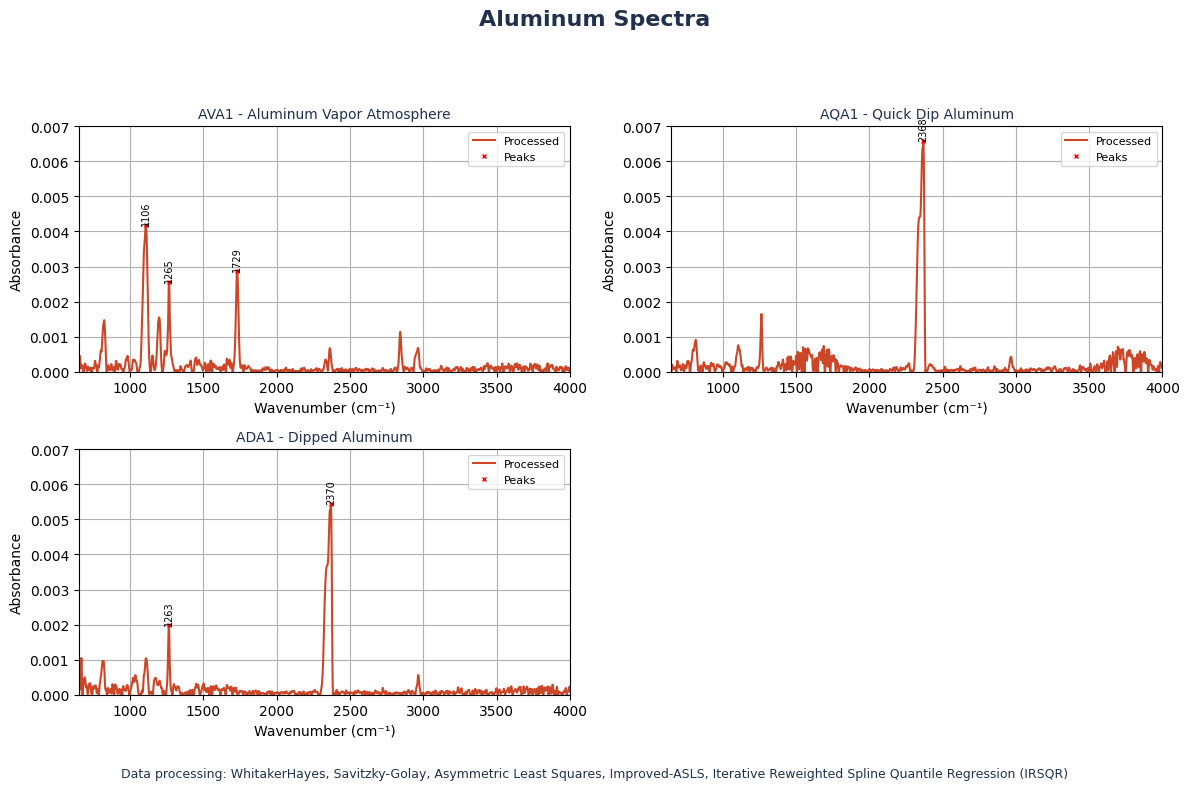

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.signal import find_peaks
from ramanspy.preprocessing import Pipeline
from ramanspy.preprocessing.baseline import ASLS, IASLS, IRSQR
from ramanspy.preprocessing.misc import Cropper
from ramanspy.preprocessing.denoise import SavGol
from ramanspy.preprocessing.despike import WhitakerHayes
from ramanspy import Spectrum
import ramanspy as rp

# Color palette
TITLE_COLOR = "#21314D"
HEADING_COLOR = "#CC4628"
BACKGROUND_COLOR = "#FFFFFF"

# Spectrum creation
specs = [
    Spectrum(file1[1], file1[0]),
    Spectrum(file2[1], file2[0]),
    Spectrum(file3[1], file3[0]),
    Spectrum(file4[1], file4[0]),
    Spectrum(file5[1], file5[0]),
    Spectrum(file6[1], file6[0])
]

labels = [
    "YVA1 - Yttrium Vapor Atmosphere",
    "YQA1 - Quick Dip Atmosphere",
    "YDA1 - Dipped Atmosphere",
    "AVA1 - Aluminum Vapor Atmosphere",
    "AQA1 - Quick Dip Aluminum",
    "ADA1 - Dipped Aluminum"
]

# Processing pipeline
pipeline = Pipeline([
    Cropper(region=(650, 4000)),
    WhitakerHayes(),
    SavGol(window_length=7, polyorder=3),
    ASLS(),
    IASLS(),
    IRSQR()
])

processed_specs = [pipeline.apply(spec) for spec in specs]

# Grouping
yttrium_specs = processed_specs[:3]
yttrium_raw = specs[:3]
yttrium_labels = labels[:3]

aluminum_specs = processed_specs[3:]
aluminum_raw = specs[3:]
aluminum_labels = labels[3:]

# Plotting function with max_peaks + save_as_png
def plot_group(raw_group, proc_group, group_labels, title, prominence_value, max_peaks=None, y_max=0.007, save_as=None):
    n = len(raw_group)
    cols = 2
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 4))
    fig.patch.set_facecolor(BACKGROUND_COLOR)

    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else:
        axes = [axes]

    for i in range(rows * cols):
        if i >= n:
            axes[i].axis('off')
            continue

        ax = axes[i]

        # Processed
        ax.plot(proc_group[i].spectral_axis, proc_group[i].spectral_data, linewidth=1.5, label='Processed', color=HEADING_COLOR)

        # Peaks
        y_data = proc_group[i].spectral_data
        peaks, _ = find_peaks(y_data, prominence=prominence_value)

        # Limit number of peaks if specified
        if max_peaks and len(peaks) > max_peaks:
            peak_prominences = y_data[peaks]
            sorted_indices = np.argsort(peak_prominences)[-max_peaks:]  # largest peaks only
            peaks = peaks[sorted_indices]

        if len(peaks) > 0:
            peak_x = proc_group[i].spectral_axis[peaks]
            peak_y = y_data[peaks]
            ax.plot(peak_x, peak_y, 'rx', label='Peaks', markersize=3)
            for x, y in zip(peak_x, peak_y):
                ax.text(x, y, f'{int(x)}', rotation=90, va='bottom', ha='center', fontsize=7, color='black')

        ax.set_xlim(650, 4000)
        ax.set_ylim(0, y_max)
        ax.set_title(group_labels[i], color=TITLE_COLOR, fontsize=10)
        ax.set_xlabel("Wavenumber (cm⁻¹)")
        ax.set_ylabel("Absorbance")
        ax.grid(True)
        ax.legend(fontsize=8)

    # Title and processing block
    plt.suptitle(title, fontsize=16, color=TITLE_COLOR, fontweight='bold')
    plt.figtext(0.5, 0.02,
        "Data processing: WhitakerHayes, Savitzky-Golay, Asymmetric Least Squares, Improved-ASLS, Iterative Reweighted Spline Quantile Regression (IRSQR)",
        wrap=True, horizontalalignment='center', fontsize=9, color=TITLE_COLOR)
    plt.tight_layout(rect=[0, 0.05, 1, 0.92])

    if save_as:
        plt.savefig(save_as, dpi=300, bbox_inches='tight', facecolor=BACKGROUND_COLOR)

    plt.show()

# Final plots with max_peaks + save
plot_group(yttrium_raw, yttrium_specs, yttrium_labels, "Yttrium Spectra",
           prominence_value=0.00125, max_peaks=7, y_max=0.0045, save_as="yttrium_spectra.png")

plot_group(aluminum_raw, aluminum_specs, aluminum_labels, "Aluminum Spectra",
           prominence_value=0.002, max_peaks=5, y_max=0.007, save_as="aluminum_spectra.png")


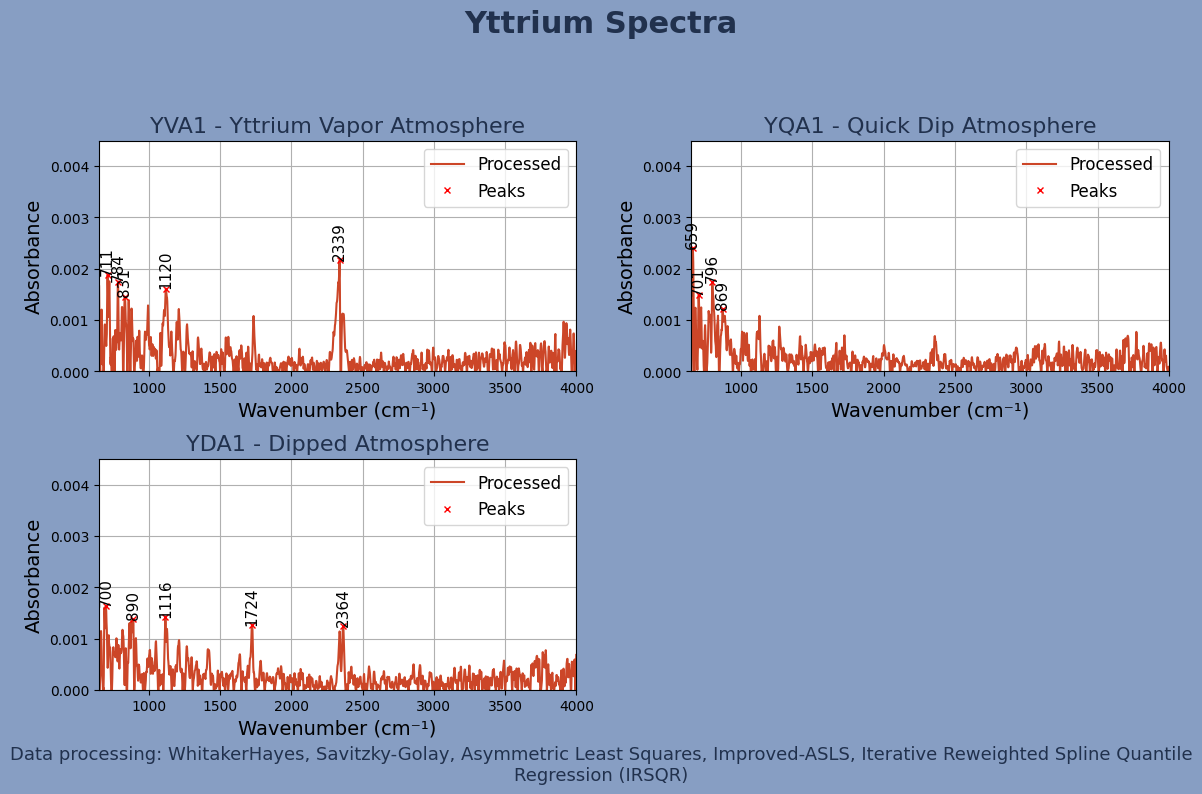

Saved to: /content/drive/My Drive/Silane 04_16_2025/CSV Files/yttrium_spectra.png


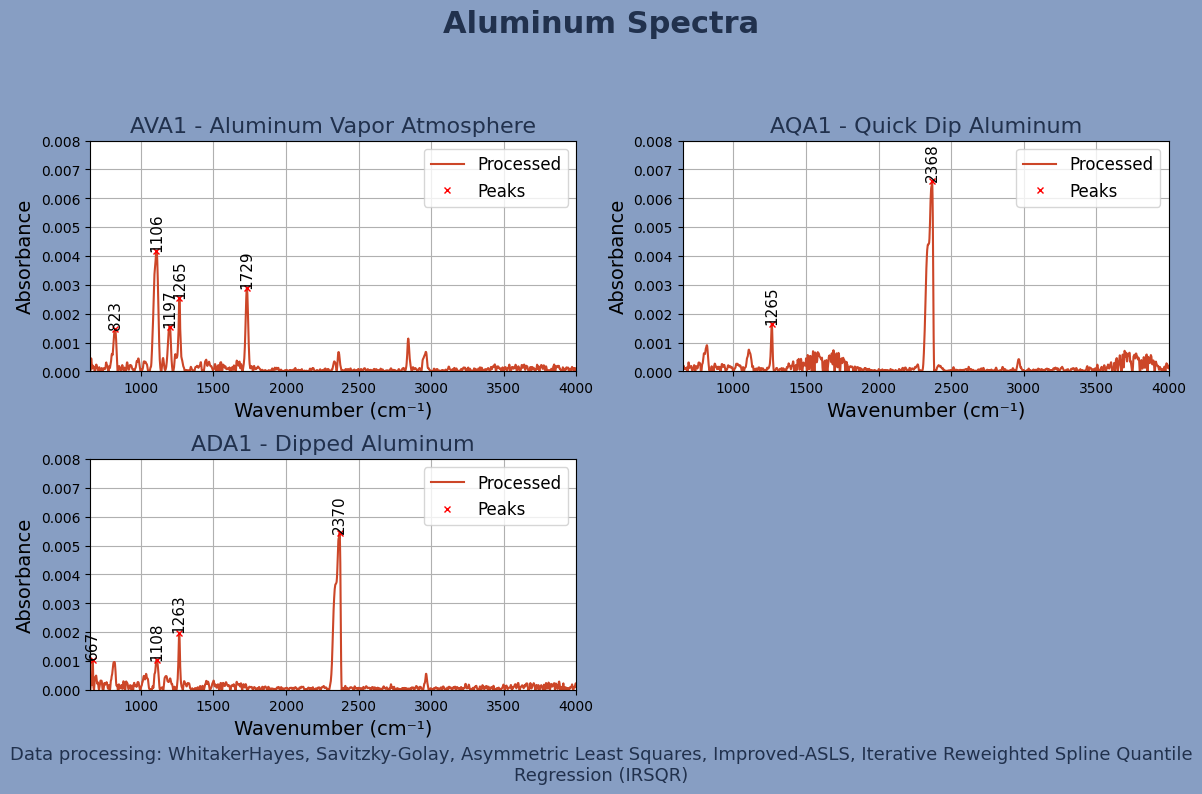

Saved to: /content/drive/My Drive/Silane 04_16_2025/CSV Files/aluminum_spectra.png


In [ ]:
#THE FINAL OF FINAL ITERATIONS THAT DOES EXACTLY WHAT I WANT FOR MY DATA COLLECTION################FUCK YEAH##########

import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.signal import find_peaks
from ramanspy.preprocessing import Pipeline
from ramanspy.preprocessing.baseline import ASLS, IASLS, IRSQR
from ramanspy.preprocessing.misc import Cropper
from ramanspy.preprocessing.denoise import SavGol
from ramanspy.preprocessing.despike import WhitakerHayes
from ramanspy import Spectrum
import ramanspy as rp
import os

# Color palette
TITLE_COLOR = "#21314D"
HEADING_COLOR = "#CC4628"
BACKGROUND_COLOR = "#879EC3"

# Save path explicitly set to your folder in Drive
save_dir = '/content/drive/My Drive/Silane 04_16_2025/CSV Files/'

# Spectrum creation
specs = [
    Spectrum(file1[1], file1[0]),
    Spectrum(file2[1], file2[0]),
    Spectrum(file3[1], file3[0]),
    Spectrum(file4[1], file4[0]),
    Spectrum(file5[1], file5[0]),
    Spectrum(file6[1], file6[0])
]

labels = [
    "YVA1 - Yttrium Vapor Atmosphere",
    "YQA1 - Quick Dip Atmosphere",
    "YDA1 - Dipped Atmosphere",
    "AVA1 - Aluminum Vapor Atmosphere",
    "AQA1 - Quick Dip Aluminum",
    "ADA1 - Dipped Aluminum"
]

# Processing pipeline
pipeline = Pipeline([
    Cropper(region=(650, 4000)),
    WhitakerHayes(),
    SavGol(window_length=7, polyorder=3),
    ASLS(),
    IASLS(),
    IRSQR()
])

processed_specs = [pipeline.apply(spec) for spec in specs]

# Grouping
yttrium_specs = processed_specs[:3]
yttrium_raw = specs[:3]
yttrium_labels = labels[:3]

aluminum_specs = processed_specs[3:]
aluminum_raw = specs[3:]
aluminum_labels = labels[3:]

# Plotting function
def plot_group(raw_group, proc_group, group_labels, title, prominence_value, y_max, max_peaks, save_filename):
    n = len(raw_group)
    cols = 2
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 4))
    fig.patch.set_facecolor(BACKGROUND_COLOR)

    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else:
        axes = [axes]

    for i in range(rows * cols):
        if i >= n:
            axes[i].axis('off')
            continue

        ax = axes[i]

        ax.plot(proc_group[i].spectral_axis, proc_group[i].spectral_data, linewidth=1.5, label='Processed', color=HEADING_COLOR)

        y_data = proc_group[i].spectral_data
        peaks, _ = find_peaks(y_data, prominence=prominence_value)

        if len(peaks) > 0:
            if max_peaks is not None and len(peaks) > max_peaks:
                peak_proms = y_data[peaks]
                sorted_idx = np.argsort(peak_proms)[-max_peaks:]
                peaks = peaks[sorted_idx]

            peak_x = proc_group[i].spectral_axis[peaks]
            peak_y = y_data[peaks]
            ax.plot(peak_x, peak_y, 'rx', label='Peaks', markersize=5)
            for x, y in zip(peak_x, peak_y):
                ax.text(x, y, f'{int(x)}', rotation=90, va='bottom', ha='center', fontsize=11, color='black')

        ax.set_xlim(650, 4000)
        ax.set_ylim(0, y_max)
        ax.set_title(group_labels[i], color=TITLE_COLOR, fontsize=16)
        ax.set_xlabel("Wavenumber (cm⁻¹)", fontsize=14)
        ax.set_ylabel("Absorbance", fontsize=14)
        ax.grid(True)
        ax.legend(fontsize=12)

    plt.suptitle(title, fontsize=22, color=TITLE_COLOR, fontweight='bold')
    plt.figtext(0.5, 0.02,
        "Data processing: WhitakerHayes, Savitzky-Golay, Asymmetric Least Squares, Improved-ASLS, Iterative Reweighted Spline Quantile Regression (IRSQR)",
        wrap=True, horizontalalignment='center', fontsize=13, color=TITLE_COLOR)
    plt.tight_layout(rect=[0, 0.05, 1, 0.92])

    save_path = os.path.join(save_dir, save_filename)
    plt.savefig(save_path, dpi=300, facecolor=fig.get_facecolor(), bbox_inches='tight')
    plt.show()
    print(f"Saved to: {save_path}")

# Final plots
plot_group(yttrium_raw, yttrium_specs, yttrium_labels, "Yttrium Spectra",
           prominence_value=0.00125, y_max=0.0045, max_peaks=5, save_filename="yttrium_spectra.png")

plot_group(aluminum_raw, aluminum_specs, aluminum_labels, "Aluminum Spectra",
           prominence_value=0.001, y_max=0.008, max_peaks=5, save_filename="aluminum_spectra.png")



In [ ]:
import os

# Save path explicitly set to your folder in Drive
save_dir = '/content/drive/My Drive/Silane 04_16_2025/CSV Files/'
# New combined plot function (with offset, CO2 masking, and simple labels)
def plot_combined(raw_group, proc_group, group_labels, title, prominence_value, y_offset, y_max, max_peaks, save_filename):
    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor(BACKGROUND_COLOR)

    for i, spec in enumerate(proc_group):
        spectral_axis = spec.spectral_axis
        spectral_data = spec.spectral_data + i * y_offset  # Apply vertical offset

        # Mask CO₂ region (2250–2400 cm⁻¹) by filling over it
        mask = (spectral_axis >= 2250) & (spectral_axis <= 2400)
        masked_axis = spectral_axis[~mask]
        masked_data = spectral_data[~mask]

        # Plot processed spectrum
        ax.plot(masked_axis, masked_data, linewidth=1.5, label=group_labels[i], color=HEADING_COLOR)

        # Peak finding
        peaks, _ = find_peaks(masked_data, prominence=prominence_value)

        if len(peaks) > 0:
            if max_peaks is not None and len(peaks) > max_peaks:
                peak_proms = masked_data[peaks]
                sorted_idx = np.argsort(peak_proms)[-max_peaks:]
                peaks = peaks[sorted_idx]

            peak_x = masked_axis[peaks]
            peak_y = masked_data[peaks]
            ax.plot(peak_x, peak_y, 'rx', markersize=5)
            for x, y in zip(peak_x, peak_y):
                ax.text(x, y, f'{int(x)}', rotation=90, va='bottom', ha='center', fontsize=10, color='black')

    # Shade the CO2 region (optional but nice)
    ax.axvspan(2250, 2400, color='white', zorder=0)

    ax.set_xlim(650, 4000)
    ax.set_ylim(0, y_max)
    ax.set_title(title, color=TITLE_COLOR, fontsize=20, fontweight='bold')
    ax.set_xlabel("Wavenumber (cm⁻¹)", fontsize=14)
    ax.set_ylabel("Absorbance (offset for clarity)", fontsize=14)
    ax.grid(True)
    ax.legend(fontsize=12)

    plt.figtext(0.5, 0.02,
        "Data processing: WhitakerHayes, Savitzky-Golay, ASLS, IASLS, IRSQR. CO₂ region (2250–2400 cm⁻¹) removed.",
        wrap=True, horizontalalignment='center', fontsize=12, color=TITLE_COLOR)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])

    save_path = os.path.join(save_dir, save_filename)
    plt.savefig(save_path, dpi=300, facecolor=fig.get_facecolor(), bbox_inches='tight')
    plt.show()
    print(f"Saved to: {save_path}")


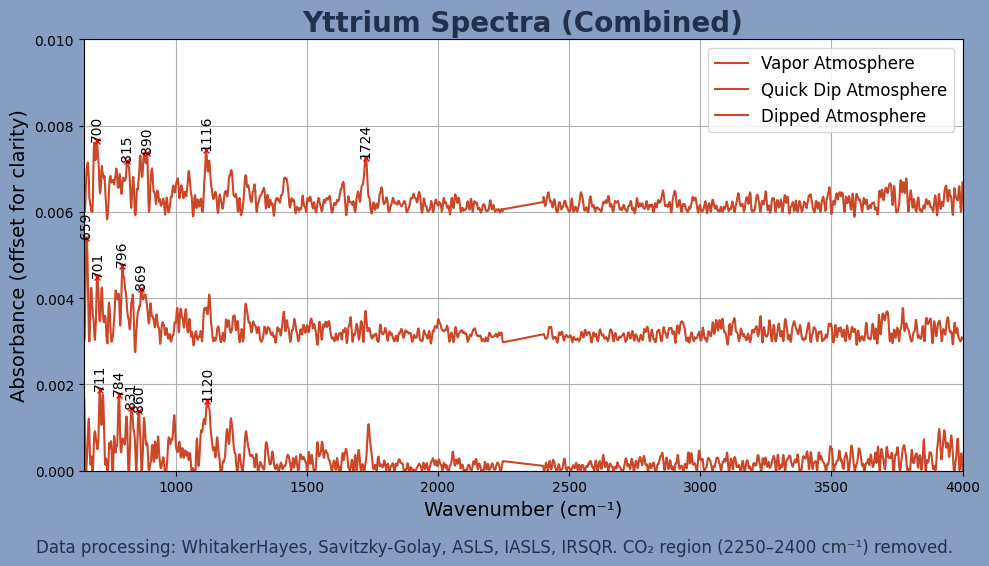

Saved to: /content/drive/My Drive/Silane 04_16_2025/CSV Files/yttrium_combined_spectra.png


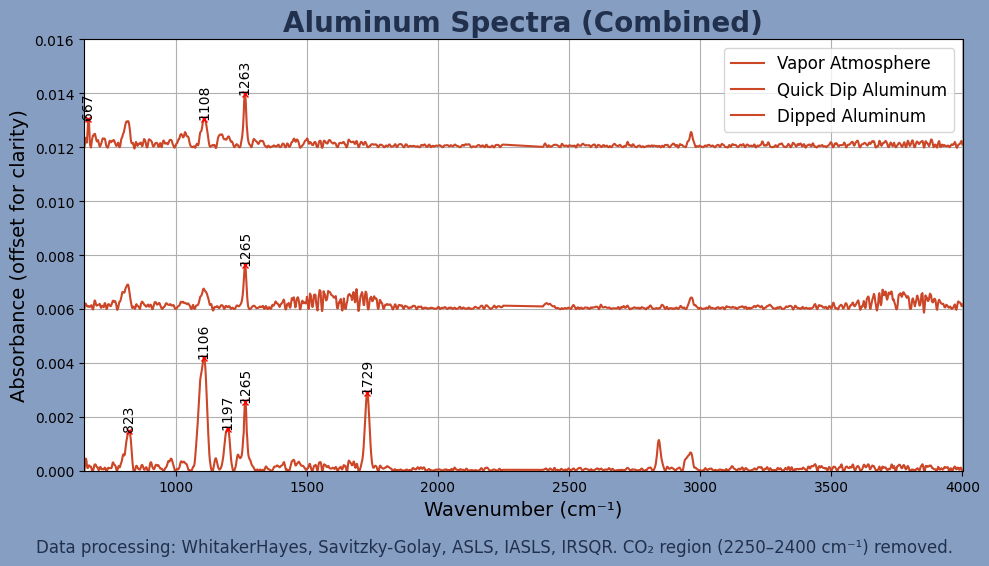

Saved to: /content/drive/My Drive/Silane 04_16_2025/CSV Files/aluminum_combined_spectra.png


In [ ]:
# Final combined plots
# Updated labels without sample names
yttrium_labels_simple = ["Vapor Atmosphere", "Quick Dip Atmosphere", "Dipped Atmosphere"]
aluminum_labels_simple = ["Vapor Atmosphere", "Quick Dip Aluminum", "Dipped Aluminum"]

plot_combined(yttrium_raw, yttrium_specs, yttrium_labels_simple, "Yttrium Spectra (Combined)",
              prominence_value=0.00125, y_offset=0.003, y_max=0.010, max_peaks=5, save_filename="yttrium_combined_spectra.png")

plot_combined(aluminum_raw, aluminum_specs, aluminum_labels_simple, "Aluminum Spectra (Combined)",
              prominence_value=0.001, y_offset=0.006, y_max=0.016, max_peaks=5, save_filename="aluminum_combined_spectra.png")


In [ ]:
import os
BACKGROUND_COLOR2 = "#879EC3"
# Save path explicitly set to your folder in Drive
save_dir = '/content/drive/My Drive/Silane 04_16_2025/CSV Files/'

def plot_combined_fixed(raw_group, proc_group, group_labels, title, prominence_value, y_offset, y_max, max_peaks, save_filename):
    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor(BACKGROUND_COLOR)

    spectrum_colors = [TITLE_COLOR, HEADING_COLOR, BACKGROUND_COLOR2]  # Different colors for each spectrum

    for i, spec in enumerate(proc_group):
        spectral_axis = spec.spectral_axis
        spectral_data = spec.spectral_data + i * y_offset  # Apply vertical offset

        # Mask CO₂ region (2250–2400 cm⁻¹)
        mask_co2 = (spectral_axis >= 2250) & (spectral_axis <= 2400)
        before_co2 = ~mask_co2 & (spectral_axis < 2250)
        after_co2 = ~mask_co2 & (spectral_axis > 2400)

        # Plot spectrum in two parts, to create real gap
        ax.plot(spectral_axis[before_co2], spectral_data[before_co2],
                linewidth=1.5, label=group_labels[i], color=spectrum_colors[i % len(spectrum_colors)])
        ax.plot(spectral_axis[after_co2], spectral_data[after_co2],
                linewidth=1.5, color=spectrum_colors[i % len(spectrum_colors)])

        # Peak finding (only outside the CO₂ region)
        spectral_axis_masked = spectral_axis[~mask_co2]
        spectral_data_masked = spectral_data[~mask_co2]
        peaks, _ = find_peaks(spectral_data_masked, prominence=prominence_value)

        if len(peaks) > 0:
            if max_peaks is not None and len(peaks) > max_peaks:
                peak_proms = spectral_data_masked[peaks]
                sorted_idx = np.argsort(peak_proms)[-max_peaks:]
                peaks = peaks[sorted_idx]

            peak_x = spectral_axis_masked[peaks]
            peak_y = spectral_data_masked[peaks]
            ax.plot(peak_x, peak_y, 'rx', markersize=5)
            for x, y in zip(peak_x, peak_y):
                ax.text(x, y, f'{int(x)}', rotation=90, va='bottom', ha='center', fontsize=10, color='black')

    # Optional: lightly shade where CO₂ would have been
    ax.axvspan(2250, 2400, color='white', zorder=0)

    ax.set_xlim(650, 4000)
    ax.set_ylim(0, y_max)
    ax.set_title(title, color=TITLE_COLOR, fontsize=20, fontweight='bold')
    ax.set_xlabel("Wavenumber (cm⁻¹)", fontsize=14)
    ax.set_ylabel(f"Absorbance (offset by {y_offset})", fontsize=14)
    ax.grid(True)
    ax.legend(fontsize=12, loc="upper right", bbox_to_anchor=(1, 1), frameon=True)

    plt.figtext(0.5, 0.02,
        "Data processing: WhitakerHayes, Savitzky-Golay, Asymmetric Least Squares, Improved-ASLS, Iterative Reweighted Spline Quantile Regression (IRSQR), CO₂ region (2250–2400 cm⁻¹) removed.",
        wrap=True, horizontalalignment='center', fontsize=12, color=TITLE_COLOR)
    plt.tight_layout(rect=[0, 0.05, 1, 1])

    save_path = os.path.join(save_dir, save_filename)
    plt.savefig(save_path, dpi=300, facecolor=fig.get_facecolor(), bbox_inches='tight')
    plt.show()
    print(f"Saved to: {save_path}")


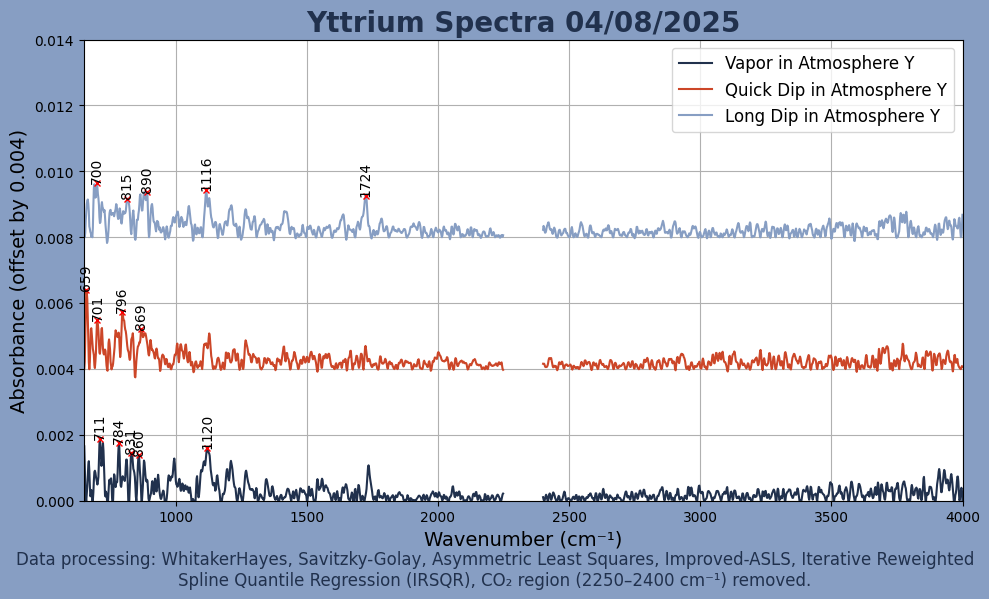

Saved to: /content/drive/My Drive/Silane 04_16_2025/CSV Files/yttrium_combined_spectra.png


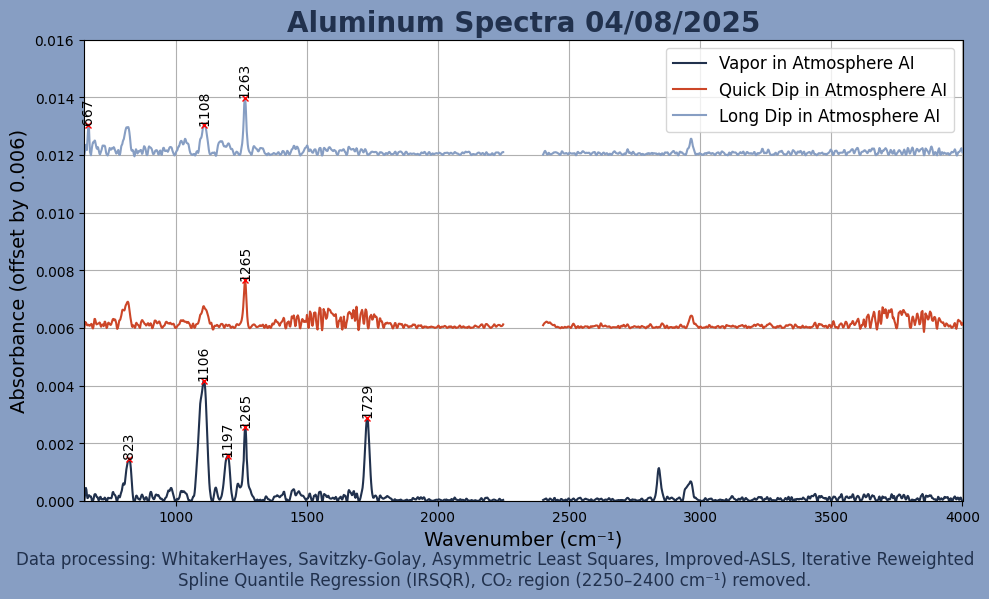

Saved to: /content/drive/My Drive/Silane 04_16_2025/CSV Files/aluminum_combined_spectra.png


In [ ]:
# Final combined plots with better color differentiation
yttrium_labels_simple = ["Vapor in Atmosphere Y", "Quick Dip in Atmosphere Y", "Long Dip in Atmosphere Y"]
aluminum_labels_simple = ["Vapor in Atmosphere AI", "Quick Dip in Atmosphere AI", "Long Dip in Atmosphere AI"]

plot_combined_fixed(yttrium_raw, yttrium_specs, yttrium_labels_simple, "Yttrium Spectra 04/08/2025",
                    prominence_value=0.00125, y_offset=0.004, y_max=0.014, max_peaks=5,
                    save_filename="yttrium_combined_spectra.png")

plot_combined_fixed(aluminum_raw, aluminum_specs, aluminum_labels_simple, "Aluminum Spectra 04/08/2025",
                    prominence_value=0.001, y_offset=0.006, y_max=0.016, max_peaks=5,
                    save_filename="aluminum_combined_spectra.png")


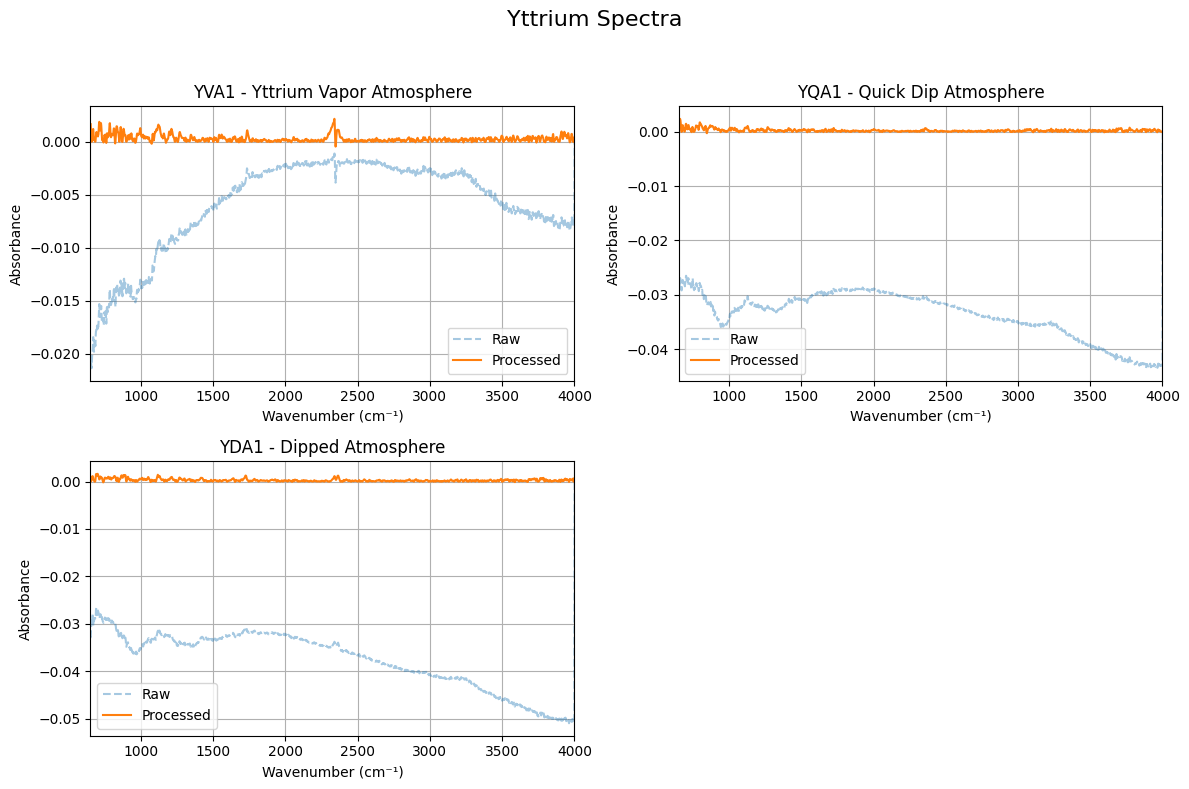

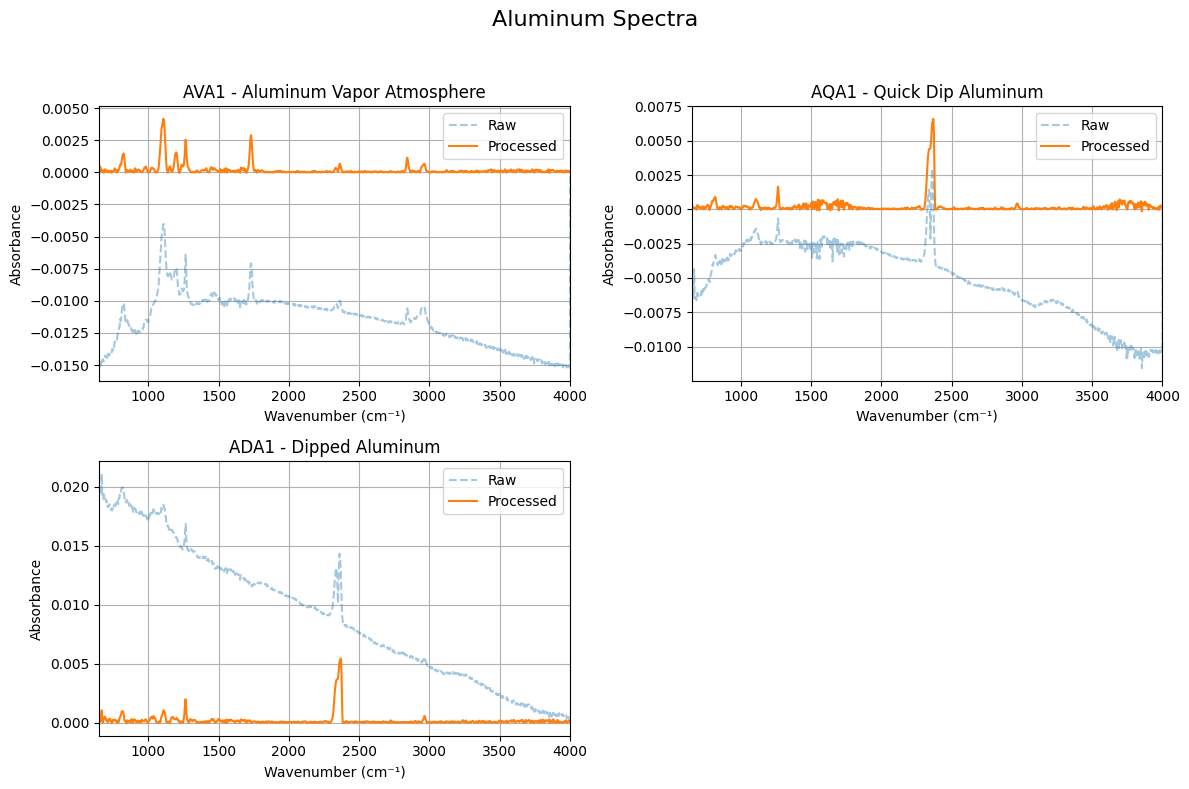

In [ ]:
#THIS IS THE CODE CHILD OF 6 DAYS OF TRIAL AND ERROR, IT IS BEAUTIFUL, THIS IS WHAT I WANT IN MY POSTER, Fuck YES!!!!!!!!!!!!!!!!!!!!!!!
#Vertical peak info
# Adjust prominence for Yttrium and Aluminum SubPlots
# I turned off the peaks feature for this one, because I just want to see the raw data and processed spectrums, the code above is strictly the processed data
#with the y axis set to 0, for visual clarity

import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.signal import find_peaks
from ramanspy.preprocessing import Pipeline
from ramanspy.preprocessing.baseline import ASLS, IASLS, IRSQR
from ramanspy.preprocessing.misc import Cropper
from ramanspy.preprocessing.denoise import SavGol
from ramanspy.preprocessing.despike import WhitakerHayes
from ramanspy import Spectrum
import ramanspy as rp

# Create Spectrum objects
specs = [
    Spectrum(file1[1], file1[0]),
    Spectrum(file2[1], file2[0]),
    Spectrum(file3[1], file3[0]),
    Spectrum(file4[1], file4[0]),
    Spectrum(file5[1], file5[0]),
    Spectrum(file6[1], file6[0])
]

labels = [
    "YVA1 - Yttrium Vapor Atmosphere",
    "YQA1 - Quick Dip Atmosphere",
    "YDA1 - Dipped Atmosphere",
    "AVA1 - Aluminum Vapor Atmosphere",
    "AQA1 - Quick Dip Aluminum",
    "ADA1 - Dipped Aluminum"
]

# Define pipeline
pipeline = Pipeline([
    Cropper(region=(650, 4000)),
    WhitakerHayes(),
    SavGol(window_length=7, polyorder=3),
    ASLS(),
    IASLS(),
    IRSQR()
])

# Apply to all
processed_specs = [pipeline.apply(spec) for spec in specs]

# Grouping
yttrium_specs = processed_specs[:3]
yttrium_raw = specs[:3]
yttrium_labels = labels[:3]

aluminum_specs = processed_specs[3:]
aluminum_raw = specs[3:]
aluminum_labels = labels[3:]
def plot_group(raw_group, proc_group, group_labels, title, prominence=0.002):
    n = len(raw_group)
    cols = 2
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 4))

    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else:
        axes = [axes]

    for i in range(rows * cols):
        if i >= n:
            axes[i].axis('off')
            continue

        ax = axes[i]

        # Plot raw
        ax.plot(raw_group[i].spectral_axis, raw_group[i].spectral_data, linestyle='--', alpha=0.4, label='Raw')

        # Plot processed
        ax.plot(proc_group[i].spectral_axis, proc_group[i].spectral_data, linewidth=1.5, label='Processed')

        # # Peak detection using scipy with adjustable prominence
        # y_data = proc_group[i].spectral_data
        # x_data = proc_group[i].spectral_axis
        # peaks, _ = find_peaks(y_data, prominence=prominence)

        # if len(peaks) > 0:
        #     peak_x = x_data[peaks]
        #     peak_y = y_data[peaks]
        #     ax.plot(peak_x, peak_y, 'rx', label='Peaks', markersize=6)

        #     # Annotate each peak with wavenumber
        #     for px, py in zip(peak_x, peak_y):
        #         ax.annotate(f"{int(px)}", xy=(px, py), xytext=(0, 5), textcoords="offset points",
        #                     fontsize=8, ha='center', rotation=90, color='red')

        ax.set_xlim(650, 4000)
        # ax.set_ylim(0, .01)
        ax.set_title(group_labels[i])
        ax.set_xlabel("Wavenumber (cm⁻¹)")
        ax.set_ylabel("Absorbance")
        ax.grid(True)
        ax.legend()

    plt.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

plot_group(yttrium_raw, yttrium_specs, yttrium_labels, "Yttrium Spectra", prominence=0.0015)
plot_group(aluminum_raw, aluminum_specs, aluminum_labels, "Aluminum Spectra", prominence=0.001)

Saved to: /content/drive/My Drive/Silane 04_16_2025/CSV Files/yttrium_raw+processed.png


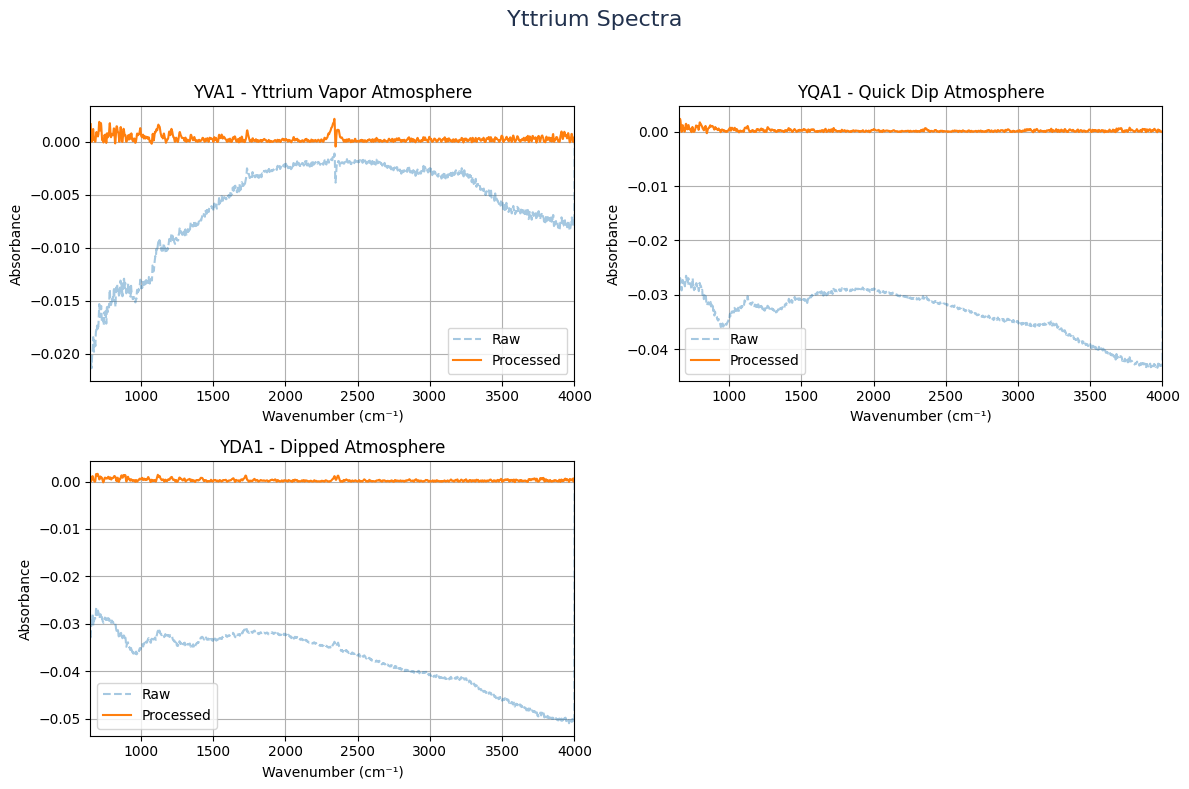

Saved to: /content/drive/My Drive/Silane 04_16_2025/CSV Files/aluminum_raw+processed.png


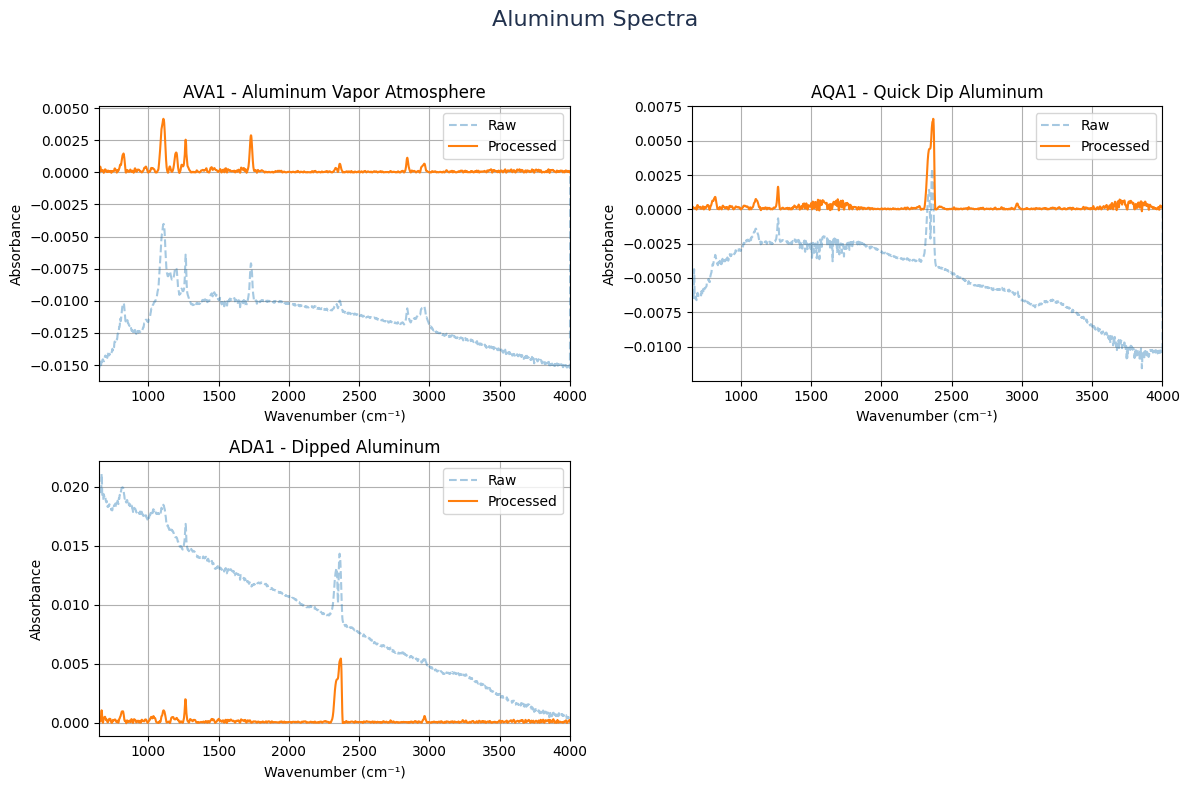

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.signal import find_peaks
from ramanspy.preprocessing import Pipeline
from ramanspy.preprocessing.baseline import ASLS, IASLS, IRSQR
from ramanspy.preprocessing.misc import Cropper
from ramanspy.preprocessing.denoise import SavGol
from ramanspy.preprocessing.despike import WhitakerHayes
from ramanspy import Spectrum
import ramanspy as rp
import os

# Save path
save_dir = '/content/drive/My Drive/Silane 04_16_2025/CSV Files/'
title_color = "#21314D"

# Create Spectrum objects
specs = [
    Spectrum(file1[1], file1[0]),
    Spectrum(file2[1], file2[0]),
    Spectrum(file3[1], file3[0]),
    Spectrum(file4[1], file4[0]),
    Spectrum(file5[1], file5[0]),
    Spectrum(file6[1], file6[0])
]

labels = [
    "YVA1 - Yttrium Vapor Atmosphere",
    "YQA1 - Quick Dip Atmosphere",
    "YDA1 - Dipped Atmosphere",
    "AVA1 - Aluminum Vapor Atmosphere",
    "AQA1 - Quick Dip Aluminum",
    "ADA1 - Dipped Aluminum"
]

# Define pipeline
pipeline = Pipeline([
    Cropper(region=(650, 4000)),
    WhitakerHayes(),
    SavGol(window_length=7, polyorder=3),
    ASLS(),
    IASLS(),
    IRSQR()
])

# Apply to all
processed_specs = [pipeline.apply(spec) for spec in specs]

# Grouping
yttrium_specs = processed_specs[:3]
yttrium_raw = specs[:3]
yttrium_labels = labels[:3]

aluminum_specs = processed_specs[3:]
aluminum_raw = specs[3:]
aluminum_labels = labels[3:]

def plot_group(raw_group, proc_group, group_labels, title, prominence=0.002, save_filename=None):
    n = len(raw_group)
    cols = 2
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 4))

    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else:
        axes = [axes]

    for i in range(rows * cols):
        if i >= n:
            axes[i].axis('off')
            continue

        ax = axes[i]

        ax.plot(raw_group[i].spectral_axis, raw_group[i].spectral_data, linestyle='--', alpha=0.4, label='Raw')
        ax.plot(proc_group[i].spectral_axis, proc_group[i].spectral_data, linewidth=1.5, label='Processed')

        ax.set_xlim(650, 4000)
        ax.set_title(group_labels[i])
        ax.set_xlabel("Wavenumber (cm⁻¹)")
        ax.set_ylabel("Absorbance")
        ax.grid(True)
        ax.legend()

    plt.suptitle(title, fontsize=16, color=title_color)
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    if save_filename:
        save_path = os.path.join(save_dir, save_filename)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved to: {save_path}")

    plt.show()

# Generate plots and save
plot_group(yttrium_raw, yttrium_specs, yttrium_labels, "Yttrium Spectra", prominence=0.0015, save_filename="yttrium_raw+processed.png")
plot_group(aluminum_raw, aluminum_specs, aluminum_labels, "Aluminum Spectra", prominence=0.001, save_filename="aluminum_raw+processed.png")


Saved to: /content/drive/My Drive/Silane 04_16_2025/CSV Files/yttrium_raw+processed.png


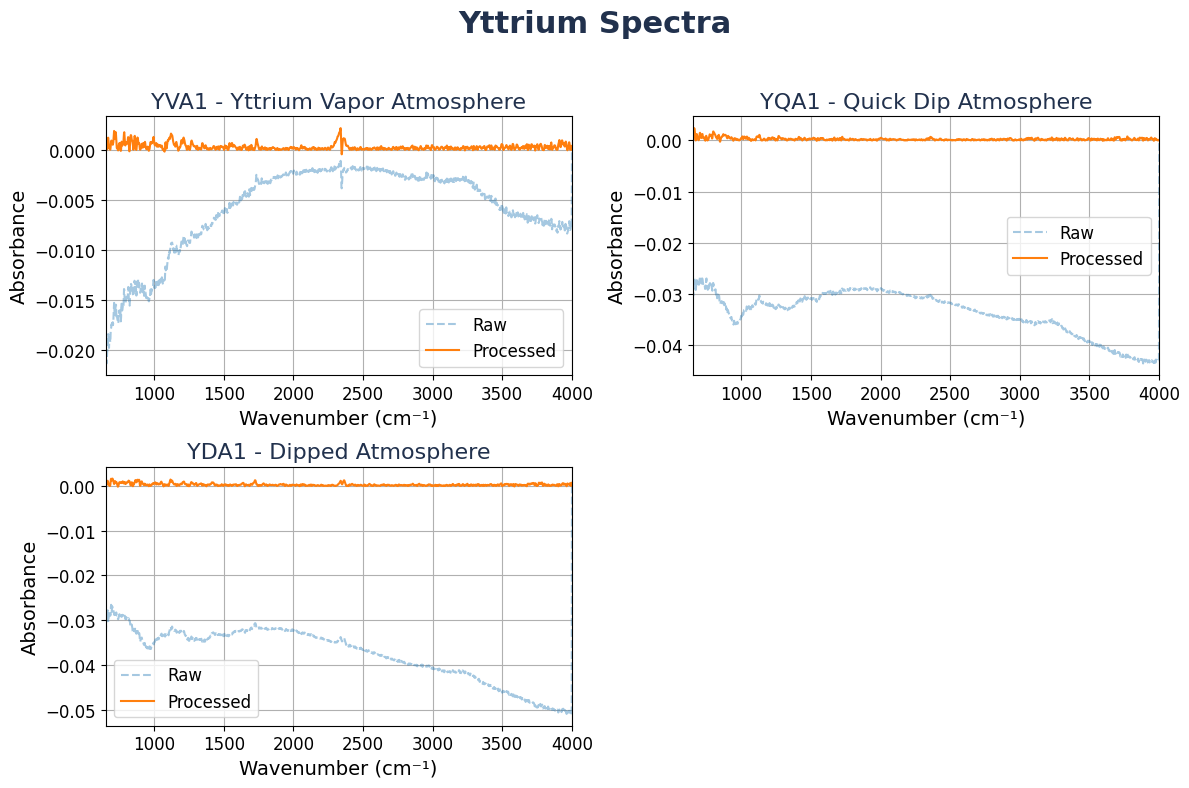

Saved to: /content/drive/My Drive/Silane 04_16_2025/CSV Files/aluminum_raw+processed.png


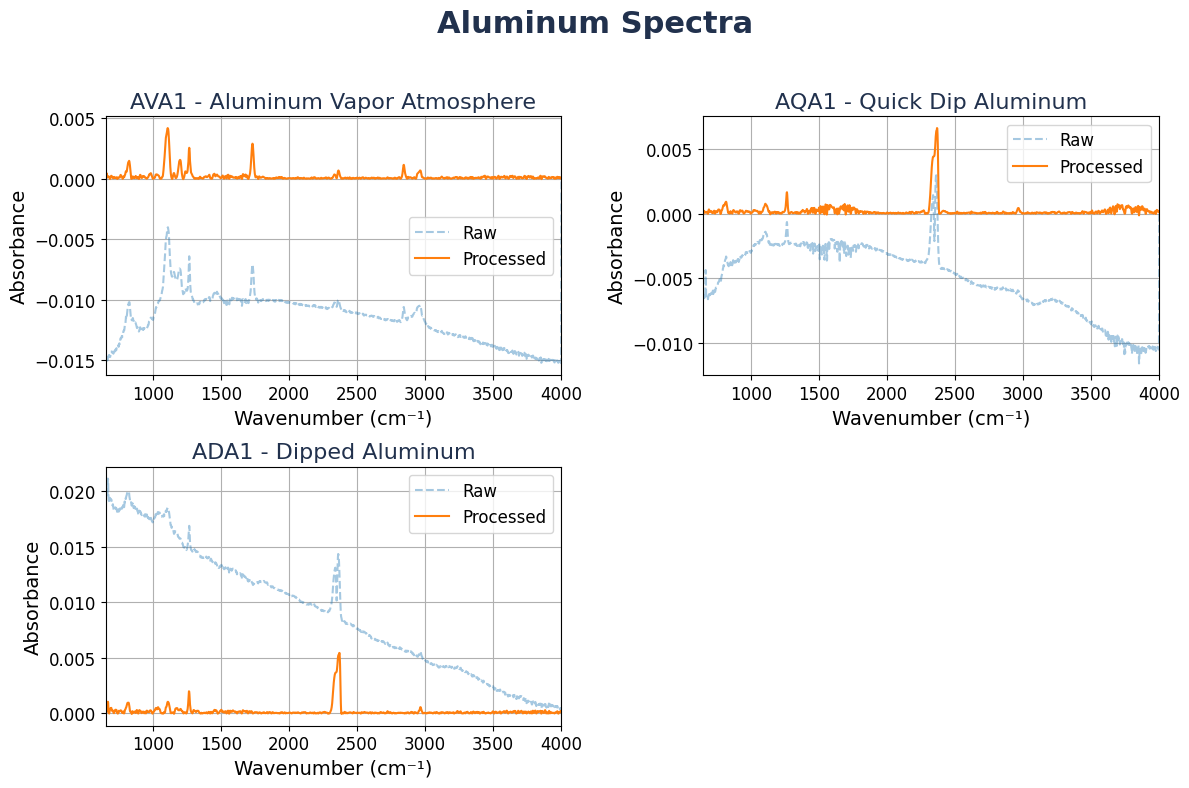

In [ ]:
def plot_group(raw_group, proc_group, group_labels, title, prominence=0.002, save_filename=None):
    n = len(raw_group)
    cols = 2
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 4))

    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else:
        axes = [axes]

    for i in range(rows * cols):
        if i >= n:
            axes[i].axis('off')
            continue

        ax = axes[i]

        ax.plot(raw_group[i].spectral_axis, raw_group[i].spectral_data, linestyle='--', alpha=0.4, label='Raw')
        ax.plot(proc_group[i].spectral_axis, proc_group[i].spectral_data, linewidth=1.5, label='Processed')

        ax.set_xlim(650, 4000)
        ax.set_title(group_labels[i], fontsize=16, color=title_color)
        ax.set_xlabel("Wavenumber (cm⁻¹)", fontsize=14)
        ax.set_ylabel("Absorbance", fontsize=14)
        ax.tick_params(axis='both', which='major', labelsize=12)
        ax.grid(True)
        ax.legend(fontsize=12)

    plt.suptitle(title, fontsize=22, color=title_color, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    if save_filename:
        save_path = os.path.join(save_dir, save_filename)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved to: {save_path}")

    plt.show()


# Generate plots and save
plot_group(yttrium_raw, yttrium_specs, yttrium_labels, "Yttrium Spectra", prominence=0.0015, save_filename="yttrium_raw+processed.png")
plot_group(aluminum_raw, aluminum_specs, aluminum_labels, "Aluminum Spectra", prominence=0.001, save_filename="aluminum_raw+processed.png")


<Axes: title={'center': 'Trial Collection ModPoly'}, xlabel='Wavenumber (cm^-1)', ylabel='Absorbtion [arb]'>

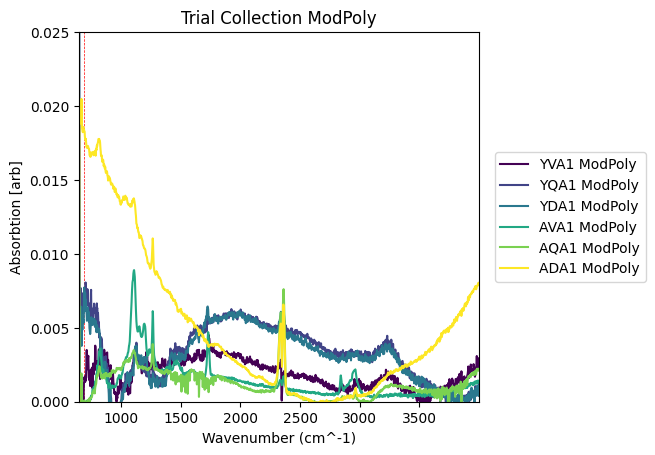

In [ ]:
plt.xlim(645, 3999)
plt.ylim(0, .025)

# Define the spectral region for cropping
# Assuming file1[1] contains wavenumbers, use min and max to ensure range is within data
spectral_range = (file1[1].min(),file1[0].max())

# Create a Cropper instance
cropper = Cropper(region=spectral_range)

data_flat_file1= data_ModPoly(file1[1], file1[0])
data_flat_file2= data_ModPoly(file2[1], file2[0])
data_flat_file3= data_ModPoly(file3[1], file3[0])
data_flat_file4= data_ModPoly(file4[1], file4[0])
data_flat_file5= data_ModPoly(file5[1], file5[0])
data_flat_file6= data_ModPoly(file6[1], file6[0])

data = [rp.Spectrum(data_flat_file1[0],data_flat_file1[1]),rp.Spectrum(data_flat_file2[0],data_flat_file2[1]),rp.Spectrum(data_flat_file3[0],data_flat_file3[1]),rp.Spectrum(data_flat_file4[0],data_flat_file4[1]),
        rp.Spectrum(data_flat_file5[0],data_flat_file5[1]), rp.Spectrum(data_flat_file6[0],data_flat_file6[1])]

# Apply the cropper to the baseline-corrected data
cropped_data_flat_file1 = cropper.apply(rp.Spectrum(data_flat_file1[1], data_flat_file1[0])) # Apply to baseline-corrected spectrum
cropped_data_flat_file2 = cropper.apply(rp.Spectrum(data_flat_file2[1], data_flat_file2[0]))
cropped_data_flat_file3 = cropper.apply(rp.Spectrum(data_flat_file3[1], data_flat_file3[0]))
cropped_data_flat_file4 = cropper.apply(rp.Spectrum(data_flat_file4[1], data_flat_file4[0]))
cropped_data_flat_file5 = cropper.apply(rp.Spectrum(data_flat_file5[1], data_flat_file5[0]))
cropped_data_flat_file6 = cropper.apply(rp.Spectrum(data_flat_file6[1], data_flat_file6[0]))

# Now, calculate data2 using the cropped data:
data2 = [dataspec1, rp.Spectrum(dataspec1.spectral_data, dataspec1.spectral_axis - cropped_data_flat_file1.spectral_axis),
         dataspec2, rp.Spectrum(dataspec2.spectral_data, dataspec2.spectral_axis - cropped_data_flat_file2.spectral_axis),
         dataspec3, rp.Spectrum(dataspec3.spectral_data, dataspec3.spectral_axis - cropped_data_flat_file3.spectral_axis),
         dataspec4, rp.Spectrum(dataspec4.spectral_data, dataspec4.spectral_axis - cropped_data_flat_file4.spectral_axis),
         dataspec5, rp.Spectrum(dataspec5.spectral_data, dataspec5.spectral_axis - cropped_data_flat_file5.spectral_axis),
         dataspec6, rp.Spectrum(dataspec6.spectral_data, dataspec6.spectral_axis - cropped_data_flat_file6.spectral_axis)]

plt.axvline(x=690, color='r', linestyle='--', linewidth=.5)
#"YVA1 Raw"
rp.plot.spectra(data,plot_type = 'single', label = ["YVA1 ModPoly","YQA1 ModPoly", "YDA1 ModPoly", "AVA1 ModPoly", "AQA1 ModPoly", "ADA1 ModPoly"],title="Trial Collection ModPoly", xlabel="Wavenumber (cm^-1)", ylabel="Absorbtion [arb]")

<Axes: title={'center': 'Trial Collection ModPoly'}, xlabel='Wavenumber (cm^-1)', ylabel='Absorbtion [arb]'>

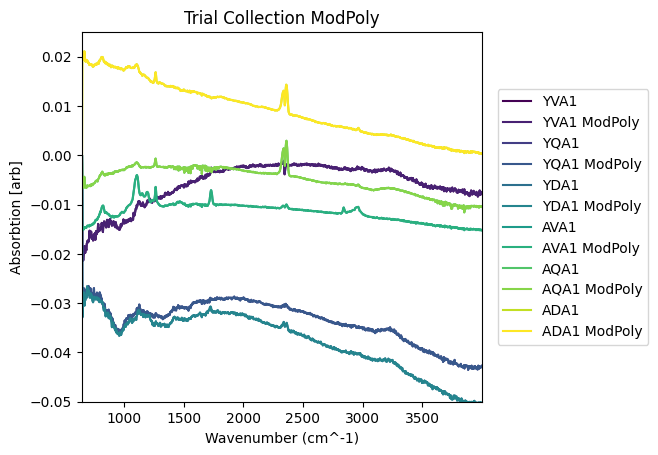

In [ ]:
plt.xlim(645, 3999)
plt.ylim(-0.05, .025)
rp.plot.spectra(data2, plot_type='single', label = ["YVA1", "YVA1 ModPoly","YQA1", "YQA1 ModPoly","YDA1", "YDA1 ModPoly", "AVA1", "AVA1 ModPoly", "AQA1", "AQA1 ModPoly", "ADA1", "ADA1 ModPoly"],title="Trial Collection ModPoly", xlabel="Wavenumber (cm^-1)", ylabel="Absorbtion [arb]")
# "YVA1", "YVA1 AISLS","YQA1", "YQA1 AISLS","YDA1", "YDA1 AISLS", "AVA1", "AVA1 AISLS", "AQA1", "AQA1 AISLS", "ADA1", "ADA1 AISLS"

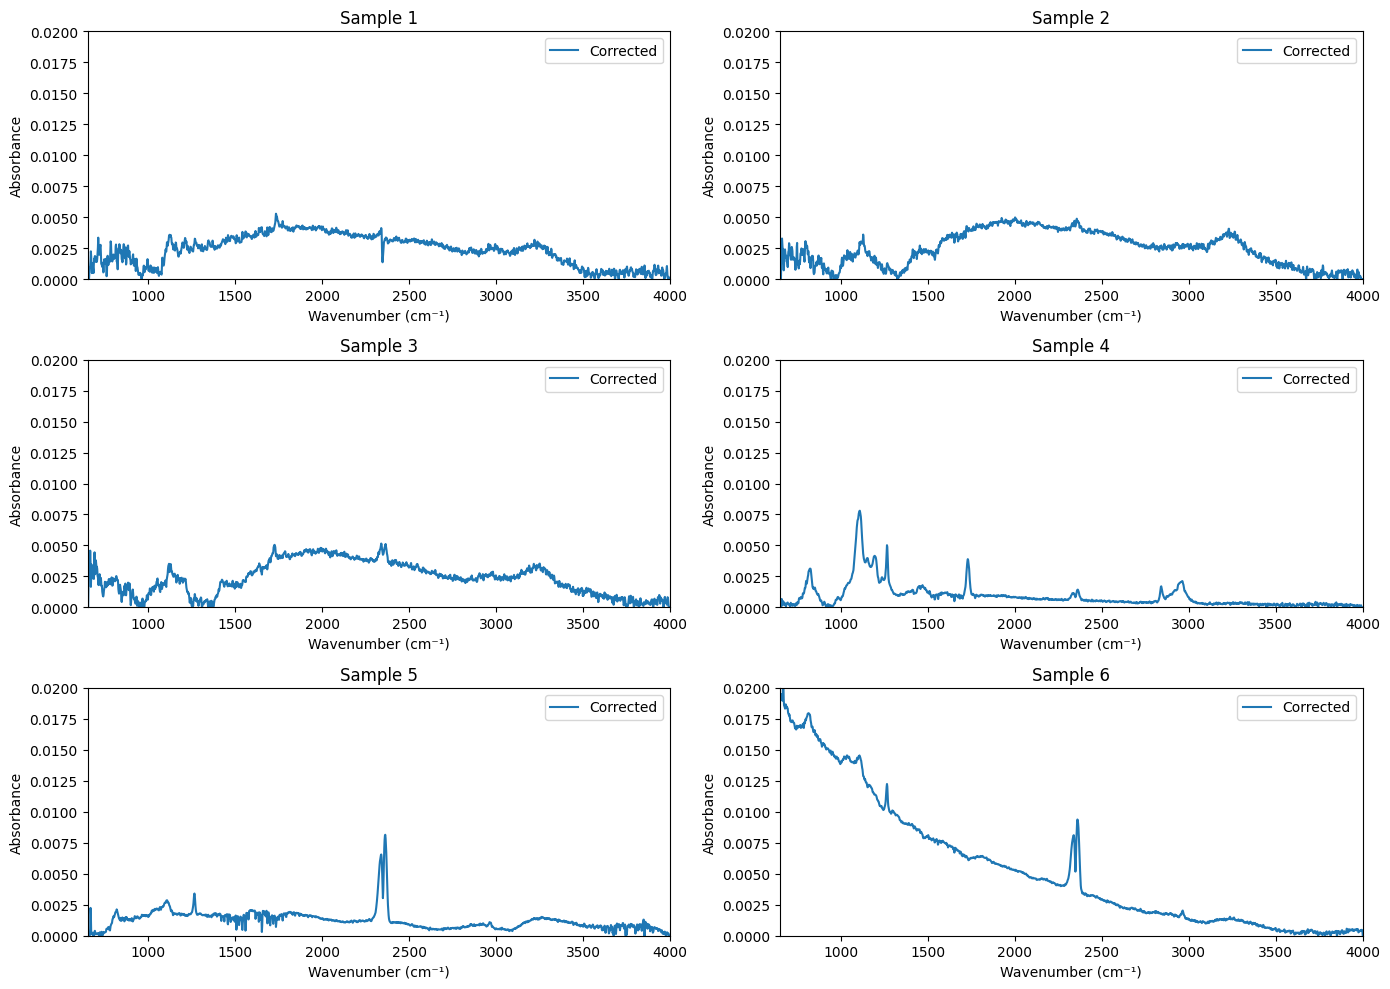

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pybaselines import Baseline

# Create a Baseline object
baseline_fitter = Baseline()

# Load all files into a list of DataFrames
files = [
    pd.read_csv('/content/drive/My Drive/Silane 04_16_2025/CSV Files/01_YVA1_04_08_2025_CompanySilane_RAW.CSV', names=['wavenumber', 'absorbance']),
    pd.read_csv('/content/drive/My Drive/Silane 04_16_2025/CSV Files/07_YQA1_04_08_2025_CompanySilane_RAW.CSV', names=['wavenumber', 'absorbance']),
    pd.read_csv('/content/drive/My Drive/Silane 04_16_2025/CSV Files/13_YDA1_04_08_2025_CompanySilane_RAW.CSV', names=['wavenumber', 'absorbance']),
    pd.read_csv('/content/drive/My Drive/Silane 04_16_2025/CSV Files/19_AVA1_04_08_2025_CompanySilane_RAW.CSV', names=['wavenumber', 'absorbance']),
    pd.read_csv('/content/drive/My Drive/Silane 04_16_2025/CSV Files/25_AQA1_04_08_2025_CompanySilane_RAW.CSV', names=['wavenumber', 'absorbance']),
    pd.read_csv('/content/drive/My Drive/Silane 04_16_2025/CSV Files/31_ADA1_04_08_2025_CompanySilane_RAW.CSV', names=['wavenumber', 'absorbance'])
]

# Prepare subplot grid
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

# Loop through each file and process
for idx, (df, ax) in enumerate(zip(files, axes), 1):
    x = df['wavenumber'].values
    y = df['absorbance'].values

    # Apply peak_filling from Baseline class
    baseline, _ = baseline_fitter.peak_filling(y,half_window=None, sections=None, max_iter=5, lam_smooth=None)
    corrected = y - baseline

    # Plot
    # ax.plot(x, y, label='Original', alpha=0.75)
    # ax.plot(x, baseline, label='Baseline', linestyle='--')
    ax.plot(x, corrected, label='Corrected', linewidth=1.5)
    ax.set_title(f'Sample {idx}')
    ax.set_xlabel('Wavenumber (cm⁻¹)')
    ax.set_ylabel('Absorbance')
    # ax.invert_xaxis()
    ax.set_xlim(650, 4000)
    ax.set_ylim(0, .02)

    ax.legend()

plt.tight_layout()
plt.show()



In [ ]:
# from pybaselines import smooth, polynomial, spline, whittaker, morphological

# file1 = pd.read_csv('/content/drive/My Drive/Silane 04_16_2025/CSV Files/01_YVA1_04_08_2025_CompanySilane_RAW.CSV', names=['wavenumber', 'absorbance'])
# file2 = pd.read_csv('/content/drive/My Drive/Silane 04_16_2025/CSV Files/07_YQA1_04_08_2025_CompanySilane_RAW.CSV', names=['wavenumber', 'absorbance'])
# file3 = pd.read_csv('/content/drive/My Drive/Silane 04_16_2025/CSV Files/13_YDA1_04_08_2025_CompanySilane_RAW.CSV', names=['wavenumber', 'absorbance'])
# file4 = pd.read_csv('/content/drive/My Drive/Silane 04_16_2025/CSV Files/19_AVA1_04_08_2025_CompanySilane_RAW.CSV', names=['wavenumber', 'absorbance'])
# file5 = pd.read_csv('/content/drive/My Drive/Silane 04_16_2025/CSV Files/25_AQA1_04_08_2025_CompanySilane_RAW.CSV', names=['wavenumber', 'absorbance'])
# file6 = pd.read_csv('/content/drive/My Drive/Silane 04_16_2025/CSV Files/31_ADA1_04_08_2025_CompanySilane_RAW.CSV', names=['wavenumber', 'absorbance'])


# x = file1['wavenumber'].values
# y = file1['absorbance'].values

# x2 = file1['wavenumber'].values
# y2 = file1['absorbance'].values

# x3 = file1['wavenumber'].values
# y3 = file1['absorbance'].values

# x4 = file1['wavenumber'].values
# y4 = file1['absorbance'].values

# x5 = file1['wavenumber'].values
# y5 = file1['absorbance'].values

# x6 = file1['wavenumber'].values
# y6 = file1['absorbance'].values

In [ ]:
# # Initialize the morphological object
# morph = morphological.Morphological()

# # Apply the peak_filling method
# baseline, params = morph.peak_filling(y)

# # Subtract baseline to get the corrected signal
# corrected = y - baseline

# # Initialize the morphological object
# morph2 = morphological.Morphological()

# # Apply the peak_filling method
# baseline2, params2 = morph2.peak_filling(y2)

# # Subtract baseline to get the corrected signal
# corrected2 = y2 - baseline2

# # Initialize the morphological object
# morph3 = morphological.Morphological()

# # Apply the peak_filling method
# baseline3, params3 = morph3.peak_filling(y3)

# # Subtract baseline to get the corrected signal
# corrected3 = y3 - baseline3

# # Initialize the morphological object
# morph4 = morphological.Morphological()

# # Apply the peak_filling method
# baseline4, params4 = morph.peak_filling(y4)

# # Subtract baseline to get the corrected signal
# corrected4 = y4 - baseline4

# # Initialize the morphological object
# morph5 = morphological.Morphological()

# # Apply the peak_filling method
# baseline5, params5 = morph5.peak_filling(y5)

# # Subtract baseline to get the corrected signal
# corrected5 = y5 - baseline5

# # Initialize the morphological object
# morph6 = morphological.Morphological()

# # Apply the peak_filling method
# baseline6, params6 = morph6.peak_filling(y6)

# # Subtract baseline to get the corrected signal
# corrected6 = y6 - baseline6

<Axes: title={'center': 'Raman spectra'}, xlabel='Wavenumber (cm^-1)', ylabel='Absorbance [arb]'>

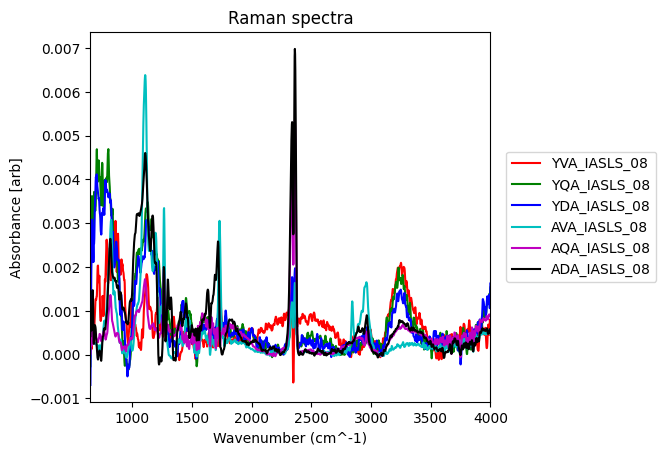

In [ ]:
YVA1_raw_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/01_YVA1_04_08_2025_CompanySilane_RAW.SPA')
YVA1_bls_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/01_YVA1_04_08_2025_CompanySilane_BLS.SPA')
YVA2_raw_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/02_YVA2_04_08_2025_CompanySilane_RAW.SPA')
YVA2_bls_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/02_YVA2_04_08_2025_CompanySilane_BLS.SPA')
YVA3_raw_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/03_YVA3_04_08_2025_CompanySilane_RAW.SPA')
YVA3_bls_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/03_YVA3_04_08_2025_CompanySilane_BLS.SPA')

YVN1_raw_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/04_YVN1_04_08_2025_CompanySilane_RAW.SPA')
YVN1_bls_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/04_YVN1_04_08_2025_CompanySilane_BLS.SPA')
YVN2_raw_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/05_YVN2_04_08_2025_CompanySilane_RAW.SPA')
YVN2_bls_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/05_YVN2_04_08_2025_CompanySilane_BLS.SPA')
YVN3_raw_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/06_YVN3_04_08_2025_CompanySilane_RAW.SPA')
YVN3_bls_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/06_YVN3_04_08_2025_CompanySilane_BLS.SPA')

YQA1_raw_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/07_YQA1_04_08_2025_CompanySilane_RAW.SPA')
YQA1_bls_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/07_YQA1_04_08_2025_CompanySilane_BLS.SPA')
YQA2_raw_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/08_YQA2_04_08_2025_CompanySilane_RAW.SPA')
YQA2_bls_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/08_YQA2_04_08_2025_CompanySilane_BLS.SPA')
YQA3_raw_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/09_YQA3_04_08_2025_CompanySilane_RAW.SPA')
YQA3_bls_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/09_YQA3_04_08_2025_CompanySilane_BLS.SPA')

YQN1_raw_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/10_YQN1_04_08_2025_CompanySilane_RAW.SPA')
YQN1_bls_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/10_YQN1_04_08_2025_CompanySilane_BLS.SPA')
YQN2_raw_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/11_YQN2_04_08_2025_CompanySilane_RAW.SPA')
YQN2_bls_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/11_YQN2_04_08_2025_CompanySilane_BLS.SPA')
YQN3_raw_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/12_YQN3_04_08_2025_CompanySilane_RAW.SPA')
YQN3_bls_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/12_YQN3_04_08_2025_CompanySilane_BLS.SPA')

YDA1_raw_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/13_YDA1_04_08_2025_CompanySilane_RAW.SPA')
YDA1_bls_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/13_YDA1_04_08_2025_CompanySilane_BLS.SPA')
YDA2_raw_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/14_YDA2_04_08_2025_CompanySilane_RAW.SPA')
YDA2_bls_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/14_YDA2_04_08_2025_CompanySilane_BLS.SPA')
YDA3_raw_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/15_YDA3_04_08_2025_CompanySilane_RAW.SPA')
YDA3_bls_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/15_YDA3_04_08_2025_CompanySilane_BLS.SPA')

YDN1_raw_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/16_YDN1_04_08_2025_CompanySilane_RAW.SPA')
YDN1_bls_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/16_YDN1_04_08_2025_CompanySilane_BLS.SPA')
YDN2_raw_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/17_YDN2_04_08_2025_CompanySilane_RAW.SPA')
YDN2_bls_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/17_YDN2_04_08_2025_CompanySilane_BLS.SPA')
YDN3_raw_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/18_YDN3_04_08_2025_CompanySilane_RAW.SPA')
YDN3_bls_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/18_YDN3_04_08_2025_CompanySilane_BLS.SPA')

AVA1_raw_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/19_AVA1_04_08_2025_CompanySilane_RAW.SPA')
AVA1_bls_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/19_AVA1_04_08_2025_CompanySilane_BLS.SPA')
AVA2_raw_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/20_AVA2_04_08_2025_CompanySilane_RAW.SPA')
AVA2_bls_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/20_AVA2_04_08_2025_CompanySilane_BLS.SPA')
AVA3_raw_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/21_AVA3_04_08_2025_CompanySilane_RAW.SPA')
AVA3_bls_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/21_AVA3_04_08_2025_CompanySilane_BLS.SPA')

AVN1_raw_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/22_AVN1_04_08_2025_CompanySilane_RAW.SPA')
AVN1_bls_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/22_AVN1_04_08_2025_CompanySilane_BLS.SPA')
AVN2_raw_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/23_AVN2_04_08_2025_CompanySilane_RAW.SPA')
AVN2_bls_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/23_AVN2_04_08_2025_CompanySilane_BLS.SPA')
AVN3_raw_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/24_AVN3_04_08_2025_CompanySilane_RAW.SPA')
AVN3_bls_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/24_AVN3_04_08_2025_CompanySilane_BLS.SPA')

AQA1_raw_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/25_AQA1_04_08_2025_CompanySilane_RAW.SPA')
AQA1_bls_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/25_AQA1_04_08_2025_CompanySilane_BLS.SPA')
AQA2_raw_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/26_AQA2_04_08_2025_CompanySilane_RAW.SPA')
AQA2_bls_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/26_AQA2_04_08_2025_CompanySilane_BLS.SPA')
AQA3_raw_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/27_AQA3_04_08_2025_CompanySilane_RAW.SPA')
AQA3_bls_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/27_AQA3_04_08_2025_CompanySilane_BLS.SPA')

AQN1_raw_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/28_AQN1_04_08_2025_CompanySilane_RAW.SPA')
AQN1_bls_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/28_AQN1_04_08_2025_CompanySilane_BLS.SPA')
AQN2_raw_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/29_AQN2_04_08_2025_CompanySilane_RAW.SPA')
AQN2_bls_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/29_AQN2_04_08_2025_CompanySilane_BLS.SPA')
AQN3_raw_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/30_AQN3_04_08_2025_CompanySilane_RAW.SPA')
AQN3_bls_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/30_AQN3_04_08_2025_CompanySilane_BLS.SPA')

ADA1_raw_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/31_ADA1_04_08_2025_CompanySilane_RAW.SPA')
ADA1_bls_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/31_ADA1_04_08_2025_CompanySilane_BLS.SPA')
ADA2_raw_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/32_ADA2_04_08_2025_CompanySilane_RAW.SPA')
ADA2_bls_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/32_ADA2_04_08_2025_CompanySilane_BLS.SPA')
ADA3_raw_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/33_ADA3_04_08_2025_CompanySilane_RAW.SPA')
ADA3_bls_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/33_ADA3_04_08_2025_CompanySilane_BLS.SPA')

ADN1_raw_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/34_ADN1_04_08_2025_CompanySilane_RAW.SPA')
ADN1_bls_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/34_ADN1_04_08_2025_CompanySilane_BLS.SPA')
ADN2_raw_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/35_ADN2_04_08_2025_CompanySilane_RAW.SPA')
ADN2_bls_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/35_ADN2_04_08_2025_CompanySilane_BLS.SPA')
ADN3_raw_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/36_ADN3_04_08_2025_CompanySilane_RAW.SPA')
ADN3_bls_08 = read_spa('/content/drive/My Drive/Silane 04_16_2025/36_ADN3_04_08_2025_CompanySilane_BLS.SPA')
#######################################################################################################################################################
YDA1_raw_10 = read_spa('/content/drive/My Drive/Silane 04_16_2025/13_YDA1_04_10_2025_CompanySilane_RAW.SPA')
YDA1_bls_10 = read_spa('/content/drive/My Drive/Silane 04_16_2025/13_YDA1_04_10_2025_CompanySilane_BLS.SPA')
YDA2_raw_10 = read_spa('/content/drive/My Drive/Silane 04_16_2025/14_YDA2_04_10_2025_CompanySilane_RAW.SPA')
YDA2_bls_10 = read_spa('/content/drive/My Drive/Silane 04_16_2025/14_YDA2_04_10_2025_CompanySilane_BLS.SPA')
YDA3_raw_10 = read_spa('/content/drive/My Drive/Silane 04_16_2025/15_YDA3_04_10_2025_CompanySilane_RAW.SPA')
YDA3_bls_10 = read_spa('/content/drive/My Drive/Silane 04_16_2025/15_YDA3_04_10_2025_CompanySilane_BLS.SPA')

YDN1_raw_10 = read_spa('/content/drive/My Drive/Silane 04_16_2025/16_YDN1_04_10_2025_CompanySilane_RAW.SPA')
YDN1_bls_10 = read_spa('/content/drive/My Drive/Silane 04_16_2025/16_YDN1_04_10_2025_CompanySilane_BLS.SPA')
YDN2_raw_10 = read_spa('/content/drive/My Drive/Silane 04_16_2025/17_YDN2_04_10_2025_CompanySilane_RAW.SPA')
YDN2_bls_10 = read_spa('/content/drive/My Drive/Silane 04_16_2025/17_YDN2_04_10_2025_CompanySilane_BLS.SPA')
YDN3_raw_10 = read_spa('/content/drive/My Drive/Silane 04_16_2025/18_YDN3_04_10_2025_CompanySilane_RAW.SPA')
YDN3_bls_10 = read_spa('/content/drive/My Drive/Silane 04_16_2025/18_YDN3_04_10_2025_CompanySilane_BLS.SPA')

ADA1_raw_10 = read_spa('/content/drive/My Drive/Silane 04_16_2025/31_ADA1_04_10_2025_CompanySilane_RAW.SPA')
ADA1_bls_10 = read_spa('/content/drive/My Drive/Silane 04_16_2025/31_ADA1_04_10_2025_CompanySilane_BLS.SPA')
ADA2_raw_10 = read_spa('/content/drive/My Drive/Silane 04_16_2025/32_ADA2_04_10_2025_CompanySilane_RAW.SPA')
ADA2_bls_10 = read_spa('/content/drive/My Drive/Silane 04_16_2025/32_ADA2_04_10_2025_CompanySilane_BLS.SPA')
ADA3_raw_10 = read_spa('/content/drive/My Drive/Silane 04_16_2025/33_ADA3_04_10_2025_CompanySilane_RAW.SPA')
ADA3_bls_10 = read_spa('/content/drive/My Drive/Silane 04_16_2025/33_ADA3_04_10_2025_CompanySilane_BLS.SPA')

ADN1_raw_10 = read_spa('/content/drive/My Drive/Silane 04_16_2025/34_ADN1_04_10_2025_CompanySilane_RAW.SPA')
ADN1_bls_10 = read_spa('/content/drive/My Drive/Silane 04_16_2025/34_ADN1_04_10_2025_CompanySilane_BLS.SPA')
ADN2_raw_10 = read_spa('/content/drive/My Drive/Silane 04_16_2025/35_ADN2_04_10_2025_CompanySilane_RAW.SPA')
ADN2_bls_10 = read_spa('/content/drive/My Drive/Silane 04_16_2025/35_ADN2_04_10_2025_CompanySilane_BLS.SPA')
ADN3_raw_10 = read_spa('/content/drive/My Drive/Silane 04_16_2025/36_ADN3_04_10_2025_CompanySilane_RAW.SPA')
ADN3_bls_10 = read_spa('/content/drive/My Drive/Silane 04_16_2025/36_ADN3_04_10_2025_CompanySilane_BLS.SPA')
#######################################################################################################################################################
YVA1_raw_16 = read_spa('/content/drive/My Drive/Silane 04_16_2025/01_YVA1_04_16_2025_CompanySilane_RAW.SPA')
YVA1_bls_16 = read_spa('/content/drive/My Drive/Silane 04_16_2025/01_YVA1_04_16_2025_CompanySilane_BLS.SPA')
YVA2_raw_16 = read_spa('/content/drive/My Drive/Silane 04_16_2025/02_YVA2_04_16_2025_CompanySilane_RAW.SPA')
YVA2_bls_16 = read_spa('/content/drive/My Drive/Silane 04_16_2025/02_YVA2_04_16_2025_CompanySilane_BLS.SPA')
YVA3_raw_16 = read_spa('/content/drive/My Drive/Silane 04_16_2025/03_YVA3_04_16_2025_CompanySilane_RAW.SPA')
YVA3_bls_16 = read_spa('/content/drive/My Drive/Silane 04_16_2025/03_YVA3_04_16_2025_CompanySilane_BLS.SPA')

YVN1_raw_16 = read_spa('/content/drive/My Drive/Silane 04_16_2025/04_YVN1_04_16_2025_CompanySilane_RAW.SPA')
YVN1_bls_16 = read_spa('/content/drive/My Drive/Silane 04_16_2025/04_YVN1_04_16_2025_CompanySilane_BLS.SPA')
YVN2_raw_16 = read_spa('/content/drive/My Drive/Silane 04_16_2025/05_YVN2_04_16_2025_CompanySilane_RAW.SPA')
YVN2_bls_16 = read_spa('/content/drive/My Drive/Silane 04_16_2025/05_YVN2_04_16_2025_CompanySilane_BLS.SPA')
YVN3_raw_16 = read_spa('/content/drive/My Drive/Silane 04_16_2025/06_YVN3_04_16_2025_CompanySilane_RAW.SPA')
YVN3_bls_16 = read_spa('/content/drive/My Drive/Silane 04_16_2025/06_YVN3_04_16_2025_CompanySilane_BLS.SPA')

YQA1_raw_16 = read_spa('/content/drive/My Drive/Silane 04_16_2025/07_YQA1_04_16_2025_CompanySilane_RAW.SPA')
YQA1_bls_16 = read_spa('/content/drive/My Drive/Silane 04_16_2025/07_YQA1_04_16_2025_CompanySilane_BLS.SPA')
YQA2_raw_16 = read_spa('/content/drive/My Drive/Silane 04_16_2025/08_YQA2_04_16_2025_CompanySilane_RAW.SPA')
YQA2_bls_16 = read_spa('/content/drive/My Drive/Silane 04_16_2025/08_YQA2_04_16_2025_CompanySilane_BLS.SPA')
YQA3_raw_16 = read_spa('/content/drive/My Drive/Silane 04_16_2025/09_YQA3_04_16_2025_CompanySilane_RAW.SPA')
YQA3_bls_16 = read_spa('/content/drive/My Drive/Silane 04_16_2025/09_YQA3_04_16_2025_CompanySilane_BLS.SPA')

YQN1_raw_16 = read_spa('/content/drive/My Drive/Silane 04_16_2025/10_YQN1_04_16_2025_CompanySilane_RAW.SPA')
YQN1_bls_16 = read_spa('/content/drive/My Drive/Silane 04_16_2025/10_YQN1_04_16_2025_CompanySilane_BLS.SPA')
YQN2_raw_16 = read_spa('/content/drive/My Drive/Silane 04_16_2025/11_YQN2_04_16_2025_CompanySilane_RAW.SPA')
YQN2_bls_16 = read_spa('/content/drive/My Drive/Silane 04_16_2025/11_YQN2_04_16_2025_CompanySilane_BLS.SPA')
YQN3_raw_16 = read_spa('/content/drive/My Drive/Silane 04_16_2025/12_YQN3_04_16_2025_CompanySilane_RAW.SPA')
YQN3_bls_16 = read_spa('/content/drive/My Drive/Silane 04_16_2025/12_YQN3_04_16_2025_CompanySilane_BLS.SPA')

YDA1_raw_16 = read_spa('/content/drive/My Drive/Silane 04_16_2025/13_YDA1_04_16_2025_CompanySilane_RAW.SPA')
YDA1_bls_16 = read_spa('/content/drive/My Drive/Silane 04_16_2025/13_YDA1_04_16_2025_CompanySilane_BLS.SPA')
YDA2_raw_16 = read_spa('/content/drive/My Drive/Silane 04_16_2025/14_YDA2_04_16_2025_CompanySilane_RAW.SPA')
YDA2_bls_16 = read_spa('/content/drive/My Drive/Silane 04_16_2025/14_YDA2_04_16_2025_CompanySilane_BLS.SPA')
YDA3_raw_16 = read_spa('/content/drive/My Drive/Silane 04_16_2025/15_YDA3_04_16_2025_CompanySilane_RAW.SPA')
YDA3_bls_16 = read_spa('/content/drive/My Drive/Silane 04_16_2025/15_YDA3_04_16_2025_CompanySilane_BLS.SPA')

YDN1_raw_16 = read_spa('/content/drive/My Drive/Silane 04_16_2025/16_YDN1_04_16_2025_CompanySilane_RAW.SPA')
YDN1_bls_16 = read_spa('/content/drive/My Drive/Silane 04_16_2025/16_YDN1_04_16_2025_CompanySilane_BLS.SPA')
YDN2_raw_16 = read_spa('/content/drive/My Drive/Silane 04_16_2025/17_YDN2_04_16_2025_CompanySilane_RAW.SPA')
YDN2_bls_16 = read_spa('/content/drive/My Drive/Silane 04_16_2025/17_YDN2_04_16_2025_CompanySilane_BLS.SPA')
YDN3_raw_16 = read_spa('/content/drive/My Drive/Silane 04_16_2025/18_YDN3_04_16_2025_CompanySilane_RAW.SPA')
YDN3_bls_16 = read_spa('/content/drive/My Drive/Silane 04_16_2025/18_YDN3_04_16_2025_CompanySilane_BLS.SPA')

ADA1_raw_16 = read_spa('/content/drive/My Drive/Silane 04_16_2025/31_ADA1_04_16_2025_CompanySilane_RAW.SPA')
ADA1_bls_16 = read_spa('/content/drive/My Drive/Silane 04_16_2025/31_ADA1_04_16_2025_CompanySilane_BLS.SPA')
ADA2_raw_16 = read_spa('/content/drive/My Drive/Silane 04_16_2025/32_ADA2_04_16_2025_CompanySilane_RAW.SPA')
ADA2_bls_16 = read_spa('/content/drive/My Drive/Silane 04_16_2025/32_ADA2_04_16_2025_CompanySilane_BLS.SPA')
ADA3_raw_16 = read_spa('/content/drive/My Drive/Silane 04_16_2025/33_ADA3_04_16_2025_CompanySilane_RAW.SPA')
ADA3_bls_16 = read_spa('/content/drive/My Drive/Silane 04_16_2025/33_ADA3_04_16_2025_CompanySilane_BLS.SPA')

ADN1_raw_16 = read_spa('/content/drive/My Drive/Silane 04_16_2025/34_ADN1_04_16_2025_CompanySilane_RAW.SPA')
ADN1_bls_16 = read_spa('/content/drive/My Drive/Silane 04_16_2025/34_ADN1_04_16_2025_CompanySilane_BLS.SPA')
ADN2_raw_16 = read_spa('/content/drive/My Drive/Silane 04_16_2025/35_ADN2_04_16_2025_CompanySilane_RAW.SPA')
ADN2_bls_16 = read_spa('/content/drive/My Drive/Silane 04_16_2025/35_ADN2_04_16_2025_CompanySilane_BLS.SPA')
ADN3_raw_16 = read_spa('/content/drive/My Drive/Silane 04_16_2025/36_ADN3_04_16_2025_CompanySilane_RAW.SPA')
ADN3_bls_16 = read_spa('/content/drive/My Drive/Silane 04_16_2025/36_ADN3_04_16_2025_CompanySilane_BLS.SPA')
#########################################################################################################################################################
YVA_raw_08 = [YVA1_raw_08,YVA2_raw_08,YVA3_raw_08]
YVA_bls_08 = [YVA1_bls_08,YVA2_bls_08,YVA3_bls_08]
YVN_raw_08 = [YVN1_raw_08,YVN2_raw_08,YVN3_raw_08]
YVN_bls_08 = [YVN1_bls_08,YVN2_bls_08,YVN3_bls_08]

YQA_raw_08 = [YQA1_raw_08,YQA2_raw_08,YQA3_raw_08]
YQA_bls_08 = [YQA1_bls_08,YQA2_bls_08,YQA3_bls_08]
YQN_raw_08 = [YQN1_raw_08,YQN2_raw_08,YQN3_raw_08]
YQN_bls_08 = [YQN1_bls_08,YQN2_bls_08,YQN3_bls_08]

YDA_raw_08 = [YDA1_raw_08,YDA2_raw_08,YDA3_raw_08]
YDA_bls_08 = [YDA1_bls_08,YDA2_bls_08,YDA3_bls_08]
YDN_raw_08 = [YDN1_raw_08,YDN2_raw_08,YDN3_raw_08]
YDN_bls_08 = [YDN1_bls_08,YDN2_bls_08,YDN3_bls_08]

AVA_raw_08 = [AVA1_raw_08,AVA2_raw_08,AVA3_raw_08]
AVA_bls_08 = [AVA1_bls_08,AVA2_bls_08,AVA3_bls_08]
AVN_raw_08 = [AVN1_raw_08,YVN2_raw_08,AVN3_raw_08]
AVN_bls_08 = [AVN1_bls_08,YVN2_bls_08,AVN3_bls_08]

AQA_raw_08 = [AQA1_raw_08,AQA2_raw_08,AQA3_raw_08]
AQA_bls_08 = [AQA1_bls_08,AQA2_bls_08,AQA3_bls_08]
AQN_raw_08 = [AQN1_raw_08,AQN2_raw_08,AQN3_raw_08]
AQN_bls_08 = [AQN1_bls_08,AQN2_bls_08,AQN3_bls_08]

ADA_raw_08 = [ADA1_raw_08,ADA2_raw_08,ADA3_raw_08]
ADA_bls_08 = [ADA1_bls_08,ADA2_bls_08,ADA3_bls_08]
ADN_raw_08 = [ADN1_raw_08,ADN2_raw_08,ADN3_raw_08]
ADN_bls_08 = [ADN1_bls_08,ADN2_bls_08,ADN3_bls_08]

YDA_raw_10 = [YDA1_raw_10,YDA2_raw_10,YDA3_raw_10]
YDA_bls_10 = [YDA1_bls_10,YDA2_bls_10,YDA3_bls_10]
YDN_raw_10 = [YDN1_raw_10,YDN2_raw_10,YDN3_raw_10]
YDN_bls_10 = [YDN1_bls_10,YDN2_bls_10,YDN3_bls_10]

ADA_raw_10 = [ADA1_raw_10,ADA2_raw_10,ADA3_raw_10]
ADA_bls_10 = [ADA1_bls_10,ADA2_bls_10,ADA3_bls_10]
ADN_raw_10 = [ADN1_raw_10,ADN2_raw_10,ADN3_raw_10]
ADN_bls_10 = [ADN1_bls_10,ADN2_bls_10,ADN3_bls_10]

YVA_raw_16 = [YVA1_raw_16,YVA2_raw_16,YVA3_raw_16]
YVA_bls_16 = [YVA1_bls_16,YVA2_bls_16,YVA3_bls_16]
YVN_raw_16 = [YVN1_raw_16,YVN2_raw_16,YVN3_raw_16]
YVN_bls_16 = [YVN1_bls_16,YVN2_bls_16,YVN3_bls_16]

YQA_raw_16 = [YQA1_raw_16,YQA2_raw_16,YQA3_raw_16]
YQA_bls_16 = [YQA1_bls_16,YQA2_bls_16,YQA3_bls_16]
YQN_raw_16 = [YQN1_raw_16,YQN2_raw_16,YQN3_raw_16]
YQN_bls_16 = [YQN1_bls_16,YQN2_bls_16,YQN3_bls_16]

YDA_raw_16 = [YDA1_raw_16,YDA2_raw_16,YDA3_raw_16]
YDA_bls_16 = [YDA1_bls_16,YDA2_bls_16,YDA3_bls_16]
YDN_raw_16 = [YDN1_raw_16,YDN2_raw_16,YDN3_raw_16]
YDN_bls_16 = [YDN1_bls_16,YDN2_bls_16,YDN3_bls_16]

ADA_raw_16 = [ADA1_raw_16,ADA2_raw_16,ADA3_raw_16]
ADA_bls_16 = [ADA1_bls_16,ADA2_bls_16,ADA3_bls_16]
ADN_raw_16 = [ADN1_raw_16,ADN2_raw_16,ADN3_raw_16]
ADN_bls_16 = [ADN1_bls_16,ADN2_bls_16,ADN3_bls_16]



############04/08/25 Something Holiday DID to fix my Improved Asymmetric Least Squares Method especially for erreneous Aluminium Dip Method from 650-1500 cm-1###########################################################
###Three Step Process         Baseline ASLS,


data_flatten = rp.preprocessing.baseline.ASLS(lam=10000.0, p=0.01, diff_order=6, max_iter=100, tol=0.001, weights=None)

#EXAMPLE DOES NOT ACTUALLY GET USED
data_flat = data_flatten(YQA_raw_08[0][0],YQA_raw_08[0][1]) # takes three data sets for Yttrium QUick dipped access the 1st one (y, x) and apply ASLS Baseline-takes spectral data,spectral axis or (y,x)
data = np.empty(len(YQA_raw_08[0][1]))      #Sets an empty array the size of YQA1 to fill with data to plot
#############################3######

plt.xlim(650,4000)  #plot limiter


for i in YVA_raw_08:             #For each data set in Yttrium Vapor Atmosphere 1, 2, 3
  data_flat = data_flatten(i[0],i[1])       #Simply Applys ASLS on each data set (y,x)   slice i is the dataset, [0] is the data inside it, [1] is the x-vals
  data1 = rp.Spectrum(data_flat[0],i[1])    #When i is 1, Here is the first data set [0] in data flat YVA1, and then i is [1] at [1] in YVA_raw_08  or the x- values
  data2 = rp.Spectrum(i[0],i[1])             #data 2 is the original spectrum  when i is 1. YVA1

  diff  = rp.Spectrum(i[0]-data_flat[0],i[1]) #original data - ASLS Baseline

  #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
  flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3) #APPLYS SAVGOL NOISE FILTER on FLATTENED data, with window 10, polyorder = 3
  data = data[0] + [flat]  #Stores the filtered data for each iteration i of the for loop, inside the empty array, in (y,x) format

  #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')

dataMean0 = rp.Spectrum(data[0]/3,YVA_raw_08[0][1])     #Divides by three and calculates the mean of all three Raw data in YVA_raw_08
rp.plot.spectra(dataMean0, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'YVA_IASLS_08',color = 'r')   #Plots the Mean

#Baseline stuff did not use

#data = np.empty(len(YQA_raw_08[0][1]))
#for i in YVA_bls_08:
#  plt.title('YVA_bls_08')
#  data = data + i[0]
#  print(np.shape(data))
#mean = rp.Spectrum(data/3,YVA_raw_08[0][1])
#rp.plot.spectra(mean, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'YVA_IASLS_08',color = 'b')

#Process repeats for YQA, YDA, AVA, AVA, and ADA
data = np.empty(len(YQA_raw_08[0][1]))
for i in YQA_raw_08:
  data_flat = data_flatten(i[0],i[1])
  data1 = rp.Spectrum(data_flat[0],i[1])
  data2 = rp.Spectrum(i[0],i[1])
  diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
  #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
  flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
  data = data[0] + [flat]
  #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
dataMean1 = rp.Spectrum(data[0]/3,YQA_raw_08[0][1])
rp.plot.spectra(dataMean1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'YQA_IASLS_08',color='g')

#for i in YQA_bls_08:
#  plt.title('YQA_bls_08')
#  plt.plot(i[1],i[0])


data = np.empty(len(YQA_raw_08[0][1]))
for i in YDA_raw_08:
  data_flat = data_flatten(i[0],i[1])
  data1 = rp.Spectrum(data_flat[0],i[1])
  data2 = rp.Spectrum(i[0],i[1])
  diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
  #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
  flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
  data = data[0] + [flat]
  #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
dataMean2 = rp.Spectrum(data[0]/3,YQA_raw_08[0][1])
rp.plot.spectra(dataMean2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'YDA_IASLS_08',color='b')

#for i in YDA_bls_08:
#  plt.title('YDA_bls_08')
#  plt.plot(i[1],i[0])


data = np.empty(len(YQA_raw_08[0][1]))
for i in AVA_raw_08:
  data_flat = data_flatten(i[0],i[1])
  data1 = rp.Spectrum(data_flat[0],i[1])
  data2 = rp.Spectrum(i[0],i[1])
  diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
  #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
  flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
  data = data[0] + [flat]
  #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
dataMean3 = rp.Spectrum(data[0]/3,YQA_raw_08[0][1])
rp.plot.spectra(dataMean3, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'AVA_IASLS_08',color='c')


#for i in AVA_bls_08:
#  plt.title('AVA_bls_08')
#  plt.plot(i[1],i[0])


data = np.empty(len(YQA_raw_08[0][1]))
for i in AQA_raw_08:
  data_flat = data_flatten(i[0],i[1])
  data1 = rp.Spectrum(data_flat[0],i[1])
  data2 = rp.Spectrum(i[0],i[1])
  diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
  #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
  flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
  data = data[0] + [flat]
  #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
dataMean4 = rp.Spectrum(data[0]/3,YQA_raw_08[0][1])
rp.plot.spectra(dataMean4, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'AQA_IASLS_08',color='m')


#for i in AQA_bls_08:
#  plt.title('AQA_bls_08')
#  plt.plot(i[1],i[0])

data = np.empty(len(YQA_raw_08[0][1]))
for i in ADA_raw_08:
  data_flat = data_flatten(i[0],i[1])
  data1 = rp.Spectrum(data_flat[0],i[1])
  data2 = rp.Spectrum(i[0],i[1])
  diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
  #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
  flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
  data = data[0] + [flat]
  #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
dataMean5 = rp.Spectrum(data[0]/3,YQA_raw_08[0][1])
rp.plot.spectra(dataMean5, plot_type = 'stacked', xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ADA_IASLS_08',color='black')

#for i in ADA_bls_08:
#  plt.title('ADA_bls_08')
#  plt.plot(i[1],i[0])


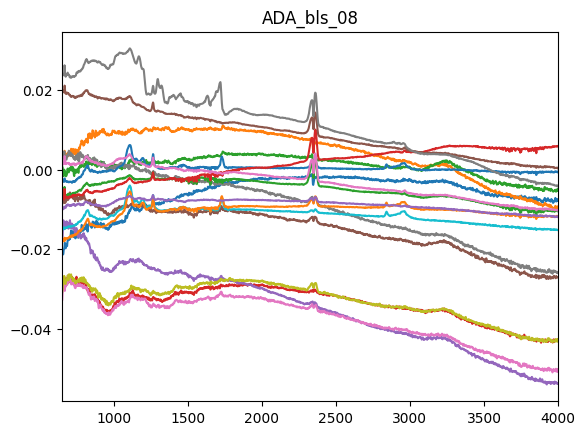

In [ ]:
plt.xlim(650,4000)
for i in YVA_raw_08:
  plt.title('YVA_bls_08')
  plt.plot(i[1],i[0])

for i in YQA_raw_08:
  plt.title('YQA_bls_08')
  plt.plot(i[1],i[0])

for i in YDA_raw_08:
  plt.title('YDA_bls_08')
  plt.plot(i[1],i[0])

for i in AVA_raw_08:
  plt.title('AVA_bls_08')
  plt.plot(i[1],i[0])

for i in AQA_raw_08:
  plt.title('AQA_bls_08')
  plt.plot(i[1],i[0])

for i in ADA_raw_08:
  plt.title('ADA_bls_08')
  plt.plot(i[1],i[0])

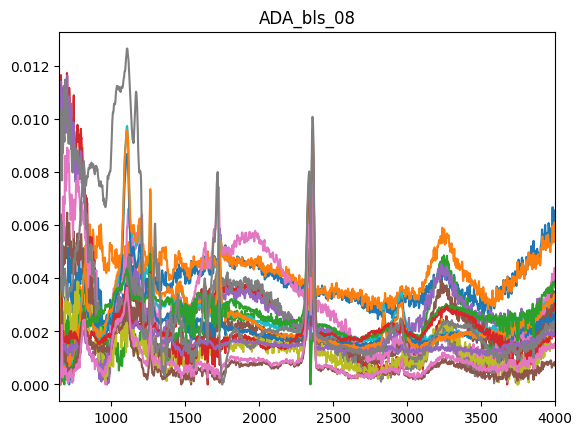

In [ ]:
plt.xlim(650,4000)
for i in YVA_bls_08:
  plt.title('YVA_bls_08')
  plt.plot(i[1],i[0])

for i in YQA_bls_08:
  plt.title('YQA_bls_08')
  plt.plot(i[1],i[0])

for i in YDA_bls_08:
  plt.title('YDA_bls_08')
  plt.plot(i[1],i[0])

for i in AVA_bls_08:
  plt.title('AVA_bls_08')
  plt.plot(i[1],i[0])

for i in AQA_bls_08:
  plt.title('AQA_bls_08')
  plt.plot(i[1],i[0])

for i in ADA_bls_08:
  plt.title('ADA_bls_08')
  plt.plot(i[1],i[0])

In [ ]:
# groups = [
#     ('YVA', YVA_raw_08, YVA_bls_08),
#     ('YQA', YQA_raw_08, YQA_bls_08),
#     ('YDA', YDA_raw_08, YDA_bls_08),
#     ('AVA', AVA_raw_08, AVA_bls_08),
#     ('AQA', AQA_raw_08, AQA_bls_08),
#     ('ADA', ADA_raw_08, ADA_bls_08),
# ]

# for name, raw_group, bls_group in groups:
#     plt.figure()
#     plt.title(f'{name} Corrected Spectra')

#     for raw, bls in zip(raw_group, bls_group):
#         corrected = raw[0] - bls[0]  # subtract intensity arrays
#         wavenumbers = raw[1]         # assumes same wavenumbers in both
#         rp.plot.spectra(corrected, wavenumbers, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label=f'{name}_corrected')

#     plt.legend()
#     plt.tight_layout()

<Axes: title={'center': 'Raman spectra'}, xlabel='Wavenumber (cm^-1)', ylabel='Absorbance [arb]'>

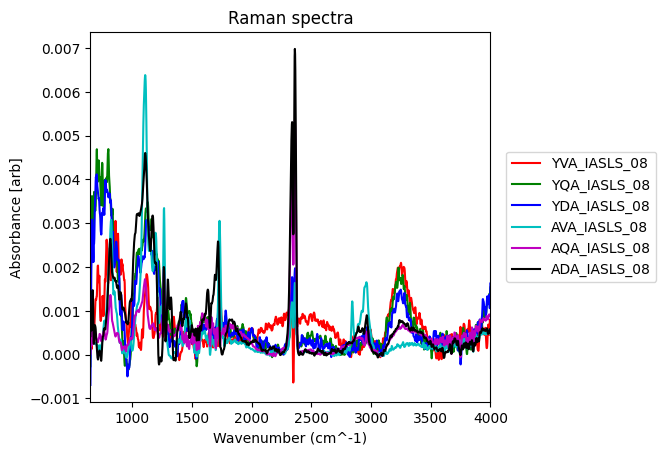

In [ ]:
################################# 04/08/25 Something Holiday DID to fix my Improved Asymmetric Least Squares Method especially for erreneous Aluminium Dip Method in Atmosphere from 650-4000 cm-1############################
##########

data_flatten = rp.preprocessing.baseline.ASLS(lam=10000.0, p=0.01, diff_order=6, max_iter=100, tol=0.001, weights=None)
data_flat = data_flatten(YQA_raw_08[0][0],YQA_raw_08[0][1])
data = np.empty(len(YQA_raw_08[0][1]))

plt.xlim(650,4000)

for i in YVA_raw_08:
  data_flat = data_flatten(i[0],i[1])
  data1 = rp.Spectrum(data_flat[0],i[1])
  data2 = rp.Spectrum(i[0],i[1])
  diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
  #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
  flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
  data = data[0] + [flat]
  #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
dataMean = rp.Spectrum(data[0]/3,YVA_raw_08[0][1])
rp.plot.spectra(dataMean, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'YVA_IASLS_08',color = 'r')

#data = np.empty(len(YQA_raw_08[0][1]))
#for i in YVA_bls_08:
#  plt.title('YVA_bls_08')
#  data = data + i[0]
#  print(np.shape(data))
#mean = rp.Spectrum(data/3,YVA_raw_08[0][1])
#rp.plot.spectra(mean, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'YVA_IASLS_08',color = 'b')


data = np.empty(len(YQA_raw_08[0][1]))
for i in YQA_raw_08:
  data_flat = data_flatten(i[0],i[1])
  data1 = rp.Spectrum(data_flat[0],i[1])
  data2 = rp.Spectrum(i[0],i[1])
  diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
  #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
  flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
  data = data[0] + [flat]
  #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
dataMean = rp.Spectrum(data[0]/3,YQA_raw_08[0][1])
rp.plot.spectra(dataMean, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'YQA_IASLS_08',color='g')

#for i in YQA_bls_08:
#  plt.title('YQA_bls_08')
#  plt.plot(i[1],i[0])


data = np.empty(len(YQA_raw_08[0][1]))
for i in YDA_raw_08:
  data_flat = data_flatten(i[0],i[1])
  data1 = rp.Spectrum(data_flat[0],i[1])
  data2 = rp.Spectrum(i[0],i[1])
  diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
  #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
  flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
  data = data[0] + [flat]
  #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
dataMean = rp.Spectrum(data[0]/3,YQA_raw_08[0][1])
rp.plot.spectra(dataMean, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'YDA_IASLS_08',color='b')

#for i in YDA_bls_08:
#  plt.title('YDA_bls_08')
#  plt.plot(i[1],i[0])


data = np.empty(len(YQA_raw_08[0][1]))
for i in AVA_raw_08:
  data_flat = data_flatten(i[0],i[1])
  data1 = rp.Spectrum(data_flat[0],i[1])
  data2 = rp.Spectrum(i[0],i[1])
  diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
  #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
  flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
  data = data[0] + [flat]
  #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
dataMean = rp.Spectrum(data[0]/3,YQA_raw_08[0][1])
rp.plot.spectra(dataMean, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'AVA_IASLS_08',color='c')


#for i in AVA_bls_08:
#  plt.title('AVA_bls_08')
#  plt.plot(i[1],i[0])


data = np.empty(len(YQA_raw_08[0][1]))
for i in AQA_raw_08:
  data_flat = data_flatten(i[0],i[1])
  data1 = rp.Spectrum(data_flat[0],i[1])
  data2 = rp.Spectrum(i[0],i[1])
  diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
  #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
  flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
  data = data[0] + [flat]
  #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
dataMean = rp.Spectrum(data[0]/3,YQA_raw_08[0][1])
rp.plot.spectra(dataMean, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'AQA_IASLS_08',color='m')


#for i in AQA_bls_08:
#  plt.title('AQA_bls_08')
#  plt.plot(i[1],i[0])

data = np.empty(len(YQA_raw_08[0][1]))
for i in ADA_raw_08:
  data_flat = data_flatten(i[0],i[1])
  data1 = rp.Spectrum(data_flat[0],i[1])
  data2 = rp.Spectrum(i[0],i[1])
  diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
  #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
  flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
  data = data[0] + [flat]
  #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
dataMean = rp.Spectrum(data[0]/3,YQA_raw_08[0][1])
rp.plot.spectra(dataMean, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ADA_IASLS_08',color='black')

#for i in ADA_bls_08:
#  plt.title('ADA_bls_08')
#  plt.plot(i[1],i[0])

<Axes: title={'center': 'Raman spectra'}, xlabel='Wavenumber (cm^-1)', ylabel='Absorbance [arb]'>

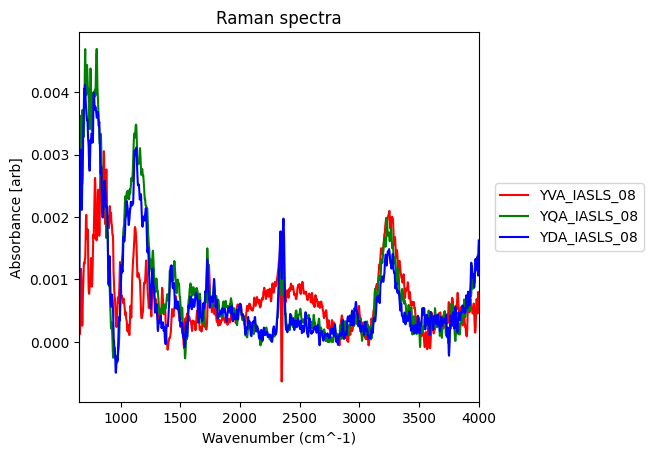

In [ ]:

################################# 04/08/25 Something Holiday DID to fix my Improved Asymmetric Least Squares Method especially for erreneous Aluminium Dip Method in Atmosphere from 650-4000 cm-1############################
##########
means = []  # List to store all three mean spectra

data_flatten = rp.preprocessing.baseline.ASLS(lam=10000.0, p=0.01, diff_order=6, max_iter=100, tol=0.001, weights=None)
data_flat = data_flatten(YQA_raw_08[0][0],YQA_raw_08[0][1])
data = np.empty(len(YQA_raw_08[0][1]))

plt.xlim(650,4000)

for i in YVA_raw_08:
  data_flat = data_flatten(i[0],i[1])
  data1 = rp.Spectrum(data_flat[0],i[1])
  data2 = rp.Spectrum(i[0],i[1])
  diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
  #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
  flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
  data = data[0] + [flat]
  #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
dataMean = rp.Spectrum(data[0]/3,YVA_raw_08[0][1])
means.append(dataMean)
rp.plot.spectra(dataMean, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'YVA_IASLS_08',color = 'r')

#data = np.empty(len(YQA_raw_08[0][1]))
#for i in YVA_bls_08:
#  plt.title('YVA_bls_08')
#  data = data + i[0]
#  print(np.shape(data))
#mean = rp.Spectrum(data/3,YVA_raw_08[0][1])
#rp.plot.spectra(mean, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'YVA_IASLS_08',color = 'b')


data = np.empty(len(YQA_raw_08[0][1]))
for i in YQA_raw_08:
  data_flat = data_flatten(i[0],i[1])
  data1 = rp.Spectrum(data_flat[0],i[1])
  data2 = rp.Spectrum(i[0],i[1])
  diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
  #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
  flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
  data = data[0] + [flat]
  #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
dataMean = rp.Spectrum(data[0]/3,YQA_raw_08[0][1])
means.append(dataMean)
rp.plot.spectra(dataMean, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'YQA_IASLS_08',color='g')

#for i in YQA_bls_08:
#  plt.title('YQA_bls_08')
#  plt.plot(i[1],i[0])


data = np.empty(len(YQA_raw_08[0][1]))
for i in YDA_raw_08:
  data_flat = data_flatten(i[0],i[1])
  data1 = rp.Spectrum(data_flat[0],i[1])
  data2 = rp.Spectrum(i[0],i[1])
  diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
  #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
  flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
  data = data[0] + [flat]
  #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
dataMean = rp.Spectrum(data[0]/3,YQA_raw_08[0][1])
means.append(dataMean)
rp.plot.spectra(dataMean, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'YDA_IASLS_08',color='b')


<Axes: title={'center': 'Raman spectra'}, xlabel='Wavenumber (cm^-1)', ylabel='Absorbance [arb]'>

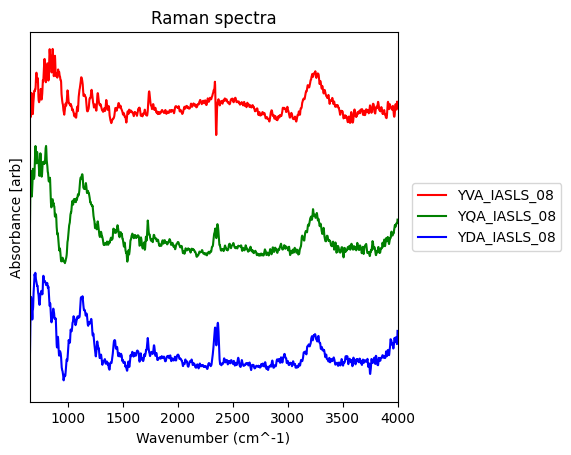

In [ ]:
plt.xlim(650,4000)
rp.plot.spectra(
    means,
    plot_type='single stacked',   # This is the key bit!   #"single stacked", "stacked", "separate-is default", "single" -plottypes
    xlabel="Wavenumber (cm^-1)",
    ylabel="Absorbance [arb]",
    label=['YVA_IASLS_08', 'YQA_IASLS_08', 'YDA_IASLS_08'],
    color=['r', 'g', 'b']
)

<Axes: title={'center': 'Raman spectra'}, xlabel='Wavenumber (cm^-1)', ylabel='Absorbance [arb]'>

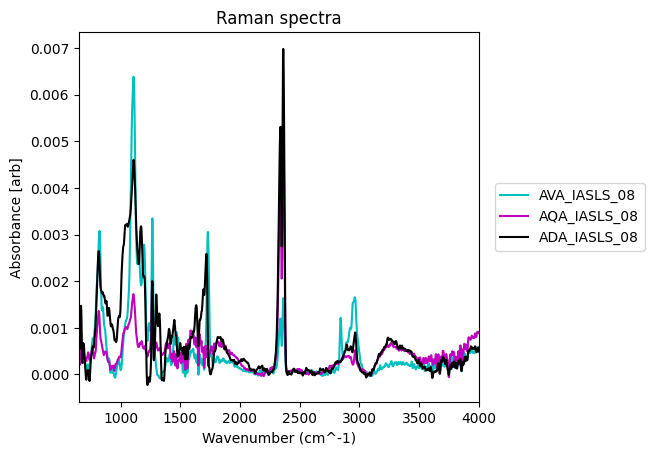

In [ ]:
################################# 04/08/25 Something Holiday DID to fix my Improved Asymmetric Least Squares Method especially for erreneous Aluminium Dip Method in Atmosphere from 650-4000 cm-1############################
##########
means2 = []  # List to store all three mean spectra
data_flatten = rp.preprocessing.baseline.ASLS(lam=10000.0, p=0.01, diff_order=6, max_iter=100, tol=0.001, weights=None)
data_flat = data_flatten(YQA_raw_08[0][0],YQA_raw_08[0][1])
data = np.empty(len(YQA_raw_08[0][1]))
plt.xlim(650,4000)

data = np.empty(len(YQA_raw_08[0][1]))
for i in AVA_raw_08:
  data_flat = data_flatten(i[0],i[1])
  data1 = rp.Spectrum(data_flat[0],i[1])
  data2 = rp.Spectrum(i[0],i[1])
  diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
  #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
  flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
  data = data[0] + [flat]
  #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
dataMean3 = rp.Spectrum(data[0]/3,YQA_raw_08[0][1])
means2.append(dataMean3)
rp.plot.spectra(dataMean3, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'AVA_IASLS_08',color='c')


#for i in AVA_bls_08:
#  plt.title('AVA_bls_08')
#  plt.plot(i[1],i[0])


data = np.empty(len(YQA_raw_08[0][1]))
for i in AQA_raw_08:
  data_flat = data_flatten(i[0],i[1])
  data1 = rp.Spectrum(data_flat[0],i[1])
  data2 = rp.Spectrum(i[0],i[1])
  diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
  #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
  flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
  data = data[0] + [flat]
  #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
dataMean4 = rp.Spectrum(data[0]/3,YQA_raw_08[0][1])
means2.append(dataMean4)
rp.plot.spectra(dataMean4, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'AQA_IASLS_08',color='m')


#for i in AQA_bls_08:
#  plt.title('AQA_bls_08')
#  plt.plot(i[1],i[0])

data = np.empty(len(YQA_raw_08[0][1]))
for i in ADA_raw_08:
  data_flat = data_flatten(i[0],i[1])
  data1 = rp.Spectrum(data_flat[0],i[1])
  data2 = rp.Spectrum(i[0],i[1])
  diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
  #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
  flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
  data = data[0] + [flat]
  #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
dataMean5 = rp.Spectrum(data[0]/3,YQA_raw_08[0][1])
means2.append(dataMean5)
rp.plot.spectra(dataMean5, plot_type = 'stacked', xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ADA_IASLS_08',color='black')

#for i in ADA_bls_08:
#  plt.title('ADA_bls_08')
#  plt.plot(i[1],i[0])


<Axes: title={'center': 'Raman spectra'}, xlabel='Wavenumber (cm^-1)', ylabel='Absorbance [arb]'>

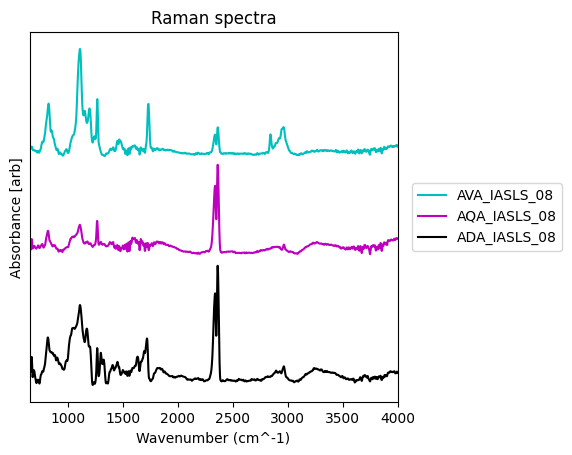

In [ ]:
plt.xlim(650,4000)
rp.plot.spectra(
    means2,
    plot_type='single stacked',   # This is the key bit!         #"single stacked", "stacked", "separate-is default", "single" -plottypes
    xlabel="Wavenumber (cm^-1)",
    ylabel="Absorbance [arb]",
    label=['AVA_IASLS_08', 'AQA_IASLS_08', 'ADA_IASLS_08'],
    color=['c', 'm', 'black'],
    #title=['Raman Spectra']
)

<Axes: title={'center': 'Raman spectra'}, xlabel='Wavenumber (cm^-1)', ylabel='Absorbance [arb]'>

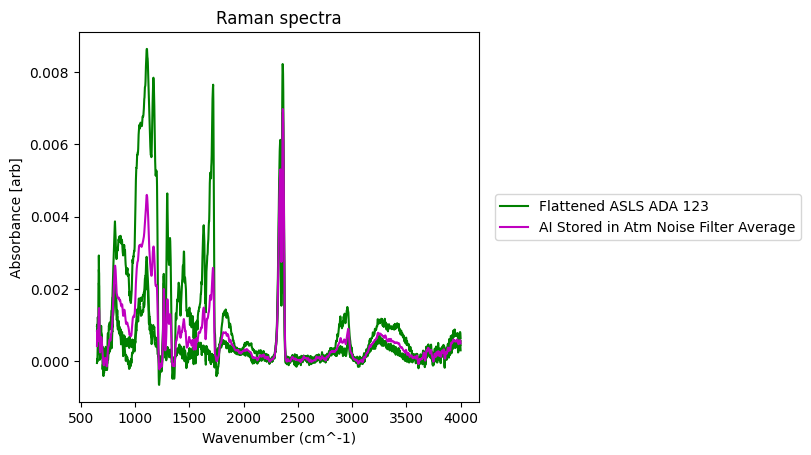

In [ ]:
# plt.ylim(-.0005,.0075)
data = np.empty(len(YQA_raw_08[0][1]))
for i in ADA_raw_08:
  data_flat = data_flatten(i[0],i[1])
  data1 = rp.Spectrum(data_flat[0],i[1])
  data2 = rp.Spectrum(i[0],i[1])
  diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
  #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
  flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
  data = data[0] + [flat]
  rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'Flattened ASLS ADA 123',color='green')
  # rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'Original ASLS ADA 123',color='red')
  # rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'DIFF ASLS 123',color='blue')
data08 = data[0]/3
dataMean08 = rp.Spectrum(data[0]/3,YQA_raw_08[0][1])
rp.plot.spectra(dataMean08, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'AI Stored in Atm Noise Filter Average',color='m')

# data = np.empty(len(YQA_raw_08[0][1]))
# for i in ADN_raw_08:
#   data_flat = data_flatten(i[0],i[1])
#   data1 = rp.Spectrum(data_flat[0],i[1])
#   data2 = rp.Spectrum(i[0],i[1])
#   diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
#   #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
#   flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
#   data = data[0] + [flat]
#   #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
#   #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
#   #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
# data08 = data[0]/3
# dataMean08 = rp.Spectrum(data[0]/3,YQA_raw_08[0][1])
# rp.plot.spectra(dataMean08, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'Stored in Nitrogen',color='green')
# plt.title("Aluminum Dipped Samples, Day 1")

<Axes: title={'center': 'Raman spectra'}, xlabel='Wavenumber (cm^-1)', ylabel='Absorbance [arb]'>

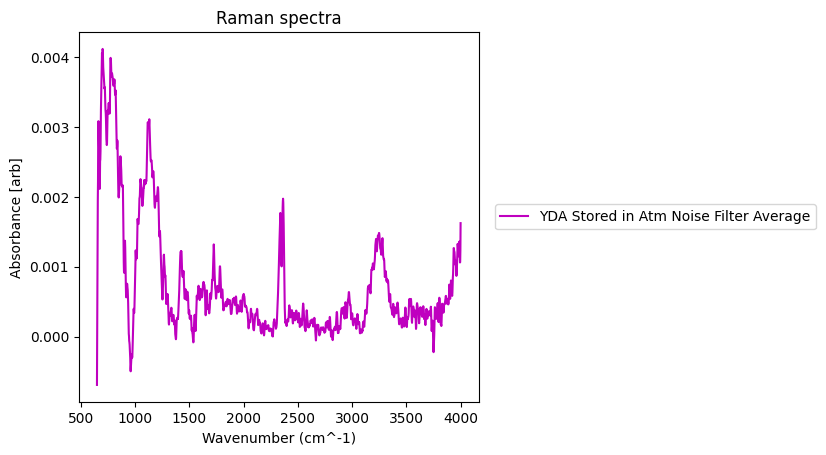

In [ ]:
# plt.ylim(-.0005,.0075)
data = np.empty(len(YQA_raw_08[0][1]))
for i in YDA_raw_08:
  data_flat = data_flatten(i[0],i[1])
  data1 = rp.Spectrum(data_flat[0],i[1])
  data2 = rp.Spectrum(i[0],i[1])
  diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
  #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
  flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
  data = data[0] + [flat]
  #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'Flattened ASLS ADA 123',color='green' )
  # rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'Original ASLS ADA 123',color='red' )
  # rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'Diff ASLS ADA 123',color='blue' )
data08 = data[0]/3
dataMean08 = rp.Spectrum(data[0]/3,YQA_raw_08[0][1])
rp.plot.spectra(dataMean08, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'YDA Stored in Atm Noise Filter Average',color='m')

# data = np.empty(len(YQA_raw_08[0][1]))
# for i in YDN_raw_08:
#   data_flat = data_flatten(i[0],i[1])
#   data1 = rp.Spectrum(data_flat[0],i[1])
#   data2 = rp.Spectrum(i[0],i[1])
#   diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
#   #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
#   flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
#   data = data[0] + [flat]
#   #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
#   #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
#   #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
# data08 = data[0]/3
# dataMean08 = rp.Spectrum(data[0]/3,YQA_raw_08[0][1])
# rp.plot.spectra(dataMean08, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'Stored in Nitrogen',color='green')
# plt.title("Yttrium Dipped Samples, Day 1")

<Axes: title={'center': 'Raman spectra'}, xlabel='Wavenumber (cm^-1)', ylabel='Absorbance [arb]'>

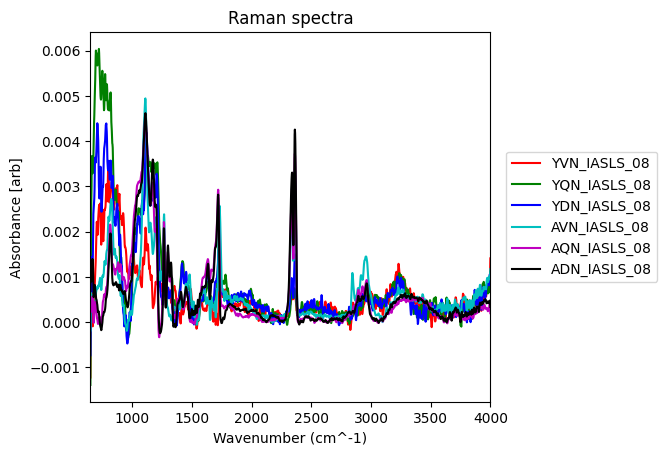

In [ ]:
###################################### Lol this is not the same as the above graph But ############################
########It is very similar Because these are the 1st day samples 04/08/2025 N tags #################
################# They are going to be placed into Nitrogen Wash to be aged instead of Atmosphere Like others########################


data_flatten = rp.preprocessing.baseline.ASLS(lam=10000.0, p=0.01, diff_order=6, max_iter=100, tol=0.001, weights=None)
data_flat = data_flatten(YQA_raw_08[0][0],YQA_raw_08[0][1])
data = np.empty(len(YQA_raw_08[0][1]))
plt.xlim(650,4000)

for i in YVN_raw_08:
  data_flat = data_flatten(i[0],i[1])
  data1 = rp.Spectrum(data_flat[0],i[1])
  data2 = rp.Spectrum(i[0],i[1])
  diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
  #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
  flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
  data = data[0] + [flat]
  #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
dataMean = rp.Spectrum(data[0]/3,YVA_raw_08[0][1])
rp.plot.spectra(dataMean, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'YVN_IASLS_08',color = 'r')

#data = np.empty(len(YQA_raw_08[0][1]))
#for i in YVA_bls_08:
#  plt.title('YVA_bls_08')
#  data = data + i[0]
#  print(np.shape(data))
#mean = rp.Spectrum(data/3,YVA_raw_08[0][1])
#rp.plot.spectra(mean, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'YVA_IASLS_08',color = 'b')


data = np.empty(len(YQA_raw_08[0][1]))
for i in YQN_raw_08:
  data_flat = data_flatten(i[0],i[1])
  data1 = rp.Spectrum(data_flat[0],i[1])
  data2 = rp.Spectrum(i[0],i[1])
  diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
  #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
  flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
  data = data[0] + [flat]
  #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
dataMean = rp.Spectrum(data[0]/3,YQA_raw_08[0][1])
rp.plot.spectra(dataMean, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'YQN_IASLS_08',color='g')

#for i in YQA_bls_08:
#  plt.title('YQA_bls_08')
#  plt.plot(i[1],i[0])


data = np.empty(len(YQA_raw_08[0][1]))
for i in YDN_raw_08:
  data_flat = data_flatten(i[0],i[1])
  data1 = rp.Spectrum(data_flat[0],i[1])
  data2 = rp.Spectrum(i[0],i[1])
  diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
  #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
  flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
  data = data[0] + [flat]
  #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
dataMean = rp.Spectrum(data[0]/3,YQA_raw_08[0][1])
rp.plot.spectra(dataMean, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'YDN_IASLS_08',color='b')

#for i in YDA_bls_08:
#  plt.title('YDA_bls_08')
#  plt.plot(i[1],i[0])


data = np.empty(len(YQA_raw_08[0][1]))
for i in AVN_raw_08:
  data_flat = data_flatten(i[0],i[1])
  data1 = rp.Spectrum(data_flat[0],i[1])
  data2 = rp.Spectrum(i[0],i[1])
  diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
  #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
  flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
  data = data[0] + [flat]
  #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
dataMean = rp.Spectrum(data[0]/3,YQA_raw_08[0][1])
rp.plot.spectra(dataMean, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'AVN_IASLS_08',color='c')


#for i in AVA_bls_08:
#  plt.title('AVA_bls_08')
#  plt.plot(i[1],i[0])


data = np.empty(len(YQA_raw_08[0][1]))
for i in AQN_raw_08:
  data_flat = data_flatten(i[0],i[1])
  data1 = rp.Spectrum(data_flat[0],i[1])
  data2 = rp.Spectrum(i[0],i[1])
  diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
  #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
  flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
  data = data[0] + [flat]
  #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
dataMean = rp.Spectrum(data[0]/3,YQA_raw_08[0][1])
rp.plot.spectra(dataMean, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'AQN_IASLS_08',color='m')


#for i in AQA_bls_08:
#  plt.title('AQA_bls_08')
#  plt.plot(i[1],i[0])

data = np.empty(len(YQA_raw_08[0][1]))
for i in ADN_raw_08:
  data_flat = data_flatten(i[0],i[1])
  data1 = rp.Spectrum(data_flat[0],i[1])
  data2 = rp.Spectrum(i[0],i[1])
  diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
  #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
  flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
  data = data[0] + [flat]
  #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
dataMean = rp.Spectrum(data[0]/3,YQA_raw_08[0][1])
rp.plot.spectra(dataMean, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ADN_IASLS_08',color='black')

#for i in ADA_bls_08:
#  plt.title('ADA_bls_08')
#  plt.plot(i[1],i[0])


<Axes: title={'center': 'Raman spectra'}, xlabel='Wavenumber (cm^-1)', ylabel='Absorbance [arb]'>

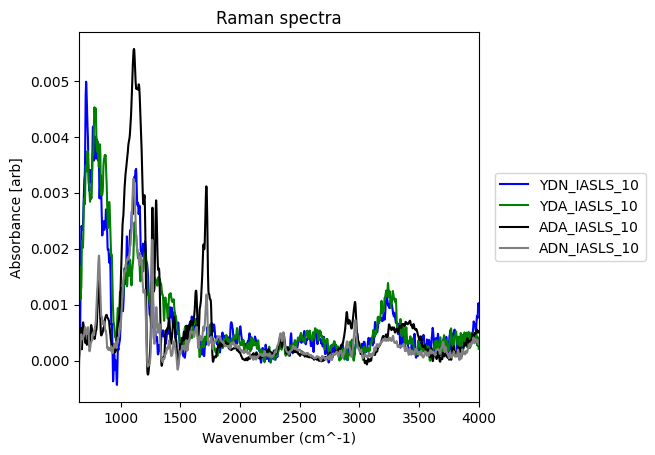

In [ ]:
########################### From Day 3 ------04/10/25///        ########################################################  DATA



data_flatten = rp.preprocessing.baseline.ASLS(lam=10000.0, p=0.01, diff_order=6, max_iter=100, tol=0.001, weights=None)
data_flat = data_flatten(YQA_raw_08[0][0],YQA_raw_08[0][1])
data = np.empty(len(YQA_raw_08[0][1]))
plt.xlim(650,4000)

data = np.empty(len(YQA_raw_08[0][1]))
for i in YDN_raw_10:
  data_flat = data_flatten(i[0],i[1])
  data1 = rp.Spectrum(data_flat[0],i[1])
  data2 = rp.Spectrum(i[0],i[1])
  diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
  #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
  flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
  data = data[0] + [flat]
  #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
dataMean = rp.Spectrum(data[0]/3,YQA_raw_08[0][1])
rp.plot.spectra(dataMean, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'YDN_IASLS_10',color='b')
data = np.empty(len(YQA_raw_08[0][1]))

for i in YDA_raw_10:
  data_flat = data_flatten(i[0],i[1])
  data1 = rp.Spectrum(data_flat[0],i[1])
  data2 = rp.Spectrum(i[0],i[1])
  diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
  #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
  flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
  data = data[0] + [flat]
  #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
dataMean = rp.Spectrum(data[0]/3,YQA_raw_08[0][1])
rp.plot.spectra(dataMean, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'YDA_IASLS_10',color='green')
#for i in YDA_bls_08:
#  plt.title('YDA_bls_08')
#  plt.plot(i[1],i[0])

data = np.empty(len(YQA_raw_08[0][1]))
for i in ADA_raw_10:
  data_flat = data_flatten(i[0],i[1])
  data1 = rp.Spectrum(data_flat[0],i[1])
  data2 = rp.Spectrum(i[0],i[1])
  diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
  #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
  flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
  data = data[0] + [flat]
  #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
dataMean = rp.Spectrum(data[0]/3,YQA_raw_08[0][1])
rp.plot.spectra(dataMean, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ADA_IASLS_10',color='black')

data = np.empty(len(YQN_raw_08[0][1]))
for i in ADN_raw_10:
  data_flat = data_flatten(i[0],i[1])
  data1 = rp.Spectrum(data_flat[0],i[1])
  data2 = rp.Spectrum(i[0],i[1])
  diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
  #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
  flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
  data = data[0] + [flat]
  #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
dataMean = rp.Spectrum(data[0]/3,YQA_raw_08[0][1])
rp.plot.spectra(dataMean, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ADN_IASLS_10',color='grey')

#for i in ADA_bls_08:
#  plt.title('ADA_bls_08')
#  plt.plot(i[1],i[0])


(650.0, 4000.0)

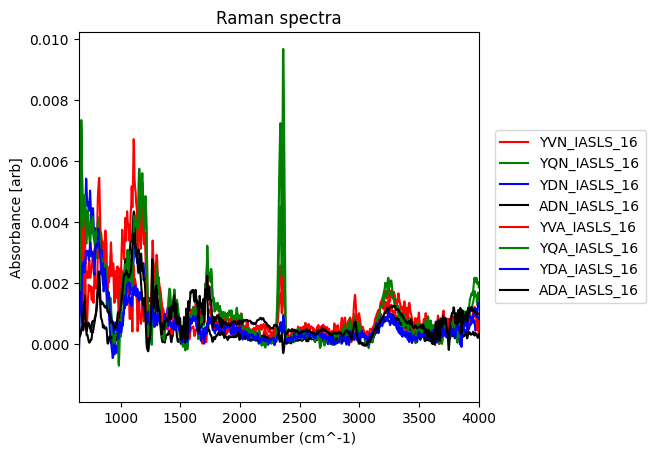

In [ ]:
#######################From Day 7 04-16-25- DATA###################################################


data_flatten = rp.preprocessing.baseline.ASLS(lam=10000.0, p=0.01, diff_order=6, max_iter=100, tol=0.001, weights=None)
data_flat = data_flatten(YQA_raw_08[0][0],YQA_raw_08[0][1])
data = np.empty(len(YQA_raw_08[0][1]))
plt.xlim(650,4000)

for i in YVN_raw_16:
  data_flat = data_flatten(i[0],i[1])
  data1 = rp.Spectrum(data_flat[0],i[1])
  data2 = rp.Spectrum(i[0],i[1])
  diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
  #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
  flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
  data = data[0] + [flat]
  #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
dataMean = rp.Spectrum(data[0]/3,YVA_raw_08[0][1])
rp.plot.spectra(dataMean, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'YVN_IASLS_16',color = 'r')

#data = np.empty(len(YQA_raw_08[0][1]))
#for i in YVA_bls_08:
#  plt.title('YVA_bls_08')
#  data = data + i[0]
#  print(np.shape(data))
#mean = rp.Spectrum(data/3,YVA_raw_08[0][1])
#rp.plot.spectra(mean, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'YVA_IASLS_08',color = 'b')


data = np.empty(len(YQA_raw_08[0][1]))
for i in YQN_raw_16:
  data_flat = data_flatten(i[0],i[1])
  data1 = rp.Spectrum(data_flat[0],i[1])
  data2 = rp.Spectrum(i[0],i[1])
  diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
  #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
  flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
  data = data[0] + [flat]
  #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
dataMean = rp.Spectrum(data[0]/3,YQA_raw_08[0][1])
rp.plot.spectra(dataMean, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'YQN_IASLS_16',color='g')

#for i in YQA_bls_08:
#  plt.title('YQA_bls_08')
#  plt.plot(i[1],i[0])


data = np.empty(len(YQA_raw_08[0][1]))
for i in YDN_raw_16:
  data_flat = data_flatten(i[0],i[1])
  data1 = rp.Spectrum(data_flat[0],i[1])
  data2 = rp.Spectrum(i[0],i[1])
  diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
  #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
  flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
  data = data[0] + [flat]
  #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
dataMean = rp.Spectrum(data[0]/3,YQA_raw_08[0][1])
rp.plot.spectra(dataMean, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'YDN_IASLS_16',color='b')

data = np.empty(len(YQA_raw_08[0][1]))
for i in ADN_raw_16:
  data_flat = data_flatten(i[0],i[1])
  data1 = rp.Spectrum(data_flat[0],i[1])
  data2 = rp.Spectrum(i[0],i[1])
  diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
  #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
  flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
  data = data[0] + [flat]
  #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
dataMean = rp.Spectrum(data[0]/3,YQA_raw_08[0][1])
rp.plot.spectra(dataMean, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ADN_IASLS_16',color='black')

#for i in ADA_bls_08:
#  plt.title('ADA_bls_08')
#  plt.plot(i[1],i[0])


for i in YVA_raw_16:
  data_flat = data_flatten(i[0],i[1])
  data1 = rp.Spectrum(data_flat[0],i[1])
  data2 = rp.Spectrum(i[0],i[1])
  diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
  #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
  flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
  data = data[0] + [flat]
  #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
dataMean = rp.Spectrum(data[0]/3,YVA_raw_08[0][1])
rp.plot.spectra(dataMean, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'YVA_IASLS_16',color = 'r')

#data = np.empty(len(YQA_raw_08[0][1]))
#for i in YVA_bls_08:
#  plt.title('YVA_bls_08')
#  data = data + i[0]
#  print(np.shape(data))
#mean = rp.Spectrum(data/3,YVA_raw_08[0][1])
#rp.plot.spectra(mean, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'YVA_IASLS_08',color = 'b')


data = np.empty(len(YQA_raw_08[0][1]))
for i in YQA_raw_16:
  data_flat = data_flatten(i[0],i[1])
  data1 = rp.Spectrum(data_flat[0],i[1])
  data2 = rp.Spectrum(i[0],i[1])
  diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
  #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
  flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
  data = data[0] + [flat]
  #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
dataMean = rp.Spectrum(data[0]/3,YQA_raw_08[0][1])
rp.plot.spectra(dataMean, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'YQA_IASLS_16',color='g')

#for i in YQA_bls_08:
#  plt.title('YQA_bls_08')
#  plt.plot(i[1],i[0])


data = np.empty(len(YQA_raw_08[0][1]))
for i in YDA_raw_16:
  data_flat = data_flatten(i[0],i[1])
  data1 = rp.Spectrum(data_flat[0],i[1])
  data2 = rp.Spectrum(i[0],i[1])
  diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
  #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
  flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
  data = data[0] + [flat]
  #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
dataMean = rp.Spectrum(data[0]/3,YQA_raw_08[0][1])
rp.plot.spectra(dataMean, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'YDA_IASLS_16',color='b')

data = np.empty(len(YQA_raw_08[0][1]))
for i in ADA_raw_16:
  data_flat = data_flatten(i[0],i[1])
  data1 = rp.Spectrum(data_flat[0],i[1])
  data2 = rp.Spectrum(i[0],i[1])
  diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
  #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
  flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
  data = data[0] + [flat]
  #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
dataMean = rp.Spectrum(data[0]/3,YQA_raw_08[0][1])
rp.plot.spectra(dataMean, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ADA_IASLS_16',color='black')

#for i in ADA_bls_08:
#  plt.title('ADA_bls_08')
#  plt.plot(i[1],i[0])data_flatten = rp.preprocessing.baseline.ASLS(lam=10000.0, p=0.01, diff_order=6, max_iter=100, tol=0.001, weights=None)
data_flat = data_flatten(YQA_raw_08[0][0],YQA_raw_08[0][1])
data = np.empty(len(YQA_raw_08[0][1]))
plt.xlim(650,4000)
######################################################### DID the same thing twice for whatever reason
# for i in YVN_raw_16:
#   data_flat = data_flatten(i[0],i[1])
#   data1 = rp.Spectrum(data_flat[0],i[1])
#   data2 = rp.Spectrum(i[0],i[1])
#   diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
#   #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
#   flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
#   data = data[0] + [flat]
#   #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
#   #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
#   #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
# dataMean = rp.Spectrum(data[0]/3,YVA_raw_08[0][1])
# rp.plot.spectra(dataMean, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'YVN_IASLS_16',color = 'r')

# #data = np.empty(len(YQA_raw_08[0][1]))
# #for i in YVA_bls_08:
# #  plt.title('YVA_bls_08')
# #  data = data + i[0]
# #  print(np.shape(data))
# #mean = rp.Spectrum(data/3,YVA_raw_08[0][1])
# #rp.plot.spectra(mean, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'YVA_IASLS_08',color = 'b')


# data = np.empty(len(YQA_raw_08[0][1]))
# for i in YQN_raw_16:
#   data_flat = data_flatten(i[0],i[1])
#   data1 = rp.Spectrum(data_flat[0],i[1])
#   data2 = rp.Spectrum(i[0],i[1])
#   diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
#   #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
#   flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
#   data = data[0] + [flat]
#   #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
#   #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
#   #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
# dataMean = rp.Spectrum(data[0]/3,YQA_raw_08[0][1])
# rp.plot.spectra(dataMean, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'YQN_IASLS_16',color='g')

# #for i in YQA_bls_08:
# #  plt.title('YQA_bls_08')
# #  plt.plot(i[1],i[0])


# data = np.empty(len(YQA_raw_08[0][1]))
# for i in YDN_raw_16:
#   data_flat = data_flatten(i[0],i[1])
#   data1 = rp.Spectrum(data_flat[0],i[1])
#   data2 = rp.Spectrum(i[0],i[1])
#   diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
#   #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
#   flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
#   data = data[0] + [flat]
#   #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
#   #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
#   #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
# dataMean = rp.Spectrum(data[0]/3,YQA_raw_08[0][1])
# rp.plot.spectra(dataMean, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'YDN_IASLS_16',color='b')

# data = np.empty(len(YQA_raw_08[0][1]))
# for i in ADN_raw_16:
#   data_flat = data_flatten(i[0],i[1])
#   data1 = rp.Spectrum(data_flat[0],i[1])
#   data2 = rp.Spectrum(i[0],i[1])
#   diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
#   #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
#   flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
#   data = data[0] + [flat]
#   #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
#   #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
#   #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
# dataMean = rp.Spectrum(data[0]/3,YQA_raw_08[0][1])
# rp.plot.spectra(dataMean, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ADN_IASLS_16',color='black')

# #for i in ADA_bls_08:
# #  plt.title('ADA_bls_08')
# #  plt.plot(i[1],i[0])


# for i in YVA_raw_16:
#   data_flat = data_flatten(i[0],i[1])
#   data1 = rp.Spectrum(data_flat[0],i[1])
#   data2 = rp.Spectrum(i[0],i[1])
#   diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
#   #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
#   flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
#   data = data[0] + [flat]
#   #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
#   #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
#   #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
# dataMean = rp.Spectrum(data[0]/3,YVA_raw_08[0][1])
# rp.plot.spectra(dataMean, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'YVA_IASLS_16',color = 'r')

# #data = np.empty(len(YQA_raw_08[0][1]))
# #for i in YVA_bls_08:
# #  plt.title('YVA_bls_08')
# #  data = data + i[0]
# #  print(np.shape(data))
# #mean = rp.Spectrum(data/3,YVA_raw_08[0][1])
# #rp.plot.spectra(mean, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'YVA_IASLS_08',color = 'b')


# data = np.empty(len(YQA_raw_08[0][1]))
# for i in YQA_raw_16:
#   data_flat = data_flatten(i[0],i[1])
#   data1 = rp.Spectrum(data_flat[0],i[1])
#   data2 = rp.Spectrum(i[0],i[1])
#   diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
#   #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
#   flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
#   data = data[0] + [flat]
#   #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
#   #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
#   #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
# dataMean = rp.Spectrum(data[0]/3,YQA_raw_08[0][1])
# rp.plot.spectra(dataMean, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'YQA_IASLS_16',color='g')

# #for i in YQA_bls_08:
# #  plt.title('YQA_bls_08')
# #  plt.plot(i[1],i[0])


# data = np.empty(len(YQA_raw_08[0][1]))
# for i in YDA_raw_16:
#   data_flat = data_flatten(i[0],i[1])
#   data1 = rp.Spectrum(data_flat[0],i[1])
#   data2 = rp.Spectrum(i[0],i[1])
#   diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
#   #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
#   flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
#   data = data[0] + [flat]
#   #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
#   #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
#   #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
# dataMean = rp.Spectrum(data[0]/3,YQA_raw_08[0][1])
# rp.plot.spectra(dataMean, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'YDA_IASLS_16',color='b')

# data = np.empty(len(YQA_raw_08[0][1]))
# for i in ADA_raw_16:
#   data_flat = data_flatten(i[0],i[1])
#   data1 = rp.Spectrum(data_flat[0],i[1])
#   data2 = rp.Spectrum(i[0],i[1])
#   diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
#   #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
#   flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
#   data = data[0] + [flat]
#   #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
#   #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
#   #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
# dataMean = rp.Spectrum(data[0]/3,YQA_raw_08[0][1])
# rp.plot.spectra(dataMean, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ADA_IASLS_16',color='black')

# #for i in ADA_bls_08:
# #  plt.title('ADA_bls_08')
# #  plt.plot(i[1],i[0])

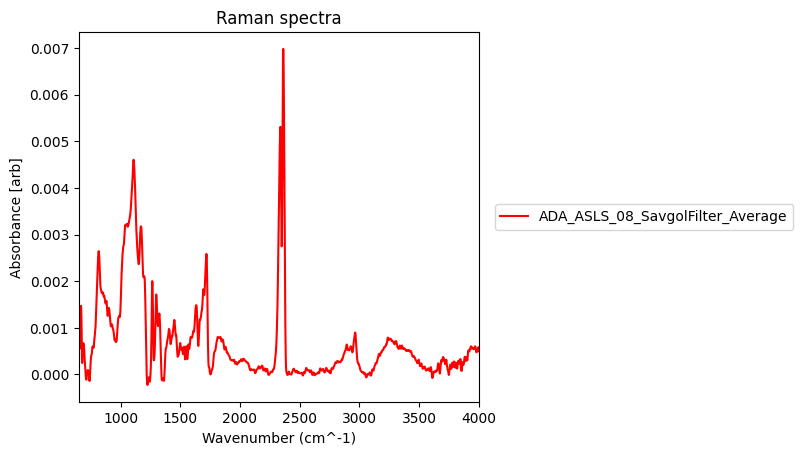

In [ ]:
data = np.empty(len(YQA_raw_08[0][1]))
plt.xlim(650,4000)
for i in ADA_raw_08:
  data_flat = data_flatten(i[0],i[1])
  data1 = rp.Spectrum(data_flat[0],i[1])
  data2 = rp.Spectrum(i[0],i[1])
  diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
  #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
  flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
  data = data[0] + [flat]
  #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
data08 = data[0]/3
dataMean08 = rp.Spectrum(data[0]/3,YQA_raw_08[0][1])
rp.plot.spectra(dataMean08, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ADA_ASLS_08_SavgolFilter_Average',color='red')

data = np.empty(len(YQA_raw_08[0][1]))
for i in ADN_raw_08:
  data_flat = data_flatten(i[0],i[1])
  data1 = rp.Spectrum(data_flat[0],i[1])
  data2 = rp.Spectrum(i[0],i[1])
  diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
  #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
  flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
  data = data[0] + [flat]
  #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
data08 = data[0]/3
dataMean08 = rp.Spectrum(data[0]/3,YQA_raw_08[0][1])
#rp.plot.spectra(dataMean08, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ADA_IASLS_08',color='green')

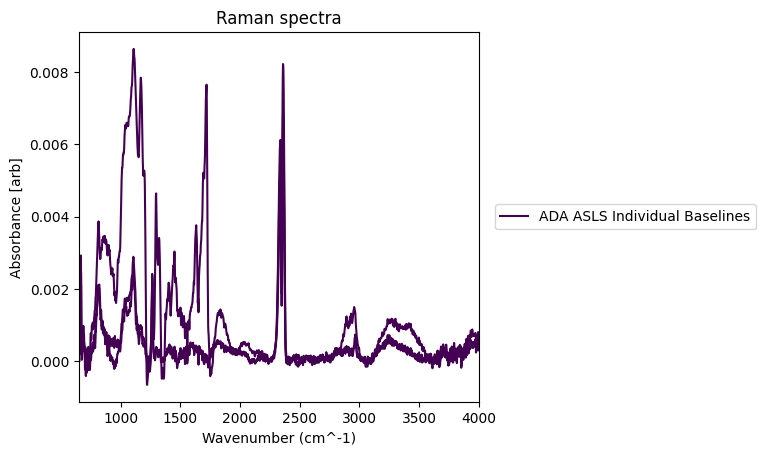

In [ ]:
plt.xlim(650,4000)
for i in ADA_raw_08:
  data_flat = data_flatten(i[0],i[1])
  data1 = rp.Spectrum(data_flat[0],i[1])
  data2 = rp.Spectrum(i[0],i[1])
  diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
  #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
  flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
  data = data[0] + [flat]

  rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ADA ASLS Individual Baselines')
  #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')

Text(0.5, 1.0, 'Silane Spectrum on Dipped Aluminum, Stored in Atmosphere')

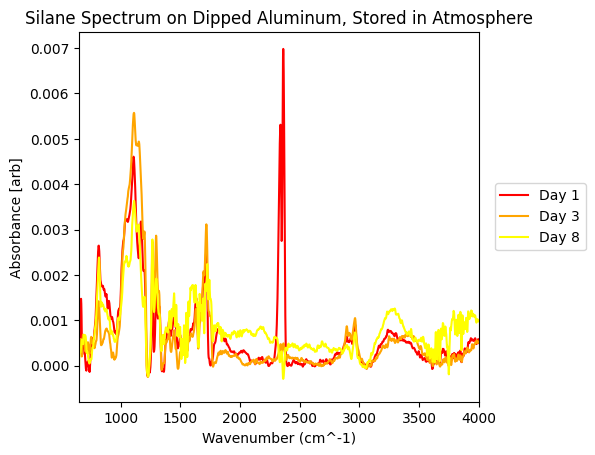

In [ ]:
######################## Comparing 04/08, 04/10 and 04/16, Noise Reduced Savoy filter, and Difference plotted between 08 and 010, and 08 and 16
data = np.empty(len(YQA_raw_08[0][1]))
for i in ADA_raw_08:
  data_flat = data_flatten(i[0],i[1])
  data1 = rp.Spectrum(data_flat[0],i[1])
  data2 = rp.Spectrum(i[0],i[1])
  diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
  #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
  flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
  data = data[0] + [flat]
  #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
data08 = data[0]/3
dataMean08 = rp.Spectrum(data[0]/3,YQA_raw_08[0][1])
rp.plot.spectra(dataMean08, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'Day 1',color='red')

data = np.empty(len(YQA_raw_08[0][1]))
for i in ADA_raw_10:
  data_flat = data_flatten(i[0],i[1])
  data1 = rp.Spectrum(data_flat[0],i[1])
  data2 = rp.Spectrum(i[0],i[1])
  diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
  #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
  flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
  data = data[0] + [flat]
  #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
data10 = data[0]/3
dataMean10 = rp.Spectrum(data[0]/3,YQA_raw_08[0][1])
rp.plot.spectra(dataMean10, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'Day 3',color='orange')

data = np.empty(len(YQA_raw_08[0][1]))
for i in ADA_raw_16:
  data_flat = data_flatten(i[0],i[1])
  data1 = rp.Spectrum(data_flat[0],i[1])
  data2 = rp.Spectrum(i[0],i[1])
  diff  = rp.Spectrum(i[0]-data_flat[0],i[1])
  #flat = rp.preprocessing.denoise.gaussian_filter(data_flat[0],sigma=5)
  flat = rp.preprocessing.denoise.savgol_filter(data_flat[0],10,3)
  data = data[0] + [flat]
  #rp.plot.spectra(data1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra(data2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
  #rp.plot.spectra( diff, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ASLS')
data16 = data[0]/3
dataMean16 = rp.Spectrum(data[0]/3,YQA_raw_08[0][1])
rp.plot.spectra(dataMean16, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'Day 8',color='yellow')

diff1 = rp.Spectrum(data10 - data08,YQA_raw_08[0][1])
diff2 = rp.Spectrum(data16-data08,YQA_raw_08[0][1])
# rp.plot.spectra(diff1, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ADA_IASLS_Difference 8th-10th',color='grey')
# rp.plot.spectra(diff2, xlabel="Wavenumber (cm^-1)", ylabel="Absorbance [arb]",label = 'ADA_IASLS_Difference 8th-16th',color='black')
plt.xlim(650,4000)
#plt.ylim(0,.004)
plt.title('Silane Spectrum on Dipped Aluminum, Stored in Atmosphere')


In [ ]:
YVA_raw_08 = [YVA1_raw_08,YVA2_raw_08,YVA3_raw_08]
YVN_raw_08 = [YVN1_raw_08,YVN2_raw_08,YVN3_raw_08]

YQA_raw_08 = [YQA1_raw_08,YQA2_raw_08,YQA3_raw_08]
YQN_raw_08 = [YQN1_raw_08,YQN2_raw_08,YQN3_raw_08]

YDA_raw_08 = [YDA1_raw_08,YDA2_raw_08,YDA3_raw_08]
YDN_raw_08 = [YDN1_raw_08,YDN2_raw_08,YDN3_raw_08]

AVA_raw_08 = [AVA1_raw_08,AVA2_raw_08,AVA3_raw_08]
AVN_raw_08 = [AVN1_raw_08,YVN2_raw_08,AVN3_raw_08]

AQA_raw_08 = [AQA1_raw_08,AQA2_raw_08,AQA3_raw_08]
AQN_raw_08 = [AQN1_raw_08,AQN2_raw_08,AQN3_raw_08]

ADA_raw_08 = [ADA1_raw_08,ADA2_raw_08,ADA3_raw_08]
ADN_raw_08 = [ADN1_raw_08,ADN2_raw_08,ADN3_raw_08]

YDA_raw_10 = [YDA1_raw_10,YDA2_raw_10,YDA3_raw_10]
YDN_raw_10 = [YDN1_raw_10,YDN2_raw_10,YDN3_raw_10]

ADA_raw_10 = [ADA1_raw_10,ADA2_raw_10,ADA3_raw_10]
ADN_raw_10 = [ADN1_raw_10,ADN2_raw_10,ADN3_raw_10]

YVA_raw_16 = [YVA1_raw_16,YVA2_raw_16,YVA3_raw_16]
YVN_raw_16 = [YVN1_raw_16,YVN2_raw_16,YVN3_raw_16]

YQA_raw_16 = [YQA1_raw_16,YQA2_raw_16,YQA3_raw_16]
YQN_raw_16 = [YQN1_raw_16,YQN2_raw_16,YQN3_raw_16]

YDA_raw_16 = [YDA1_raw_16,YDA2_raw_16,YDA3_raw_16]
YDN_raw_16 = [YDN1_raw_16,YDN2_raw_16,YDN3_raw_16]

ADA_raw_16 = [ADA1_raw_16,ADA2_raw_16,ADA3_raw_16]
ADN_raw_16 = [ADN1_raw_16,ADN2_raw_16,ADN3_raw_16]

In [ ]:
YV_08 = [YVA1_raw_16,YVA2_raw_16,YVA3_raw_16,
         YVN1_raw_16,YVN2_raw_16,YVN3_raw_16]
YQ_08 = [YQA1_raw_16,YQA2_raw_16,YQA3_raw_16,
         YQN1_raw_16,YQN2_raw_16,YQN3_raw_16]
YD_08 = [YDA1_raw_16,YDA2_raw_16,YDA3_raw_16,
         YDN1_raw_16,YDN2_raw_16,YDN3_raw_16]
AV_08 = [AVA1_raw_08,AVA2_raw_08,AVA3_raw_08,
         AVN1_raw_08,AVN2_raw_08,AVN3_raw_08]
AQ_08 = [AQA1_raw_08,AQA2_raw_08,AQA3_raw_08,
         AQN1_raw_08,AQN2_raw_08,AQN3_raw_08]
AD_08 = [ADA1_raw_16,ADA2_raw_16,ADA3_raw_16,
         ADN1_raw_16,ADN2_raw_16,ADN3_raw_16]

In [ ]:
file1 = YVA1_raw_08
file2 = YVA2_raw_08
file3 = YVA3_raw_08
file4 = YQA1_raw_08
file5 = YQA2_raw_08
file6 = YQA3_raw_08
file7 = YDA1_raw_08
file8 = YDA2_raw_08
file9 = YDA3_raw_08


Plotting Spectrum 0
Plotting Spectrum 1
Plotting Spectrum 2


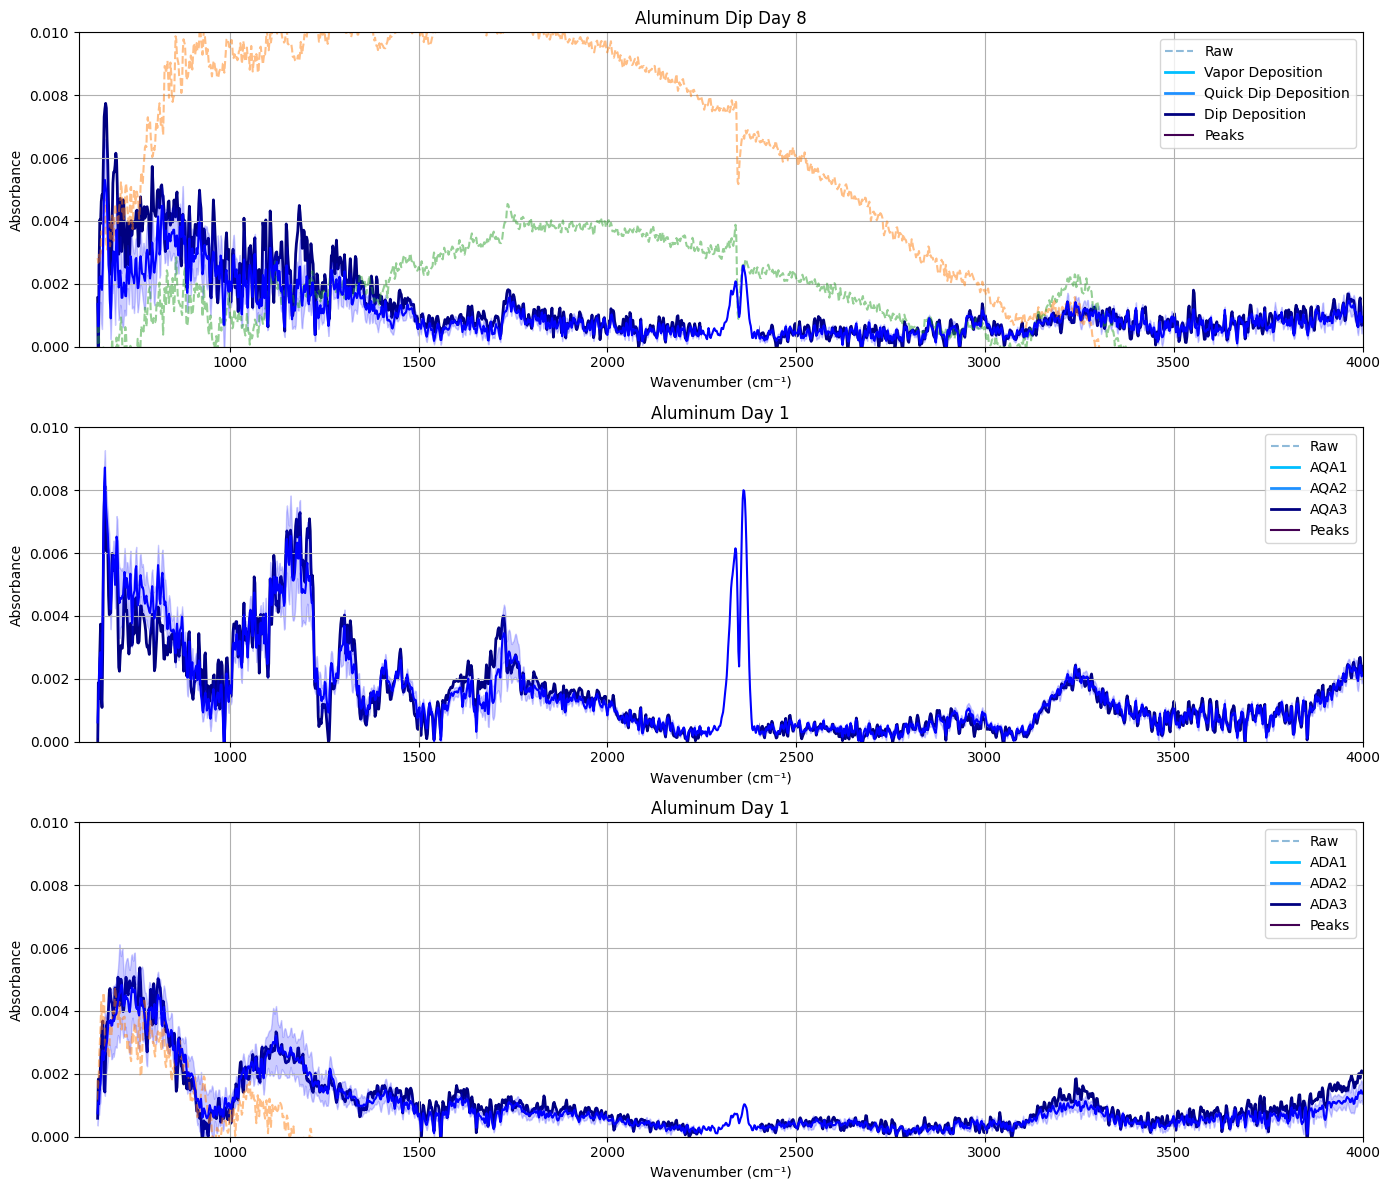

In [ ]:
from ramanspy.preprocessing import Pipeline
from ramanspy.preprocessing.baseline import ASLS, IASLS, IRSQR, ModPoly
from ramanspy.preprocessing.normalise import MinMax
from ramanspy.preprocessing.misc import Cropper
from ramanspy.preprocessing.denoise import SavGol
from ramanspy.preprocessing.despike import WhitakerHayes
from ramanspy import Spectrum
import matplotlib.pyplot as plt
import ramanspy as rp

# Create Spectrum objects
spec1 = Spectrum(file1[0], file1[1]) #YVA1 04/08/2025
spec2 = Spectrum(file2[0], file2[1]) #YQA1 04/08/2025
spec3 = Spectrum(file3[0], file3[1]) #YDA1 04/08/2025

spec4 = Spectrum(file4[0], file4[1]) #AVA1 04/08/2025
spec5 = Spectrum(file5[0], file5[1]) #AQA1 04/08/2025
spec6 = Spectrum(file6[0], file6[1]) #ADA1 04/08/2025

spec7 = Spectrum(file7[0], file7[1]) #AVA1 04/08/2025
spec8 = Spectrum(file8[0], file8[1]) #AQA1 04/08/2025
spec9 = Spectrum(file9[0], file9[1]) #ADA1 04/08/2025


# Define preprocessing pipeline
pipeline = Pipeline([
    #Cropper(region=(650, 4000)),            # Cut noisy edges
    WhitakerHayes(),                        # Despike
    SavGol(window_length=7, polyorder=5),   # Smooth
    ASLS(),                                 # Baseline 1
    #IASLS(),                                # Baseline 2
    # IRSQR()                                 # Baseline 3
    ModPoly(),                               #Baseline4
    # MinMax(pixelwise=False)               # Optional: normalize later if needed
])
spec = pipeline.apply(spec1)
print(spec)
# Apply pipeline
processed_specs = [
    [pipeline.apply(Spectrum(YV_08[0][0],YV_08[0][1])),
     pipeline.apply(Spectrum(YV_08[1][0],YV_08[1][1])),
     pipeline.apply(Spectrum(YV_08[2][0],YV_08[2][1])),
     pipeline.apply(Spectrum(YV_08[3][0],YV_08[3][1])),
     pipeline.apply(Spectrum(YV_08[4][0],YV_08[4][1])),
     pipeline.apply(Spectrum(YV_08[5][0],YV_08[5][1]))],
    [pipeline.apply(Spectrum(YQ_08[0][0],YQ_08[0][1])),
     pipeline.apply(Spectrum(YQ_08[1][0],YQ_08[1][1])),
     pipeline.apply(Spectrum(YQ_08[2][0],YQ_08[2][1])),
     pipeline.apply(Spectrum(YQ_08[3][0],YQ_08[3][1])),
     pipeline.apply(Spectrum(YQ_08[4][0],YQ_08[4][1])),
     pipeline.apply(Spectrum(YQ_08[5][0],YQ_08[5][1]))],
    [pipeline.apply(Spectrum(YD_08[0][0],YD_08[0][1])),
     pipeline.apply(Spectrum(YD_08[1][0],YD_08[1][1])),
     pipeline.apply(Spectrum(YD_08[2][0],YD_08[2][1])),
     pipeline.apply(Spectrum(YD_08[3][0],YD_08[3][1])),
     pipeline.apply(Spectrum(YD_08[4][0],YD_08[4][1])),
     pipeline.apply(Spectrum(YD_08[5][0],YD_08[5][1]))],
    [pipeline.apply(Spectrum(AV_08[0][0],AV_08[0][1])),
     pipeline.apply(Spectrum(AV_08[1][0],AV_08[1][1])),
     pipeline.apply(Spectrum(AV_08[2][0],AV_08[2][1])),
     pipeline.apply(Spectrum(AV_08[3][0],AV_08[3][1])),
     pipeline.apply(Spectrum(AV_08[4][0],AV_08[4][1])),
     pipeline.apply(Spectrum(AV_08[5][0],AV_08[5][1]))],
    [pipeline.apply(Spectrum(AQ_08[0][0],AQ_08[0][1])),
     pipeline.apply(Spectrum(AQ_08[1][0],AQ_08[1][1])),
     pipeline.apply(Spectrum(AQ_08[2][0],AQ_08[2][1])),
     pipeline.apply(Spectrum(AQ_08[3][0],AQ_08[3][1])),
     pipeline.apply(Spectrum(AQ_08[4][0],AQ_08[4][1])),
     pipeline.apply(Spectrum(AQ_08[5][0],AQ_08[5][1]))],
    [pipeline.apply(Spectrum(AD_08[0][0],AD_08[0][1])),
     pipeline.apply(Spectrum(AD_08[1][0],AD_08[1][1])),
     pipeline.apply(Spectrum(AD_08[2][0],AD_08[2][1])),
     pipeline.apply(Spectrum(AD_08[3][0],AD_08[3][1])),
     pipeline.apply(Spectrum(AD_08[4][0],AD_08[4][1])),
     pipeline.apply(Spectrum(AD_08[5][0],AD_08[5][1]))]

]

raw_specs = [[spec1, spec2, spec3], [spec4, spec5, spec6], [spec7, spec8, spec9]]

labels = [
    "Aluminum Dip Day 8",
    "Aluminum Day 1",
    "Aluminum Day 1"
]

Slabels = [
    ['Vapor Deposition',
    'Quick Dip Deposition',
    'Dip Deposition'],
    ['AQA1',
    'AQA2',
    'AQA3'],
    ['ADA1',
    'ADA2',
    'ADA3']
    ]


fig, axes = plt.subplots(3, 1, figsize=(14, 12))
axes = axes.flatten()

# Define a helper to calculate the mean spectrum manually
def mean_spectrum(spectra_list):
    """Compute mean Spectrum from a list of ramanspy Spectrum objects."""
    mean_axis = spectra_list[0].spectral_axis
    all_data = [s.spectral_data for s in spectra_list]
    mean_data = np.mean(all_data, axis=0)
    return Spectrum(mean_axis, mean_data)


for i in range(3):
    ax = axes[i]
    print(f"Plotting Spectrum {i}")

    # Plot raw spectra
    for k, spec in enumerate(raw_specs[i]):
        ax.plot(spec.spectral_axis, spec.spectral_data,
                linestyle='--', alpha=0.5, label='Raw' if k == 0 else "")

    # Plot processed mean spectrum
    rp.plot.mean_spectra(processed_specs[i], ax=ax, color='b')

    # Optional: overlay difference plots (edit as needed based on your structure)
    try:
        ax.plot(processed_specs[i][0].spectral_axis, raw_specs[i][0].spectral_data,
                linewidth=2, label=Slabels[i][0], color='deepskyblue', zorder=-2)

        ax.plot(processed_specs[i][0].spectral_axis,
                raw_specs[i][0].spectral_data - processed_specs[i][0].spectral_data,
                linewidth=2, label=Slabels[i][1], color='dodgerblue', zorder=-2)

        ax.plot(processed_specs[i][2].spectral_axis, processed_specs[i][2].spectral_data,
                linewidth=2, label=Slabels[i][2], color='navy', zorder=-2)
    except:
        print(f"Warning: Could not plot difference for index {i}. Check data structure.")

    # Fill white box to mask region
    ax.fill_betweenx([-.003, .01], 2250, 2400, color='white', zorder=1)

    # Overlay peaks
    # rp.plot.peaks(processed_specs[i], width=100, ax=ax, prominence=0.05, label='Peaks', zorder=-2) did not work, chatgpt replacement next
    # Assuming `processed_specs[i]` is a list of Spectrum objects
    # Replace this loop in your code:
    # rp.plot.peaks(processed_specs[i], width=100, ax=ax, prominence=0.05, label='Peaks', zorder=-2)

    # With this:
    mean_spec = mean_spectrum(processed_specs[i])
    rp.plot.peaks(mean_spec, width=100, ax=ax, prominence=0.05, label='Peaks', zorder=-2)


    # Formatting
    ax.set_xlim(600, 4000)
    ax.set_ylim(0, .01)
    ax.set_title(labels[i])
    ax.set_xlabel("Wavenumber (cm⁻¹)")
    ax.set_ylabel("Absorbance")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


# # Create subplots


# plt.fill_betweenx([-.008,.006],2250,2400, color='white',zorder=1)
# rp.plot.mean_spectra(processed_specs[5])
# # # Overlay peaks
# # rp.plot.peaks(processed_specs[i],width=100, ax=ax, prominence=0.05, label='Peaks',zorder=-2)

# plt.xlim(600, 4000)
# plt.ylim(0, .01)
# plt.title(labels[0])
# plt.xlabel("Wavenumber (cm⁻¹)")
# plt.ylabel("Absorbance")
# plt.legend()
# plt.grid(True)

# fig, axes = plt.subplots(3, 1, figsize=(14, 12))  # 3 rows, 2 columns
# axes = axes.flatten()

# ax = axes

# j=0
# for i in range(3):
#     ax = axes[i]
#     print(i)
#     # Assuming you're inside a loop over index `i` and have `fig, ax` or `axes[i]` set up

#     # Plot each raw spectrum in dashed line
#     for k, spec in enumerate(raw_specs[i]):
#         ax.plot(spec.spectral_axis, spec.spectral_data,
#                 linestyle='--', alpha=0.5, label='Raw' if k == 0 else "")

#     # Plot the processed mean spectrum (assuming you use ramanchirp's plot function)
#     axes[i] = rp.plot.mean_spectra(processed_specs[i], color='b')

#     # Optional: Add legend only once if not already present
#     ax.legend()

#     # Optional: Set title, axis labels, etc.
#     ax.set_title(f"Spectrum {i}")
#     ax.set_xlabel("Wavenumber (cm⁻¹)")
#     ax.set_ylabel("Intensity (a.u.)")

#     ax.mean_spectra(processed_specs[0+(3*i)])
#     ax.mean_spectra(processed_specs[1+(3*i)])
#     ax.mean_spectra(processed_specs[2+(3*i)])
#     # Plot processed
#     ax.plot(processed_specs[i][0].spectral_axis, raw_specs[j][i].spectral_data,
#             linewidth=2, label=Slabels[0][0],color = 'deepskyblue',zorder=-2)
#     ax.plot(processed_specs[i][0].spectral_axis, raw_specs[j][i].spectral_data-processed_specs[j][i].spectral_data,
#             linewidth=2, label=Slabels[0][1],color = 'dodgerblue',zorder=-2)
#     ax.plot(processed_specs[i][2].spectral_axis, processed_specs[j][i].spectral_data,
#             linewidth=2, label=Slabels[0][2],color = 'navy',zorder=-2)
#     ax.fill_betweenx([-.003,.01],2250,2400, color='white',zorder=1)

#     # # Overlay peaks
#     rp.plot.peaks(processed_specs[i],width=100, ax=ax, prominence=0.05, label='Peaks',zorder=-2)

#     ax.set_xlim(600, 4000)
#     ax.set_ylim(0, .01)
#     ax.set_title(labels[i])
#     ax.set_xlabel("Wavenumber (cm⁻¹)")
#     ax.set_ylabel("Absorbance")
#     ax.legend()
#     ax.grid(True)
# # for i in range(3):
# #     ax = axes[i]
# #     print(i)
# #     # Plot raw
# #     ax.plot(raw_specs[i].spectral_axis, raw_specs[i].spectral_data,
# #             linestyle='--', alpha=0.5, label='Raw')

# #     # Plot processed
# #     ax.plot(processed_specs[i][0].spectral_axis, processed_specs[i][1].spectral_data-processed_specs[i][0].spectral_data,
# #             linewidth=2, label='Day 1-8',zorder=-2)
# #     ax.plot(processed_specs[i][1].spectral_axis, processed_specs[i][2].spectral_data-processed_specs[i][1].spectral_data,
# #             linewidth=2, label='Day 3-8',zorder=-2)

# #     ax.fill_betweenx([-.008,.006],2250,2400, color='white',zorder=1)

# #     # # Overlay peaks
# #     rp.plot.peaks(processed_specs[i],width=100, ax=ax, prominence=0.05, label='Peaks',zorder=-2)

# #     ax.set_xlim(600, 4000)
# #     ax.set_ylim(0, .01)
# #     ax.set_title(labels[i])
# #     ax.set_xlabel("Wavenumber (cm⁻¹)")
# #     ax.set_ylabel("Absorbance")
# #     ax.legend()
# #     ax.grid(True)

# # plt.tight_layout()
# # plt.show()



# #Outputs something like this. The label is wrong, I commented out the IASLS and IRSQR but it uses Whttaker Hayes and Savgol smoother with ASLS baseline correction.


In [ ]:

#rp.plot.mean_spectra([processed_specs[0],processed_specs[1],processed_specs[2]],color = 'green', label='Day 1',zorder=-1,dist=False)
#rp.plot.mean_spectra([processed_specs[3],processed_specs[4],processed_specs[5]],color = 'gold', label='Day 3',zorder=-1,dist=False)
#rp.plot.mean_spectra([processed_specs[6],processed_specs[7],processed_specs[8]],color = 'red', label='Day 8',zorder=-1,dist=False)

#plt.plot(processed_specs[0].spectral_axis,mean(processed_specs[0].spectral_data,processed_specs[1].spectral_data,processed_specs[2].spectral_data),color='green',label='Day 1',zorder=-1)
#plt.plot(processed_specs[0].spectral_axis,mean(processed_specs[3].spectral_data,processed_specs[4].spectral_data,processed_specs[5].spectral_data),color='gold',label='Day 3',zorder=-1)
#plt.plot(processed_specs[0].spectral_axis,mean(processed_specs[6].spectral_data,processed_specs[7].spectral_data,processed_specs[8].spectral_data),color='red',label='Day 8',zorder=-1)

'''
plt.plot(processed_specs[0].spectral_axis, processed_specs[0].spectral_data,linewidth=2,color = 'green', label='Day 1',zorder=-1)
plt.plot(processed_specs[1].spectral_axis, processed_specs[1].spectral_data,linewidth=2,color = 'green',zorder=-1)
plt.plot(processed_specs[2].spectral_axis, processed_specs[2].spectral_data,linewidth=2,color = 'green',zorder=-1)
plt.plot(processed_specs[3].spectral_axis, processed_specs[3].spectral_data,linewidth=2,color = 'gold', label='Day 3',zorder=-1)
plt.plot(processed_specs[4].spectral_axis, processed_specs[4].spectral_data,linewidth=2,color = 'gold',zorder=-1)
plt.plot(processed_specs[5].spectral_axis, processed_specs[5].spectral_data,linewidth=2,color = 'gold',zorder=-1)
plt.plot(processed_specs[6].spectral_axis, processed_specs[6].spectral_data,linewidth=2,color = 'red', label='Day 8',zorder=-1)
plt.plot(processed_specs[7].spectral_axis, processed_specs[7].spectral_data,linewidth=2,color = 'red',zorder=-1)
plt.plot(processed_specs[8].spectral_axis, processed_specs[8].spectral_data,linewidth=2,color = 'red',zorder=-1)
'''



#mean3 = mean(processed_specs[3].spectral_data-processed_specs[0].spectral_data,processed_specs[4].spectral_data-processed_specs[1].spectral_data,processed_specs[5].spectral_data-processed_specs[2].spectral_data)
#mean8 = mean(processed_specs[6].spectral_data-processed_specs[0].spectral_data,processed_specs[7].spectral_data-processed_specs[1].spectral_data,processed_specs[8].spectral_data-processed_specs[2].spectral_data)
mean3 = mean(processed_specs[3].spectral_data-processed_specs[0].spectral_data,processed_specs[4].spectral_data-processed_specs[1].spectral_data,processed_specs[5].spectral_data-processed_specs[2].spectral_data)
mean8 = mean(processed_specs[6].spectral_data-processed_specs[0].spectral_data,processed_specs[7].spectral_data-processed_specs[1].spectral_data,processed_specs[8].spectral_data-processed_specs[2].spectral_data)

#plt.plot(processed_specs[0].spectral_axis,mean3,color='red',zorder=-1,label="Change, Days 1-3")
#plt.plot(processed_specs[0].spectral_axis,mean8,color='blue',zorder=-1,label="Change, Days 1-8")
'''
plt.plot(processed_specs[0].spectral_axis, processed_specs[0].spectral_data,linewidth=2,color = 'green', label='Day 1',zorder=-1)
plt.plot(processed_specs[1].spectral_axis, processed_specs[1].spectral_data,linewidth=2,color = 'green',zorder=-1)
plt.plot(processed_specs[2].spectral_axis, processed_specs[2].spectral_data,linewidth=2,color = 'green',zorder=-1)
plt.plot(processed_specs[3].spectral_axis, processed_specs[3].spectral_data-processed_specs[0].spectral_data,linewidth=2,color = 'gold', label='Day 3',zorder=-1)
plt.plot(processed_specs[4].spectral_axis, processed_specs[4].spectral_data-processed_specs[1].spectral_data,linewidth=2,color = 'gold',zorder=-1)
plt.plot(processed_specs[5].spectral_axis, processed_specs[5].spectral_data-processed_specs[2].spectral_data,linewidth=2,color = 'gold',zorder=-1)
plt.plot(processed_specs[6].spectral_axis, processed_specs[6].spectral_data-processed_specs[3].spectral_data,linewidth=2,color = 'red', label='Day 8',zorder=-1)
plt.plot(processed_specs[7].spectral_axis, processed_specs[7].spectral_data-processed_specs[4].spectral_data,linewidth=2,color = 'red',zorder=-1)
plt.plot(processed_specs[8].spectral_axis, processed_specs[8].spectral_data-processed_specs[5].spectral_data,linewidth=2,color = 'red',zorder=-1)
'''
#plt.plot(processed_specs[0].spectral_axis,mean(processed_specs[0].spectral_data,processed_specs[1].spectral_data,processed_specs[2].spectral_data),color='green',zorder=-1,label="Day 1")
#plt.plot(processed_specs[0].spectral_axis,mean(processed_specs[3].spectral_data,processed_specs[4].spectral_data,processed_specs[5].spectral_data),color='gold',zorder=-1,label="Day 3")
#plt.plot(processed_specs[0].spectral_axis,mean(processed_specs[6].spectral_data,processed_specs[7].spectral_data,processed_specs[8].spectral_data),color='red',zorder=-1,label="Day 8")

"""
plt.xlim(600, 2000)
plt.ylim(-.003, .009)
#ax.set_ylim(0, .005)
#ax.set_title(labels[i])
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Absorbance")
plt.legend()
plt.grid(True,zorder=10)
plt.title("Spectrum Difference, Stored in Nitrogen")
plt.fill_betweenx([-.003,.009],2250,2400, color='white',zorder=1)
#plt.fill_betweenx([-.003,.009],1626,1678, color='green',zorder=-2)
#plt.fill_betweenx([-.003,.009],1735,1750, color='green',zorder=-2)

plt.axvline(x=2945, color='black', linestyle='--')
plt.axvline(x=1717, color='black', linestyle='--')
plt.axvline(x=1161, color='black', linestyle='--')
plt.axvline(x=1078, color='black', linestyle='--')
plt.axvline(x=813, color='black', linestyle='--')

"""

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ramanspy import Spectrum
import ramanspy as rp

# Define a helper to calculate the mean spectrum manually
def mean_spectrum(spectra_list):
    """Compute mean Spectrum from a list of ramanspy Spectrum objects."""
    mean_axis = spectra_list[0].spectral_axis
    all_data = [s.spectral_data for s in spectra_list]
    mean_data = np.mean(all_data, axis=0)
    return Spectrum(mean_axis, mean_data)

# Calculate the mean spectrum for Day 1 (processed_specs[0], processed_specs[1], processed_specs[2])
mean_day1 = mean_spectrum(processed_specs[0] + processed_specs[1] + processed_specs[2])

# Calculate the mean spectrum for Day 3 (processed_specs[3], processed_specs[4], processed_specs[5])
mean_day3 = mean_spectrum(processed_specs[3] + processed_specs[4] + processed_specs[5])

# Calculate the mean spectrum for Day 8 (processed_specs[6], processed_specs[7], processed_specs[8])
mean_day8 = mean_spectrum(processed_specs[6] + processed_specs[7] + processed_specs[8])

# Plot the mean spectra for Day 1, Day 3, and Day 8
plt.plot(mean_day1.spectral_axis, mean_day1.spectral_data, color='green', label='Day 1', linewidth=2)
plt.plot(mean_day3.spectral_axis, mean_day3.spectral_data, color='gold', label='Day 3', linewidth=2)
plt.plot(mean_day8.spectral_axis, mean_day8.spectral_data, color='red', label='Day 8', linewidth=2)

# Optional: Plot the difference between Days 3 and 1, and between Days 8 and 1
diff_3_1 = mean_day3.spectral_data - mean_day1.spectral_data
diff_8_1 = mean_day8.spectral_data - mean_day1.spectral_data

plt.plot(mean_day1.spectral_axis, diff_3_1, color='purple', label="Change, Days 1-3", linewidth=2)
plt.plot(mean_day1.spectral_axis, diff_8_1, color='blue', label="Change, Days 1-8", linewidth=2)

# Formatting
plt.xlim(600, 4000)
plt.ylim(-.003, .01)
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Absorbance")
plt.legend()
plt.grid(True, zorder=10)
plt.title("Spectrum Comparison (Day 1, Day 3, Day 8)")

# Optional: Masking region (example)
plt.fill_betweenx([-.003, .01], 2250, 2400, color='white', zorder=1)

# Show plot
plt.tight_layout()
plt.show()


IndexError: list index out of range

Length of processed_specs: 6


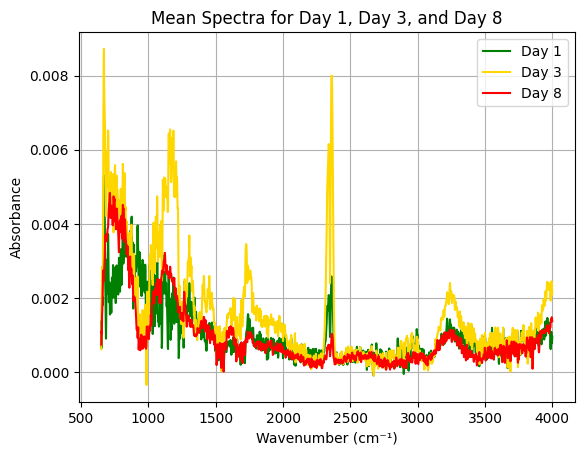

In [ ]:
# Define the mean function (assuming 'mean' is available or you can use np.mean)
import numpy as np
def mean_spectrum(spectra_list):
    return np.mean([s.spectral_data for s in spectra_list], axis=0)

# Check the length of processed_specs to ensure there are enough elements
print(f"Length of processed_specs: {len(processed_specs)}")

# Ensure that processed_specs has at least 3 groups (for Day 1, Day 3, and Day 8)
if len(processed_specs) >= 3:
    # Calculate the mean spectrum for Day 1 (processed_specs[0])
    mean_day1 = mean_spectrum(processed_specs[0])
else:
    print("Not enough data for Day 1")

if len(processed_specs) >= 3:
    # Calculate the mean spectrum for Day 3 (processed_specs[1])
    mean_day3 = mean_spectrum(processed_specs[1])
else:
    print("Not enough data for Day 3")

if len(processed_specs) >= 3:
    # Calculate the mean spectrum for Day 8 (processed_specs[2])
    mean_day8 = mean_spectrum(processed_specs[2])
else:
    print("Not enough data for Day 8")

# Plotting the mean spectra for Day 1, Day 3, and Day 8
import matplotlib.pyplot as plt

plt.plot(processed_specs[0][0].spectral_axis, mean_day1, color='green', label='Day 1')
plt.plot(processed_specs[1][0].spectral_axis, mean_day3, color='gold', label='Day 3')
plt.plot(processed_specs[2][0].spectral_axis, mean_day8, color='red', label='Day 8')

plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Absorbance")
plt.legend()
plt.grid(True)
plt.title("Mean Spectra for Day 1, Day 3, and Day 8")
plt.show()
